<a href="https://colab.research.google.com/github/QuanNguyenDinh/DATN/blob/main/Double_Side_Auction_Mechanism_for_Generative_AI_Service_(change_seller%2C_buyer%2C_Mm%2C_denoising_so_s%C3%A1nh_1_2_v%E1%BB%9Bi_greedy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

class DoubleAuctionMechanism:
    def __init__(self):
        # Base parameters for computation cost calculation
        self.F_xi_0 = 0.338 * 10**12  # FLOPs for encoder
        self.F_epsilon_0 = 2.119 * 10**9  # FLOPs for denoising block
        self.F_D_0 = 4.853 * 10**9  # FLOPs for decoder
        self.F_tau_0 = 0.852 * 10**9  # FLOPs for prompt-encoder
        self.H_0 = 32  # Base height
        self.W_0 = 32  # Base width
        self.C = 3  # Number of channels
        self.b = 16  # Bits per pixel
        self.max_denoise_steps = 50  # Maximum denoising steps

    def compute_denoising_steps(self, kappa_n):
        """
        Compute the number of denoising steps required by a task
        Formula: λ_n = κ_n * r^denoi_m (Equation 7)
        """
        return kappa_n * self.max_denoise_steps

    def compute_flops(self, H_ni, W_ni, lambda_n):
        """
        Compute the number of FLOPs required for the inference of a task
        Formula: F_n,i = (H_n,i * W_n,i / (H_0 * W_0)) * (F^ξ_0 + F^D_0) + λ_n * F^ε_0 + F^τ_0 (Equation 8)
        """
        scaling_factor = (H_ni * W_ni) / (self.H_0 * self.W_0)
        return scaling_factor * (self.F_xi_0 + self.F_D_0) + lambda_n * self.F_epsilon_0 + self.F_tau_0

    def compute_comm_cost(self, s_in_img, s_in_prompt, H_ni, W_ni):
        """
        Compute the communication resource cost for a task
        Formula: s^comm_n,i = s^in_n,i + s^out,img_n,i (Equation 11)
        Where: s^in_n,i = s^in,img_n,i + s^in,prompt_n,i (Equation 9)
        And: s^out,img_n,i = H_n,i * W_n,i * C * b (Equation 10)
        """
        s_in = s_in_img + s_in_prompt
        s_out_img = H_ni * W_ni * self.C * self.b
        return s_in + s_out_img

    def compute_buyer_bid(self, xi_b_n, eta_b_n, F_ni, s_comm_ni):
        """
        Compute the bid of a buyer for a task
        Formula: p^b_n,i = ξ^b_n * F^comp_n,i + η^b_n * s^comm_n,i (Equation 13a)
        """
        return xi_b_n * F_ni + eta_b_n * s_comm_ni

    def compute_seller_ask(self, xi_s_m, zeta_s_m, eta_s_m, r_comp_m, r_denoi_m, r_comm_m):
        """
        Compute the ask of a seller for a task
        Formula: p^s_m,j = ξ^s_m * r^comp_m + ζ^s_m * r^denoi_m + η^s_m * r^comm_m (Equation 14a)
        """
        return xi_s_m * r_comp_m + zeta_s_m * r_denoi_m + eta_s_m * r_comm_m

    def double_auction_scenario1(self, users, gaisps):
        """
        Algorithm for Double Auction Mechanism - Scenario 1
        Each user requires sufficient resources for all of its tasks to be successfully matched
        """
        M = {}  # Matching dictionary
        payment_prices = {}  # Payment prices for buyers
        selling_prices = {}  # Selling prices for sellers

        # Step 1: Calculate all bids and asks
        all_bids = []  # List to store all bids with user and task info
        for n, user in enumerate(users):
            user_bids = []
            # Calculate required denoising steps
            lambda_n = self.compute_denoising_steps(user['kappa_n'])

            for i, task in enumerate(user['tasks']):
                # Calculate FLOPs and communication cost
                F_ni = self.compute_flops(task['H_ni'], task['W_ni'], lambda_n)
                s_comm_ni = self.compute_comm_cost(
                    task['s_in_img'], task['s_in_prompt'], task['H_ni'], task['W_ni']
                )

                # Calculate bid
                bid = self.compute_buyer_bid(user['xi_b_n'], user['eta_b_n'], F_ni, s_comm_ni)
                user_bids.append({
                    'user_id': n,
                    'task_id': i,
                    'bid': bid
                })

            # Add all user bids to the main list
            all_bids.extend(user_bids)

        # Step 2: Calculate all asks
        all_asks = []  # List to store all asks with GAISP and task info
        for m, gaisp in enumerate(gaisps):
            for j in range(gaisp['M_m']):  # M_m is the maximum number of tasks GAISP m can process
                ask = self.compute_seller_ask(
                    gaisp['xi_s_m'], gaisp['zeta_s_m'], gaisp['eta_s_m'],
                    gaisp['r_comp_m'], gaisp['r_denoi_m'], gaisp['r_comm_m']
                )
                all_asks.append({
                    'gaisp_id': m,
                    'task_id': j,
                    'ask': ask
                })

        # Step 3: Sort bids in descending order
        B = sorted(all_bids, key=lambda x: x['bid'], reverse=True)

        # Step 4: Sort asks in ascending order
        S = sorted(all_asks, key=lambda x: x['ask'])

        # Step 5: Perform the double auction algorithm
        while B:
            # Get the first user's bids
            user_id = B[0]['user_id']
            B_prime = [bid for bid in B if bid['user_id'] == user_id]

            # Get the number of tasks for this user
            N_n = len(B_prime)

            # Remove these bids from B
            B = [bid for bid in B if bid['user_id'] != user_id]

            # Check if there are enough asks to match all tasks of this user
            if len(S) < N_n:
                continue  # Not enough sellers, move to next user

            # Find breakeven index (largest k such that k-th bid >= k-th ask)
            breakeven_index = -1
            for k in range(min(N_n, len(S))):
                if B_prime[k]['bid'] >= S[k]['ask']:
                    breakeven_index = k
                else:
                    break

            # If all tasks can be matched, proceed with allocation
            if breakeven_index + 1 == N_n:
                # Allocate first k elements of S with N_n elements of B_prime
                matched_sellers = S[:N_n]
                S = S[N_n:]  # Remove matched sellers from S

                # Update matching dictionary and determine payment/selling prices
                for i, (buyer, seller) in enumerate(zip(B_prime, matched_sellers)):
                    M[(buyer['user_id'], buyer['task_id'])] = (seller['gaisp_id'], seller['task_id'])

                    # Payment price equals the next largest bid or the last matched bid if it's the last
                    if i < N_n - 1:
                        payment_price = B_prime[i+1]['bid']
                    else:
                        payment_price = B_prime[i]['bid']

                    # Selling price equals the next smallest ask or the last matched ask if it's the last
                    if i < len(matched_sellers) - 1:
                        selling_price = matched_sellers[i+1]['ask']
                    else:
                        selling_price = matched_sellers[i]['ask']

                    payment_prices[(buyer['user_id'], buyer['task_id'])] = payment_price
                    selling_prices[(seller['gaisp_id'], seller['task_id'])] = selling_price

        return M, payment_prices, selling_prices

    def double_auction_scenario2(self, users, gaisps):
        """
        Algorithm for Double Auction Mechanism - Scenario 2
        Each user doesn't require sufficient resources for all of its tasks to be successfully matched
        """
        M = {}  # Matching dictionary
        payment_prices = {}  # Payment prices for buyers
        selling_prices = {}  # Selling prices for sellers

        # Step 1: Calculate all bids and asks
        all_bids = []  # List to store all bids with user and task info
        for n, user in enumerate(users):
            # Calculate required denoising steps
            lambda_n = self.compute_denoising_steps(user['kappa_n'])

            for i, task in enumerate(user['tasks']):
                # Calculate FLOPs and communication cost
                F_ni = self.compute_flops(task['H_ni'], task['W_ni'], lambda_n)
                s_comm_ni = self.compute_comm_cost(
                    task['s_in_img'], task['s_in_prompt'], task['H_ni'], task['W_ni']
                )

                # Calculate bid
                bid = self.compute_buyer_bid(user['xi_b_n'], user['eta_b_n'], F_ni, s_comm_ni)
                all_bids.append({
                    'user_id': n,
                    'task_id': i,
                    'bid': bid
                })

        # Step 2: Calculate all asks
        all_asks = []  # List to store all asks with GAISP and task info
        for m, gaisp in enumerate(gaisps):
            for j in range(gaisp['M_m']):  # M_m is the maximum number of tasks GAISP m can process
                ask = self.compute_seller_ask(
                    gaisp['xi_s_m'], gaisp['zeta_s_m'], gaisp['eta_s_m'],
                    gaisp['r_comp_m'], gaisp['r_denoi_m'], gaisp['r_comm_m']
                )
                all_asks.append({
                    'gaisp_id': m,
                    'task_id': j,
                    'ask': ask
                })

        # Step 3: Sort bids in descending order
        B = sorted(all_bids, key=lambda x: x['bid'], reverse=True)

        # Step 4: Sort asks in ascending order
        S = sorted(all_asks, key=lambda x: x['ask'])

        # Step 5: Find breakeven index (largest k such that k-th bid >= k-th ask)
        breakeven_index = -1
        for k in range(min(len(B), len(S))):
            if B[k]['bid'] >= S[k]['ask']:
                breakeven_index = k
            else:
                break

        # Step 6: Allocate first k elements of S with first k elements of B
        if breakeven_index >= 0:
            matched_buyers = B[:breakeven_index+1]
            matched_sellers = S[:breakeven_index+1]

            # Step 7: Update matching dictionary and determine payment/selling prices
            for i, (buyer, seller) in enumerate(zip(matched_buyers, matched_sellers)):
                M[(buyer['user_id'], buyer['task_id'])] = (seller['gaisp_id'], seller['task_id'])

                # Payment price equals the next bid or the last matched bid if it's the last
                if i < len(matched_buyers) - 1:
                    payment_price = matched_buyers[i+1]['bid']
                else:
                    # If it's the last matched bid, use it as payment price
                    # or next unmatched bid if available
                    if breakeven_index + 1 < len(B):
                        payment_price = B[breakeven_index+1]['bid']
                    else:
                        payment_price = buyer['bid']

                # Selling price equals the next ask or the last matched ask if it's the last
                if i < len(matched_sellers) - 1:
                    selling_price = matched_sellers[i+1]['ask']
                else:
                    # If it's the last matched ask, use it as selling price
                    # or next unmatched ask if available
                    if breakeven_index + 1 < len(S):
                        selling_price = S[breakeven_index+1]['ask']
                    else:
                        selling_price = seller['ask']

                payment_prices[(buyer['user_id'], buyer['task_id'])] = payment_price
                selling_prices[(seller['gaisp_id'], seller['task_id'])] = selling_price

        return M, payment_prices, selling_prices


# Example usage of the Double Auction Mechanism
def main():
    # Create an instance of the Double Auction Mechanism
    auction = DoubleAuctionMechanism()

    # Example users (buyers)
    users = [
        {
            'kappa_n': 0.8,  # Similarity level
            'xi_b_n': 8e-13,  # Unit price for computation
            'eta_b_n': 1e-6,  # Unit price for communication
            'tasks': [
                {
                    'H_ni': 64, 'W_ni': 64,  # Image dimensions
                    's_in_img': 12288,  # Input image size in bits (64*64*3)
                    's_in_prompt': 1024  # Input prompt size in bits
                },
                {
                    'H_ni': 128, 'W_ni': 128,
                    's_in_img': 49152,
                    's_in_prompt': 2048
                },
                {
                    'H_ni': 256, 'W_ni': 256,
                    's_in_img': 196608,
                    's_in_prompt': 3072
                }
            ]
        },
        {
            'kappa_n': 0.6,
            'xi_b_n': 7e-13,
            'eta_b_n': 2e-6,
            'tasks': [
                {
                    'H_ni': 128, 'W_ni': 128,
                    's_in_img': 49152,
                    's_in_prompt': 1536
                },
                {
                    'H_ni': 64, 'W_ni': 64,
                    's_in_img': 12288,
                    's_in_prompt': 768
                }
            ]
        }
    ]

    # Example GAISPs (sellers)
    gaisps = [
        {
            'M_m': 3,  # Maximum tasks processed simultaneously
            'xi_s_m': 1e-12,  # Unit cost for computation
            'zeta_s_m': 1e-3,  # Unit cost for denoising step
            'eta_s_m': 5e-7,  # Unit cost for communication
            'r_comp_m': 1e12,  # Computation resources
            'r_denoi_m': 50,  # Denoising steps
            'r_comm_m': 1e6  # Communication resources
        },
        {
            'M_m': 2,
            'xi_s_m': 1e-12,
            'zeta_s_m': 8e-4,
            'eta_s_m': 4e-7,
            'r_comp_m': 8e11,
            'r_denoi_m': 40,
            'r_comm_m': 8e5
        }
    ]

    # Run Scenario 1
    print("Running Scenario 1...")
    M1, payment_prices1, selling_prices1 = auction.double_auction_scenario1(users, gaisps)
    print("Matching results:", M1)
    print("Payment prices:", payment_prices1)
    print("Selling prices:", selling_prices1)

    print("\nRunning Scenario 2...")
    M2, payment_prices2, selling_prices2 = auction.double_auction_scenario2(users, gaisps)
    print("Matching results:", M2)
    print("Payment prices:", payment_prices2)
    print("Selling prices:", selling_prices2)

if __name__ == "__main__":
    main()

Running Scenario 1...
Matching results: {(1, 0): (1, 0), (1, 1): (1, 1)}
Payment prices: {(1, 0): 1.4244118, (1, 1): 1.4244118}
Selling prices: {(1, 0): 1.152, (1, 1): 1.152}

Running Scenario 2...
Matching results: {(0, 2): (1, 0), (1, 0): (1, 1), (0, 1): (0, 0)}
Payment prices: {(0, 2): 5.559289000000001, (1, 0): 5.29464, (0, 1): 1.4244118}
Selling prices: {(1, 0): 1.152, (1, 1): 1.55, (0, 0): 1.55}


# Version 1

In [ ]:
import numpy as np
from typing import List, Dict, Tuple, Set

# Define data structures
class GAITask:
    def __init__(self, user_id, task_id, height, width, in_img_size, in_prompt_size, kappa):
        self.user_id = user_id
        self.task_id = task_id
        self.height = height
        self.width = width
        self.in_img_size = in_img_size
        self.in_prompt_size = in_prompt_size
        self.kappa = kappa

        # Computed values
        self.denoising_steps = None
        self.flops = None
        self.comm_cost = None
        self.bid = None

class User:
    def __init__(self, user_id, xi_b, eta_b, kappa):
        self.user_id = user_id
        self.xi_b = xi_b  # Unit price for computation
        self.eta_b = eta_b  # Unit price for communication
        self.kappa = kappa  # Similarity level between input and generated images
        self.tasks = []

    def add_task(self, task_id, height, width, in_img_size, in_prompt_size):
        task = GAITask(self.user_id, task_id, height, width, in_img_size, in_prompt_size, self.kappa)
        self.tasks.append(task)
        return task

    def compute_bids(self, base_params):
        for task in self.tasks:
            # Calculate denoising steps (Equation 7)
            task.denoising_steps = task.kappa * base_params['r_denoi_m']

            # Calculate computation cost in FLOPs (Equation 8)
            scale_factor = (task.height * task.width) / (base_params['H0'] * base_params['W0'])
            encoder_decoder_flops = scale_factor * (base_params['F_xi_0'] + base_params['F_D_0'])
            denoising_flops = task.denoising_steps * base_params['F_epsilon_0']
            task.flops = encoder_decoder_flops + denoising_flops + base_params['F_tau_0']

            # Calculate communication cost (Equations 9-11)
            task.in_size = task.in_img_size + task.in_prompt_size
            task.out_img_size = task.height * task.width * base_params['C'] * base_params['b']
            task.comm_cost = task.in_size + task.out_img_size

            # Calculate bid (Equation 13a)
            task.bid = self.xi_b * task.flops + self.eta_b * task.comm_cost

class GAISP:
    def __init__(self, gaisp_id, r_comp, r_comm, r_denoi, xi_s, eta_s, zeta_s, max_tasks):
        self.gaisp_id = gaisp_id
        self.r_comp = r_comp  # Computation resources
        self.r_comm = r_comm  # Communication resources
        self.r_denoi = r_denoi  # Denoising steps
        self.xi_s = xi_s  # Unit price for computation
        self.eta_s = eta_s  # Unit price for communication
        self.zeta_s = zeta_s  # Unit price for denoising
        self.max_tasks = max_tasks  # Maximum number of tasks processable simultaneously
        self.asks = []

    def compute_asks(self):
        # Generate asks for all tasks this GAISP can process (Equation 14a)
        self.asks = []
        for j in range(self.max_tasks):
            ask = self.xi_s * self.r_comp + self.zeta_s * self.r_denoi + self.eta_s * self.r_comm
            self.asks.append((self.gaisp_id, j, ask))
        return self.asks

def double_auction_scenario1(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Algorithm for Double Auction Mechanism - Scenario 1
    Each user requires sufficient resources for all of its tasks to be successfully matched by the auctioneer
    """
    # Initialize the matching dictionary
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)
    bid_values = [bid[2] for bid in B]
    print(bid_values)

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])
    ask_values = [ask[2] for ask in S]
    print(ask_values)

    # Group bids by user
    user_bids = {}
    for bid in B:
        user_id, task_id, bid_value = bid
        if user_id not in user_bids:
            user_bids[user_id] = []
        user_bids[user_id].append((task_id, bid_value))

    # Process each user's bids
    for user_id, user_tasks in user_bids.items():
        # Find the user object
        user = next((u for u in users if u.user_id == user_id), None)
        if not user:
            continue

        # Create subset B' with this user's bids
        B_prime = [(user_id, task_id, bid_value) for task_id, bid_value in user_tasks]

        # Sort B_prime in descending order by bid value
        B_prime = sorted(B_prime, key=lambda x: x[2], reverse=True)

        # Count tasks for this user
        N_n = len(user.tasks)

        # Check if there are enough asks available
        if len(S) < N_n:
            continue  # Not enough asks to match all tasks

        # Identify the breakeven index
        k = 0
        while k < min(N_n, len(S)) and B_prime[k][2] >= S[k][2]:
            k += 1

        # Match only if all tasks can be allocated
        if k == N_n:
            # Allocate tasks
            for i in range(N_n):
                user_id, task_id, bid_value = B_prime[i]
                gaisp_id, gaisp_task_id, ask_value = S[i]

                # Match the task
                matching[(user_id, task_id)] = (gaisp_id, gaisp_task_id)

                # Find the payment price (lower or equal price just before bid_value in bid_values)
                # First find the index of current bid_value in the sorted bid_values list
                bid_index = bid_values.index(bid_value)
                # If it's not the last bid, use the next highest bid
                if bid_index < len(bid_values) - 1:
                    payment_prices[(user_id, task_id)] = bid_values[bid_index + 1]
                else:
                    # If it's the last bid, use its own value
                    payment_prices[(user_id, task_id)] = bid_value

                print(f"Payment price for user {user_id}, task {task_id}: {payment_prices[(user_id, task_id)]}", bid_value)

                # Find the selling price (higher or equal price just before ask_value in ask_values)
                # First find the index of current ask_value in the sorted ask_values list
                ask_index = ask_values.index(ask_value)
                # If it's not the last ask, use the next lowest ask
                if ask_index < len(ask_values) - 1:
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_values[ask_index + 1]
                else:
                    # If it's the last ask, use its own value
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_value

                if payment_prices[(user_id, task_id)] < selling_prices[(gaisp_id, gaisp_task_id)]:
                    payment_prices[(user_id, task_id)] = bid_value
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_value


                print(f"Selling price for GAISP {gaisp_id}, task {gaisp_task_id}: {selling_prices[(gaisp_id, gaisp_task_id)]}", ask_value)

                print("\n")
            print("\n")
            # Remove the allocated asks from S
            S = S[N_n:]
            # Remove the matched asks from ask_values list as well
            ask_values = ask_values[N_n:]

    return matching, payment_prices, selling_prices

def double_auction_scenario2(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Algorithm for Double Auction Mechanism - Scenario 2
    Each user doesn't require sufficient resources for all of its tasks to be successfully matched by the auctioneer
    """
    # Initialize the matching dictionary
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])

    # Identify the breakeven index
    k = 0
    while k < min(len(B), len(S)) and B[k][2] >= S[k][2]:
        k += 1

    # Allocate tasks
    for i in range(k):
        user_id, task_id, bid_value = B[i]
        gaisp_id, gaisp_task_id, ask_value = S[i]

        # Match the task
        matching[(user_id, task_id)] = (gaisp_id, gaisp_task_id)

        # Set payment price
        if i < len(B) - 1:
            payment_prices[(user_id, task_id)] = B[i+1][2]
        else:
            # For the last bid, use its own bid as payment
            payment_prices[(user_id, task_id)] = bid_value

        # Set selling price
        if i < len(S) - 1:
            selling_prices[(gaisp_id, gaisp_task_id)] = S[i+1][2]
        else:
            # For the last ask, use its own ask as selling price
            selling_prices[(gaisp_id, gaisp_task_id)] = ask_value

    return matching, payment_prices, selling_prices

# Example usage
def run_example():
    # Define base parameters
    base_params = {
        'H0': 32,
        'W0': 32,
        'F_xi_0': 0.338e12,  # FLOPs for encoder
        'F_epsilon_0': 2.119e9,  # FLOPs for denoising block
        'F_D_0': 4.853e9,  # FLOPs for decoder
        'F_tau_0': 0.852e9,  # FLOPs for prompt-encoder
        'C': 3,  # Number of channels
        'b': 16,  # Bits per pixel
        'r_denoi_m': 50  # Max denoising steps
    }

    # Create users
    users = [
        User(1, 1e-12, 1e-8, 0.8),  # User 1 with high similarity requirement
        User(2, 2e-12, 2e-8, 0.5)   # User 2 with medium similarity requirement
    ]

    # Add tasks to users
    users[0].add_task(1, 64, 64, 16384, 500)   # Small image
    users[0].add_task(2, 128, 128, 65536, 500) # Medium image
    users[0].add_task(3, 256, 256, 262144, 500) # Large image

    users[1].add_task(1, 64, 64, 16384, 600)
    users[1].add_task(2, 128, 128, 65536, 600)

    # Create GAISPs
    gaisps = [
        GAISP(1, 1e12, 1e8, 50, 5e-13, 1e-9, 1e-2, 3),  # GAISP 1 with lower prices
        GAISP(2, 2e12, 2e8, 50, 8e-13, 2e-9, 2e-2, 3)   # GAISP 2 with higher prices
    ]

    # Run both scenarios
    print("Running Scenario 1 (All tasks of each user must be matched):")
    matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
    print(f"Matches: {matching1}")
    print(f"Payment prices: {payment_prices1}")
    print(f"Selling prices: {selling_prices1}")

    print("\nRunning Scenario 2 (Tasks can be partially matched):")
    matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
    print(f"Matches: {matching2}")
    print(f"Payment prices: {payment_prices2}")
    print(f"Selling prices: {selling_prices2}")

if __name__ == "__main__":
    run_example()

Running Scenario 1 (All tasks of each user must be matched):
[22.06228772, 11.096001359999999, 5.5797846799999995, 2.8547498399999998, 1.45915892]
[1.1, 1.1, 1.1, 3.0, 3.0, 3.0]
Payment price for user 1, task 3: 11.096001359999999 22.06228772
Selling price for GAISP 1, task 0: 1.1 1.1


Payment price for user 1, task 2: 2.8547498399999998 5.5797846799999995
Selling price for GAISP 1, task 1: 1.1 1.1


Payment price for user 1, task 1: 1.45915892 1.45915892
Selling price for GAISP 1, task 2: 1.1 1.1




Matches: {(1, 3): (1, 0), (1, 2): (1, 1), (1, 1): (1, 2)}
Payment prices: {(1, 3): 11.096001359999999, (1, 2): 2.8547498399999998, (1, 1): 1.45915892}
Selling prices: {(1, 0): 1.1, (1, 1): 1.1, (1, 2): 1.1}

Running Scenario 2 (Tasks can be partially matched):
Matches: {(1, 3): (1, 0), (2, 2): (1, 1), (1, 2): (1, 2)}
Payment prices: {(1, 3): 11.096001359999999, (2, 2): 5.5797846799999995, (1, 2): 2.8547498399999998}
Selling prices: {(1, 0): 1.1, (1, 1): 1.1, (1, 2): 3.0}


# Mục mới

# Version 2

## Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import List, Dict, Tuple, Set
import random
from collections import defaultdict

## GAITask

In [ ]:
class GAITask:
    def __init__(self, user_id, task_id, height, width, in_img_size, in_prompt_size, kappa):
        self.user_id = user_id
        self.task_id = task_id
        self.height = height
        self.width = width
        self.in_img_size = in_img_size
        self.in_prompt_size = in_prompt_size
        self.kappa = kappa

        # Computed values
        self.denoising_steps = None
        self.flops = None
        self.comm_cost = None
        self.bid = None

## User

In [ ]:
class User:
    def __init__(self, user_id, xi_b, eta_b, kappa):
        self.user_id = user_id
        self.xi_b = xi_b  # Unit price for computation
        self.eta_b = eta_b  # Unit price for communication
        self.kappa = kappa  # Similarity level between input and generated images
        self.tasks = []

    def add_task(self, task_id, height, width, in_img_size, in_prompt_size):
        task = GAITask(self.user_id, task_id, height, width, in_img_size, in_prompt_size, self.kappa)
        self.tasks.append(task)
        return task

    def compute_bids(self, base_params):
        for task in self.tasks:
            # Calculate denoising steps (Equation 7)
            task.denoising_steps = task.kappa * base_params['r_denoi_m']

            # Calculate computation cost in FLOPs (Equation 8)
            scale_factor = (task.height * task.width) / (base_params['H0'] * base_params['W0'])
            encoder_decoder_flops = scale_factor * (base_params['F_xi_0'] + base_params['F_D_0'])
            denoising_flops = task.denoising_steps * base_params['F_epsilon_0']
            task.flops = encoder_decoder_flops + denoising_flops + base_params['F_tau_0']

            # Calculate communication cost (Equations 9-11)
            task.in_size = task.in_img_size + task.in_prompt_size
            task.out_img_size = task.height * task.width * base_params['C'] * base_params['b']
            task.comm_cost = task.in_size + task.out_img_size

            # Calculate bid (Equation 13a)
            task.bid = self.xi_b * task.flops + self.eta_b * task.comm_cost


## GAISP

In [ ]:

class GAISP:
    def __init__(self, gaisp_id, r_comp, r_comm, r_denoi, xi_s, eta_s, zeta_s, max_tasks):
        self.gaisp_id = gaisp_id
        self.r_comp = r_comp  # Computation resources
        self.r_comm = r_comm  # Communication resources
        self.r_denoi = r_denoi  # Denoising steps
        self.xi_s = xi_s  # Unit price for computation
        self.eta_s = eta_s  # Unit price for communication
        self.zeta_s = zeta_s  # Unit price for denoising
        self.max_tasks = max_tasks  # Maximum number of tasks processable simultaneously
        self.asks = []

    def compute_asks(self):
        # Generate asks for all tasks this GAISP can process (Equation 14a)
        self.asks = []
        for j in range(self.max_tasks):
            ask = self.xi_s * self.r_comp + self.zeta_s * self.r_denoi + self.eta_s * self.r_comm
            self.asks.append((self.gaisp_id, j, ask))
        return self.asks


## double_auction_scenario1

In [ ]:

def double_auction_scenario1(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Algorithm for Double Auction Mechanism - Scenario 1
    Each user requires sufficient resources for all of its tasks to be successfully matched by the auctioneer
    """
    # Initialize the matching dictionary
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)
    bid_values = [bid[2] for bid in B]

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])
    ask_values = [ask[2] for ask in S]

    # Group bids by user
    user_bids = {}
    for bid in B:
        user_id, task_id, bid_value = bid
        if user_id not in user_bids:
            user_bids[user_id] = []
        user_bids[user_id].append((task_id, bid_value))

    # Process each user's bids
    for user_id, user_tasks in user_bids.items():
        # Find the user object
        user = next((u for u in users if u.user_id == user_id), None)
        if not user:
            continue

        # Create subset B' with this user's bids
        B_prime = [(user_id, task_id, bid_value) for task_id, bid_value in user_tasks]

        # Sort B_prime in descending order by bid value
        B_prime = sorted(B_prime, key=lambda x: x[2], reverse=True)

        # Count tasks for this user
        N_n = len(user.tasks)

        # Check if there are enough asks available
        if len(S) < N_n:
            continue  # Not enough asks to match all tasks

        # Identify the breakeven index
        k = 0
        while k < min(N_n, len(S)) and B_prime[k][2] >= S[k][2]:
            k += 1

        # Match only if all tasks can be allocated
        if k == N_n:
            # Allocate tasks
            for i in range(N_n):
                user_id, task_id, bid_value = B_prime[i]
                gaisp_id, gaisp_task_id, ask_value = S[i]

                # Match the task
                matching[(user_id, task_id)] = (gaisp_id, gaisp_task_id)

                # Set payment price - use the next bid if available, otherwise use own bid
                if i < N_n - 1:
                    payment_prices[(user_id, task_id)] = B_prime[i+1][2]
                else:
                    # For the last task, use the first unmatched bid or its own bid
                    if len(B) > 0:
                        payment_prices[(user_id, task_id)] = B[0][2]
                    else:
                        payment_prices[(user_id, task_id)] = bid_value

                # Set selling price - use the next ask if available, otherwise use own ask
                if i < len(S) - 1:
                    selling_prices[(gaisp_id, gaisp_task_id)] = S[i+1][2]
                else:
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_value

            # Remove the allocated asks from S
            S = S[N_n:]

    return matching, payment_prices, selling_prices


In [ ]:
def double_auction_scenario1(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Algorithm for Double Auction Mechanism - Scenario 1
    Each user requires sufficient resources for all of its tasks to be successfully matched by the auctioneer
    """
    # Initialize the matching dictionary
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)
    bid_values = [bid[2] for bid in B]
    # print(bid_values)

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])
    ask_values = sorted([ask[2] for ask in S], reverse=True)
    # print(ask_values)

    # Group bids by user
    user_bids = {}
    for bid in B:
        user_id, task_id, bid_value = bid
        if user_id not in user_bids:
            user_bids[user_id] = []
        user_bids[user_id].append((task_id, bid_value))

    # Process each user's bids
    for user_id, user_tasks in user_bids.items():
        # Find the user object
        user = next((u for u in users if u.user_id == user_id), None)
        if not user:
            continue

        # Create subset B' with this user's bids
        B_prime = [(user_id, task_id, bid_value) for task_id, bid_value in user_tasks]

        # Sort B_prime in descending order by bid value
        B_prime = sorted(B_prime, key=lambda x: x[2], reverse=True)

        # Count tasks for this user
        N_n = len(user.tasks)

        # Check if there are enough asks available
        if len(S) < N_n:
            continue  # Not enough asks to match all tasks

        # Identify the breakeven index
        k = 0
        while k < min(N_n, len(S)) and B_prime[k][2] >= S[k][2]:
            k += 1

        # Match only if all tasks can be allocated
        if k == N_n:
            # Allocate tasks
            for i in range(N_n):
                user_id, task_id, bid_value = B_prime[i]
                gaisp_id, gaisp_task_id, ask_value = S[i]

                # Match the task
                matching[(user_id, task_id)] = (gaisp_id, gaisp_task_id)

                # Find the payment price (lower or equal price just before bid_value in bid_values)
                # First find the index of current bid_value in the sorted bid_values list
                bid_index = bid_values.index(bid_value)
                # If it's not the last bid, use the next highest bid
                if bid_index < len(bid_values) - 1:
                    payment_prices[(user_id, task_id)] = bid_values[bid_index + 1]
                else:
                    # If it's the last bid, use its own value
                    payment_prices[(user_id, task_id)] = bid_value

                # print(f"Payment price for user {user_id}, task {task_id}: {payment_prices[(user_id, task_id)]}", bid_value)

                # Find the selling price (higher or equal price just before ask_value in ask_values)
                # First find the index of current ask_value in the sorted ask_values list
                ask_index = ask_values.index(ask_value)
                # If it's not the last ask, use the next lowest ask
                if ask_index > 0:
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_values[ask_index - 1]
                else:
                    # If it's the last ask, use its own value
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_value

                if payment_prices[(user_id, task_id)] < selling_prices[(gaisp_id, gaisp_task_id)]:
                    payment_prices[(user_id, task_id)] = bid_value
                    selling_prices[(gaisp_id, gaisp_task_id)] = ask_value


                # print(f"Selling price for GAISP {gaisp_id}, task {gaisp_task_id}: {selling_prices[(gaisp_id, gaisp_task_id)]}", ask_value)

                # print("\n")
            # print("\n")
            # Remove the allocated asks from S
            S = S[N_n:]
            # Remove the matched asks from ask_values list as well
            ask_values = ask_values[N_n:]

    return matching, payment_prices, selling_prices

## double_auction_scenario2

In [ ]:
def double_auction_scenario2(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Algorithm for Double Auction Mechanism - Scenario 2
    Each user doesn't require sufficient resources for all of its tasks to be successfully matched by the auctioneer
    """
    # Initialize the matching dictionary
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])

    # Identify the breakeven index
    k = 0
    while k < min(len(B), len(S)) and B[k][2] >= S[k][2]:
        k += 1

    # Allocate tasks
    for i in range(k):
        user_id, task_id, bid_value = B[i]
        gaisp_id, gaisp_task_id, ask_value = S[i]

        # Match the task
        matching[(user_id, task_id)] = (gaisp_id, gaisp_task_id)

        # Set payment price - use the next bid if available, otherwise use own bid
        if i < k - 1:
            payment_prices[(user_id, task_id)] = B[i+1][2]
        else:
            # For the last bid, use its own bid as payment
            payment_prices[(user_id, task_id)] = bid_value

        # Set selling price - use the next ask if available, otherwise use own ask
        if i < k - 1:
            selling_prices[(gaisp_id, gaisp_task_id)] = S[i+1][2]
        else:
            # For the last ask, use its own ask as selling price
            selling_prices[(gaisp_id, gaisp_task_id)] = ask_value

    return matching, payment_prices, selling_prices


In [ ]:
def double_auction_scenario2(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Algorithm for Double Auction Mechanism - Scenario 2
    Each user doesn't require sufficient resources for all of its tasks to be successfully matched by the auctioneer
    """
    # Initialize the matching dictionary
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)
    bid_values = [bid[2] for bid in B]

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])
    ask_values = sorted([ask[2] for ask in S], reverse=True)

    # Identify the breakeven index
    k = 0
    while k < min(len(B), len(S)) and B[k][2] >= S[k][2]:
        k += 1

    # Allocate tasks
    for i in range(k):
        user_id, task_id, bid_value = B[i]
        gaisp_id, gaisp_task_id, ask_value = S[i]

        # Match the task
        matching[(user_id, task_id)] = (gaisp_id, gaisp_task_id)

        # Find the payment price (lower or equal price just before bid_value in bid_values)
        # First find the index of current bid_value in the sorted bid_values list
        bid_index = bid_values.index(bid_value)
        # If it's not the last bid, use the next highest bid
        if bid_index < len(bid_values) - 1:
            payment_prices[(user_id, task_id)] = bid_values[bid_index + 1]
        else:
            # If it's the last bid, use its own value
            payment_prices[(user_id, task_id)] = bid_value

        # Find the selling price (higher or equal price just before ask_value in ask_values)
        # First find the index of current ask_value in the sorted ask_values list
        ask_index = ask_values.index(ask_value)
        # If it's not the last ask, use the next lowest ask
        if ask_index > 0:
            selling_prices[(gaisp_id, gaisp_task_id)] = ask_values[ask_index - 1]
        else:
            # If it's the last ask, use its own value
            selling_prices[(gaisp_id, gaisp_task_id)] = ask_value

    return matching, payment_prices, selling_prices

## greedy_auction

In [ ]:

def greedy_auction(users: List[User], gaisps: List[GAISP], base_params: Dict):
    """
    Thuật toán Greedy cho việc ghép nối nhiệm vụ AI tạo sinh
    Tối đa hóa lợi nhuận bằng cách ghép nối các nhiệm vụ theo thứ tự lợi nhuận giảm dần
    """
    # Khởi tạo từ điển ghép nối và giá
    matching = {}
    payment_prices = {}
    selling_prices = {}

    # Tính toán giá chào cho tất cả người dùng
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Tính toán giá chào bán cho tất cả GAISP
    all_asks = []
    gaisp_capacity = {}  # Theo dõi công suất còn lại của mỗi GAISP
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())
        gaisp_capacity[gaisp.gaisp_id] = gaisp.max_tasks

    # Tạo danh sách tất cả các cặp ghép nối có thể có và tính toán lợi nhuận tiềm năng
    potential_matches = []
    for bid in all_bids:
        user_id, task_id, bid_value = bid
        for ask in all_asks:
            gaisp_id, gaisp_task_id, ask_value = ask
            if bid_value >= ask_value:  # Chỉ xem xét các cặp ghép nối khả thi
                profit = bid_value - ask_value
                potential_matches.append((profit, user_id, task_id, gaisp_id, gaisp_task_id, bid_value, ask_value))

    # Sắp xếp các cặp ghép nối tiềm năng theo lợi nhuận giảm dần
    potential_matches.sort(reverse=True)

    # Tập hợp người dùng và nhiệm vụ đã được ghép nối
    matched_tasks = set()
    matched_gaisp_slots = set()

    # Duyệt qua các cặp ghép nối tiềm năng theo thứ tự lợi nhuận giảm dần
    for profit, user_id, task_id, gaisp_id, gaisp_task_id, bid_value, ask_value in potential_matches:
        task_key = (user_id, task_id)
        gaisp_key = (gaisp_id, gaisp_task_id)

        # Kiểm tra xem nhiệm vụ này đã được ghép nối chưa
        if task_key in matched_tasks:
            continue

        # Kiểm tra xem slot GAISP này đã được sử dụng chưa
        if gaisp_key in matched_gaisp_slots:
            continue

        # Kiểm tra xem GAISP còn công suất không
        if gaisp_capacity[gaisp_id] <= 0:
            continue

        # Ghép nối nhiệm vụ
        matching[task_key] = gaisp_key
        payment_prices[task_key] = bid_value  # Người mua trả giá chào của họ
        selling_prices[gaisp_key] = ask_value  # Người bán nhận giá yêu cầu của họ

        # Cập nhật các tập hợp và công suất
        matched_tasks.add(task_key)
        matched_gaisp_slots.add(gaisp_key)
        gaisp_capacity[gaisp_id] -= 1

    return matching, payment_prices, selling_prices


## generate_large_dataset

In [ ]:
def generate_large_dataset(num_users=1000, num_gaisps=50, r_denoi_m=50, size_options = [64, 128, 256, 512, 768, 992], h_same_w=True):
    """
    Generate a large dataset with realistic parameters for testing the auction algorithms
    """
    # Define base parameters (from the provided table)
    base_params = {
        'H0': 32,
        'W0': 32,
        'F_xi_0': 0.338e12,  # FLOPs for encoder
        'F_epsilon_0': 2.119e9,  # FLOPs for denoising block
        'F_D_0': 4.853e9,  # FLOPs for decoder
        'F_tau_0': 0.852e9,  # FLOPs for prompt-encoder
        'C': 3,  # Number of channels
        'b': 16,  # Bits per pixel
        'r_denoi_m': r_denoi_m  # Max denoising steps
    }

    # Generate users with varying parameters
    users = []
    for i in range(1, num_users + 1):
        # Create user with randomized parameters
        xi_b = np.random.uniform(0.3e-12, 0.5e-12)  # Unit price for computation
        eta_b = np.random.uniform(0.1e-8, 0.3e-8)    # Unit price for communication
        kappa = np.random.uniform(0.2, 1.0)        # Similarity level

        user = User(i, xi_b, eta_b, kappa)

        # Add 1-5 tasks with varying image sizes
        # num_tasks = np.random.randint(1, 5)
        num_tasks = 2
        for j in range(1, num_tasks + 1):
            # Choose one of the standard image sizes from the paper

            img_size_h = size_options[np.random.randint(0, len(size_options))]
            if h_same_w:
                img_size_w = img_size_h
            else:
                img_size_w = size_options[np.random.randint(0, len(size_options))]


            # Calculate input image size and prompt size
            in_img_size = img_size_h * img_size_w * 3  # Simple approximation for RGB image
            in_prompt_size = np.random.randint(100, 1000)  # Random prompt size

            # Add task to user
            user.add_task(j, img_size_h, img_size_w, in_img_size, in_prompt_size)

        users.append(user)

    # Generate GAISPs with varying parameters
    gaisps = []
    for i in range(1, num_gaisps + 1):
        # Create GAISP with randomized parameters
        r_comp = np.random.uniform(3e12, 5e12)       # Computation resources
        r_comm = np.random.uniform(3e8, 5e8)        # Communication resources
        r_denoi = 50                                   # Fixed max denoising steps

        xi_s = np.random.uniform(0.1e-10, 0.65e-10)       # Unit price for computation
        eta_s = np.random.uniform(0.1e-8, 0.2e-8)        # Unit price for communication
        zeta_s = np.random.uniform(4e-2, 5e-2)       # Unit price for denoising

        # max_tasks = np.random.randint(10, 50)           # Max concurrent tasks
        max_tasks = 4

        gaisp = GAISP(i, r_comp, r_comm, r_denoi, xi_s, eta_s, zeta_s, max_tasks)
        gaisps.append(gaisp)

    return users, gaisps, base_params


## RUN

Đang tạo bộ dữ liệu với 6 người dùng và 50 GAISP...
Tổng số nhiệm vụ: 12
Tổng công suất GAISP: 200

Đang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...
Scenario 1 hoàn thành trong 0.00 giây

Đang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...
Scenario 2 hoàn thành trong 0.00 giây

Đang chạy thuật toán Greedy...
Thuật toán Greedy hoàn thành trong 0.00 giây

Đang tính toán các chỉ số hiệu suất...

===== KẾT QUẢ SO SÁNH =====
Chỉ số                         Scenario 1      Scenario 2      Greedy         
---------------------------------------------------------------------------
num_matched_tasks              2.00            4.00            4.00           
num_matched_users              1.00            4.00            4.00           
num_users_all_tasks_matched    1.00            0.00            0.00           
total_payment                  141.64          279.07          398.71         
total_revenue                  83.37           180.39        

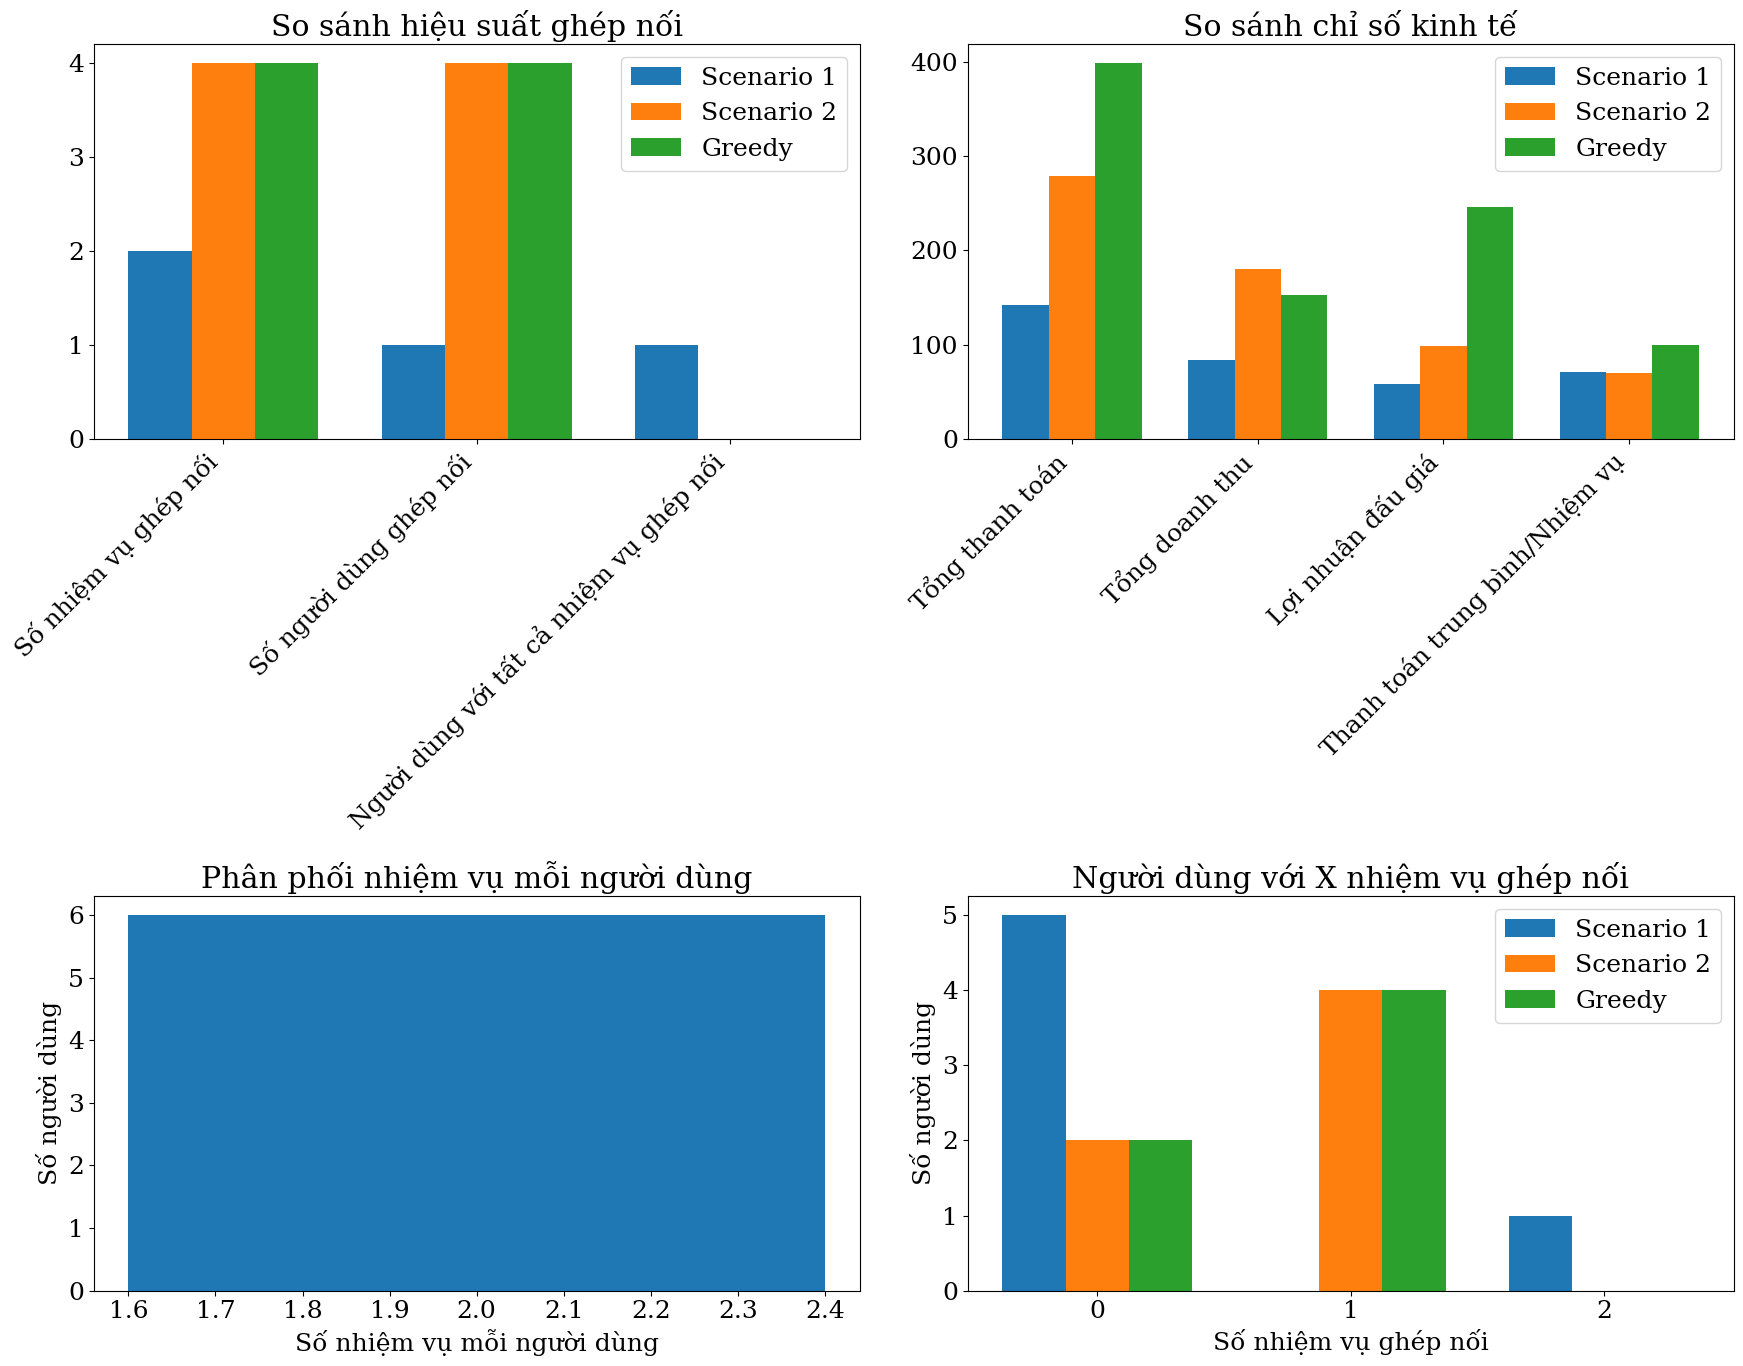

Trực quan hóa đã được lưu dưới dạng 'three_way_auction_comparison.png'
Generating dataset with 1000 users and 50 GAISPs...
Total number of tasks: 2000
Total GAISP capacity: 200

Running Scenario 1 (All tasks of each user must be matched)...
Scenario 1 completed in 0.02 seconds

Running Scenario 2 (Tasks can be partially matched)...
Scenario 2 completed in 0.00 seconds

Calculating performance metrics...

===== COMPARISON RESULTS =====
Metric                         Scenario 1      Scenario 2      Difference     
---------------------------------------------------------------------------
num_matched_tasks              76.00           104.00          +36.84%
num_matched_users              38.00           94.00           +147.37%
num_users_all_tasks_matched    38.00           10.00           -73.68%
total_payment                  10001.49        16059.59        +60.57%
total_revenue                  5704.67         9403.17         +64.83%
auctioneer_profit              4296.82         665

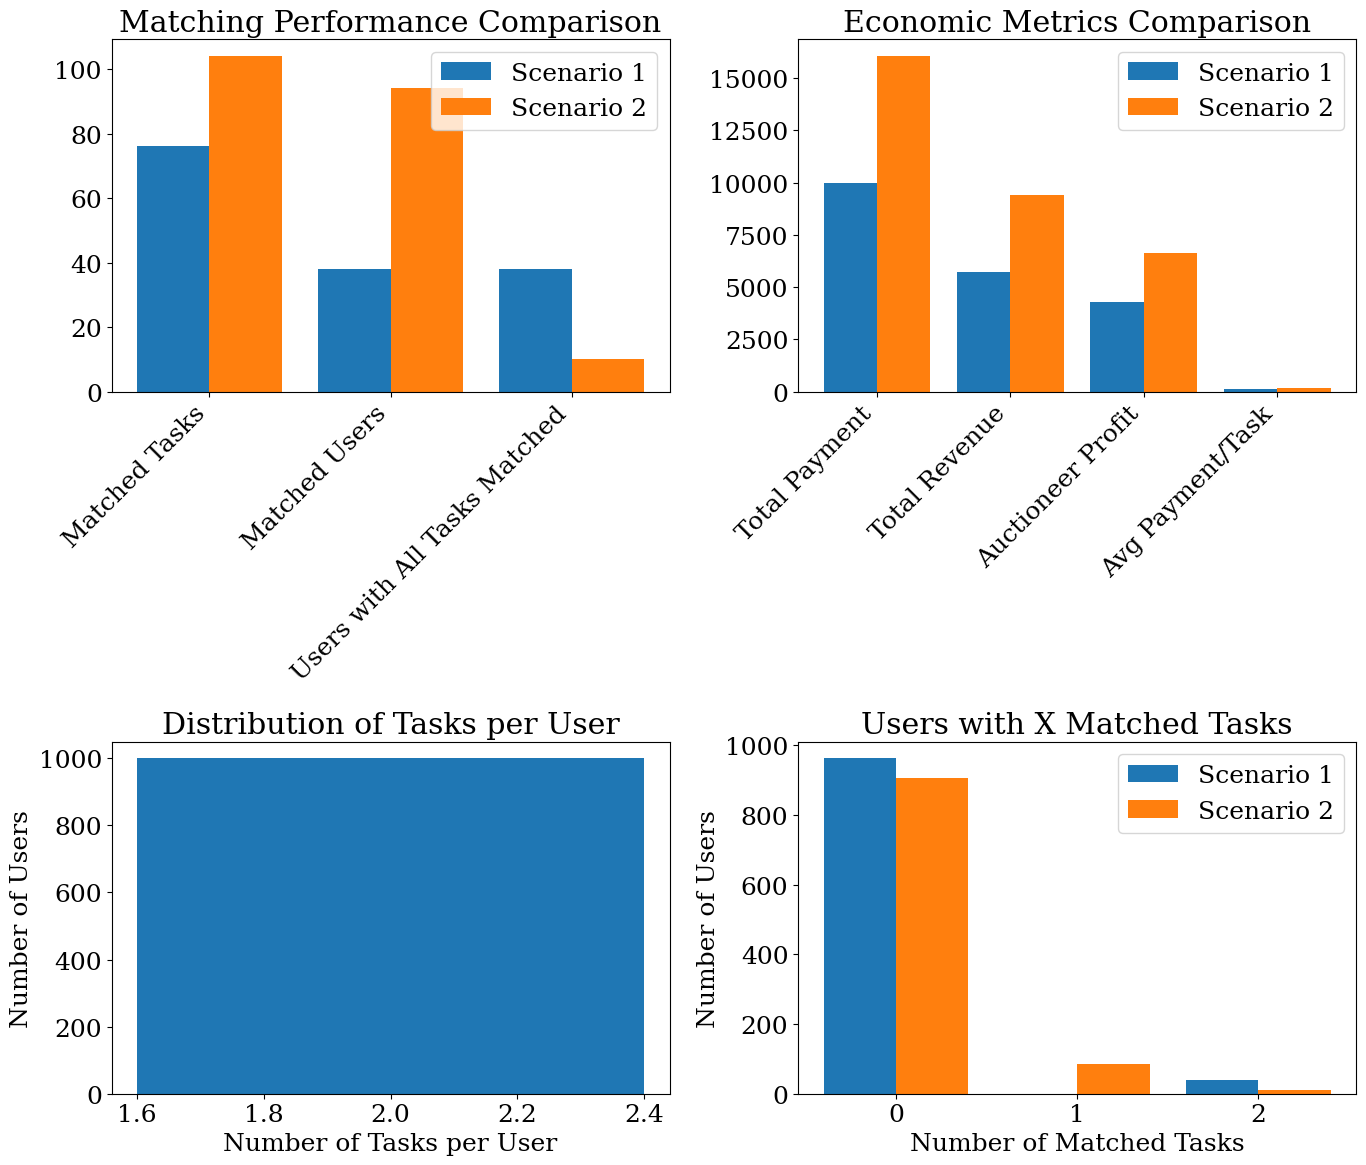

Visualization saved as 'auction_comparison.png'


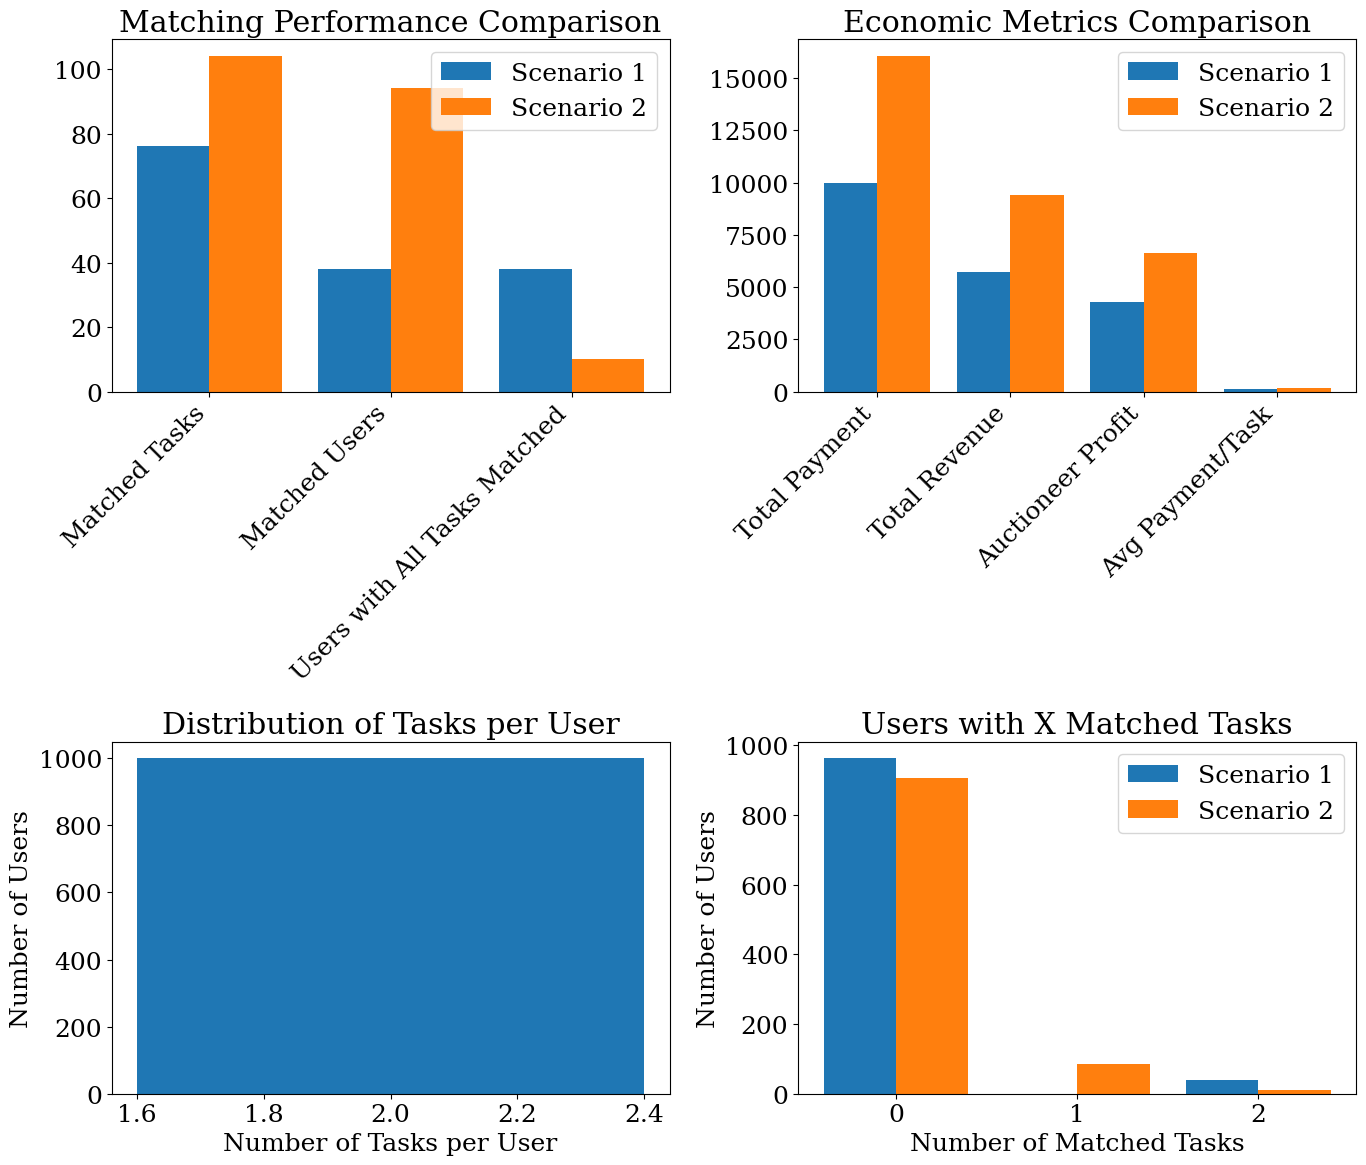

Visualization saved as 'auction_comparison.png'


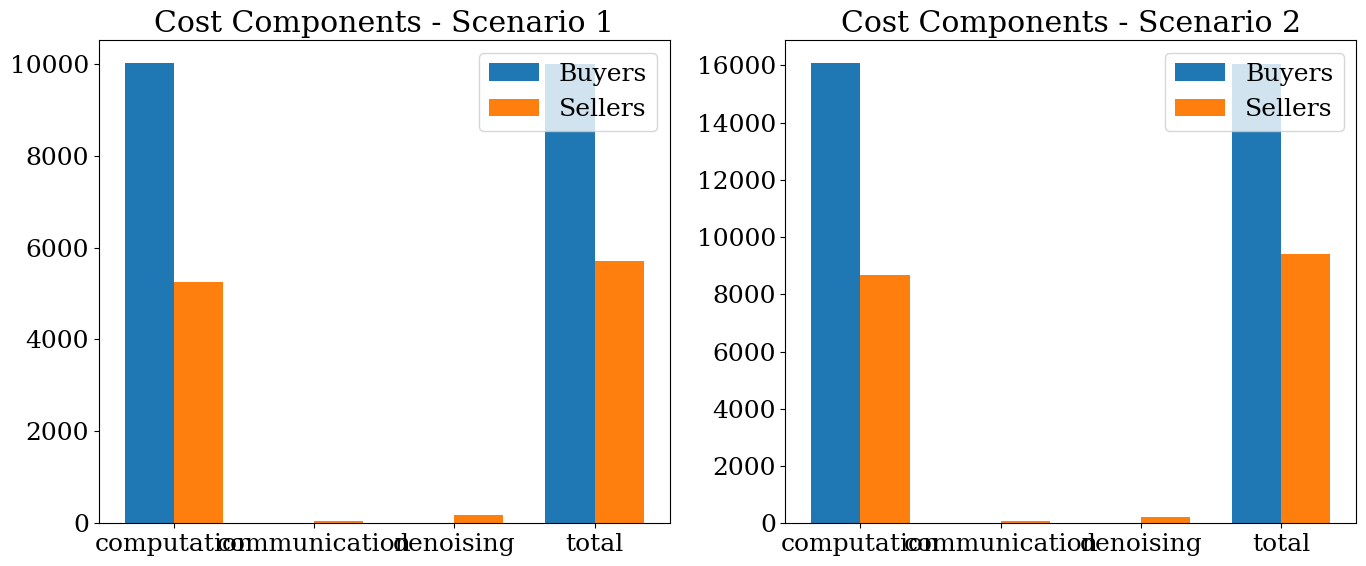

Cost comparison saved as 'cost_comparison.png'


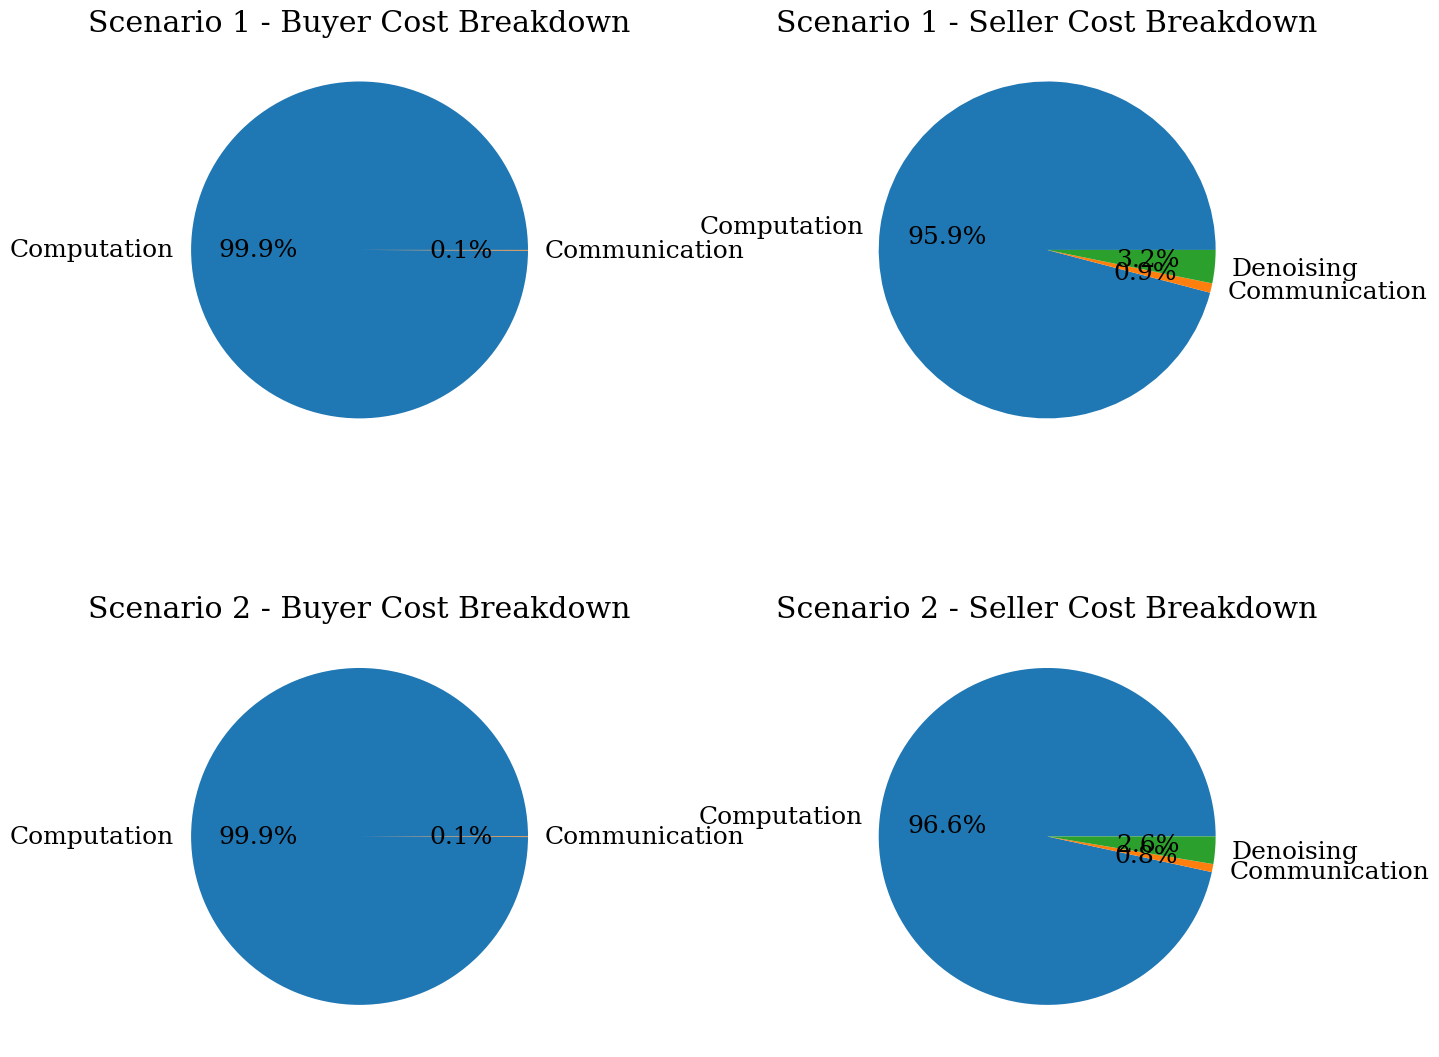

Cost percentage breakdown saved as 'cost_percentage_breakdown.png'


In [ ]:

def run_three_way_comparison(num_users=1000, num_gaisps=50, r_denoi_m=50):
    """
    So sánh cả ba thuật toán đấu giá
    """
    # Tạo bộ dữ liệu lớn
    print(f"Đang tạo bộ dữ liệu với {num_users} người dùng và {num_gaisps} GAISP...")
    users, gaisps, base_params = generate_large_dataset(num_users, num_gaisps, r_denoi_m)

    # Đếm tổng số nhiệm vụ
    total_tasks = sum(len(user.tasks) for user in users)
    print(f"Tổng số nhiệm vụ: {total_tasks}")

    # Đếm tổng công suất GAISP
    total_capacity = sum(gaisp.max_tasks for gaisp in gaisps)
    print(f"Tổng công suất GAISP: {total_capacity}")

    # Chạy Scenario 1
    print("\nĐang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...")
    start_time = time.time()
    matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
    scenario1_time = time.time() - start_time
    print(f"Scenario 1 hoàn thành trong {scenario1_time:.2f} giây")

    # Chạy Scenario 2
    print("\nĐang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...")
    start_time = time.time()
    matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
    scenario2_time = time.time() - start_time
    print(f"Scenario 2 hoàn thành trong {scenario2_time:.2f} giây")

    # Chạy thuật toán Greedy
    print("\nĐang chạy thuật toán Greedy...")
    start_time = time.time()
    matching_greedy, payment_prices_greedy, selling_prices_greedy = greedy_auction(users, gaisps, base_params)
    greedy_time = time.time() - start_time
    print(f"Thuật toán Greedy hoàn thành trong {greedy_time:.2f} giây")

    # Tính toán các chỉ số cho cả ba thuật toán
    print("\nĐang tính toán các chỉ số hiệu suất...")
    metrics1 = calculate_metrics(matching1, payment_prices1, selling_prices1, users, gaisps)
    metrics2 = calculate_metrics(matching2, payment_prices2, selling_prices2, users, gaisps)
    metrics_greedy = calculate_metrics(matching_greedy, payment_prices_greedy, selling_prices_greedy, users, gaisps)

    # In so sánh
    print("\n===== KẾT QUẢ SO SÁNH =====")
    print(f"{'Chỉ số':<30} {'Scenario 1':<15} {'Scenario 2':<15} {'Greedy':<15}")
    print("-" * 75)

    for key in metrics1.keys():
        print(f"{key:<30} {metrics1[key]:<15.2f} {metrics2[key]:<15.2f} {metrics_greedy[key]:<15.2f}")

    # Thêm so sánh thời gian thực thi
    print(f"{'Thời gian thực thi (s)':<30} {scenario1_time:<15.2f} {scenario2_time:<15.2f} {greedy_time:<15.2f}")

    # Phân tích phân phối nhiệm vụ (như trong mã gốc)
    user_task_counts = defaultdict(int)
    for user in users:
        user_task_counts[len(user.tasks)] += 1

    # Phân tích kết quả ghép nối người dùng
    s1_matched_users = defaultdict(int)
    for user_id, _ in matching1.keys():
        s1_matched_users[user_id] += 1

    s2_matched_users = defaultdict(int)
    for user_id, _ in matching2.keys():
        s2_matched_users[user_id] += 1

    greedy_matched_users = defaultdict(int)
    for user_id, _ in matching_greedy.keys():
        greedy_matched_users[user_id] += 1

    # Đếm người dùng với số lượng nhiệm vụ được ghép nối khác nhau
    s1_user_matched_counts = defaultdict(int)
    s2_user_matched_counts = defaultdict(int)
    greedy_user_matched_counts = defaultdict(int)

    for user in users:
        user_id = user.user_id
        total_tasks = len(user.tasks)

        s1_matched = s1_matched_users.get(user_id, 0)
        s2_matched = s2_matched_users.get(user_id, 0)
        greedy_matched = greedy_matched_users.get(user_id, 0)

        s1_user_matched_counts[s1_matched] += 1
        s2_user_matched_counts[s2_matched] += 1
        greedy_user_matched_counts[greedy_matched] += 1

    # Tạo dữ liệu trực quan hóa mở rộng để so sánh cả ba thuật toán
    return {
        "metrics1": metrics1,
        "metrics2": metrics2,
        "metrics_greedy": metrics_greedy,
        "scenario1_time": scenario1_time,
        "scenario2_time": scenario2_time,
        "greedy_time": greedy_time,
        "user_task_counts": user_task_counts,
        "s1_user_matched_counts": s1_user_matched_counts,
        "s2_user_matched_counts": s2_user_matched_counts,
        "greedy_user_matched_counts": greedy_user_matched_counts,
        "users": users,
        "gaisps": gaisps,
        "matching1": matching1,
        "payment_prices1": payment_prices1,
        "selling_prices1": selling_prices1,
        "matching2": matching2,
        "payment_prices2": payment_prices2,
        "selling_prices2": selling_prices2,
        "matching_greedy": matching_greedy,
        "payment_prices_greedy": payment_prices_greedy,
        "selling_prices_greedy": selling_prices_greedy
    }

def visualize_three_way_comparison(results):
    """
    Tạo trực quan hóa để so sánh cả ba thuật toán
    """
    # Tạo hình với các subplot
    fig, axs = plt.subplots(2, 2, figsize=(18, 14))

    # Plot 1: So sánh hiệu suất ghép nối
    metrics = ['num_matched_tasks', 'num_matched_users', 'num_users_all_tasks_matched']
    metric_labels = ['Số nhiệm vụ ghép nối', 'Số người dùng ghép nối', 'Người dùng với tất cả nhiệm vụ ghép nối']
    metrics1_values = [results['metrics1'][m] for m in metrics]
    metrics2_values = [results['metrics2'][m] for m in metrics]
    metrics_greedy_values = [results['metrics_greedy'][m] for m in metrics]

    bar_width = 0.25
    x = np.arange(len(metrics))

    axs[0, 0].bar(x - bar_width, metrics1_values, width=bar_width, label='Scenario 1')
    axs[0, 0].bar(x, metrics2_values, width=bar_width, label='Scenario 2')
    axs[0, 0].bar(x + bar_width, metrics_greedy_values, width=bar_width, label='Greedy')
    axs[0, 0].set_xticks(x)
    axs[0, 0].set_xticklabels(metric_labels, rotation=45, ha='right')
    axs[0, 0].set_title('So sánh hiệu suất ghép nối')
    axs[0, 0].legend()

    # Plot 2: So sánh chỉ số kinh tế
    econ_metrics = ['total_payment', 'total_revenue', 'auctioneer_profit', 'avg_payment_per_task']
    econ_labels = ['Tổng thanh toán', 'Tổng doanh thu', 'Lợi nhuận đấu giá', 'Thanh toán trung bình/Nhiệm vụ']

    econ1_values = [results['metrics1'][m] for m in econ_metrics]
    econ2_values = [results['metrics2'][m] for m in econ_metrics]
    econ_greedy_values = [results['metrics_greedy'][m] for m in econ_metrics]

    x = np.arange(len(econ_metrics))
    axs[0, 1].bar(x - bar_width, econ1_values, width=bar_width, label='Scenario 1')
    axs[0, 1].bar(x, econ2_values, width=bar_width, label='Scenario 2')
    axs[0, 1].bar(x + bar_width, econ_greedy_values, width=bar_width, label='Greedy')
    axs[0, 1].set_xticks(x)
    axs[0, 1].set_xticklabels(econ_labels, rotation=45, ha='right')
    axs[0, 1].set_title('So sánh chỉ số kinh tế')
    axs[0, 1].legend()

    # Plot 3: Phân phối nhiệm vụ người dùng
    task_counts = list(results['user_task_counts'].keys())
    task_frequencies = list(results['user_task_counts'].values())

    axs[1, 0].bar(task_counts, task_frequencies)
    axs[1, 0].set_xlabel('Số nhiệm vụ mỗi người dùng')
    axs[1, 0].set_ylabel('Số người dùng')
    axs[1, 0].set_title('Phân phối nhiệm vụ mỗi người dùng')

    # Plot 4: So sánh nhiệm vụ ghép nối
    max_tasks = max(
        max(results['s1_user_matched_counts'].keys(), default=0),
        max(results['s2_user_matched_counts'].keys(), default=0),
        max(results['greedy_user_matched_counts'].keys(), default=0)
    )

    s1_values = [results['s1_user_matched_counts'].get(i, 0) for i in range(max_tasks + 1)]
    s2_values = [results['s2_user_matched_counts'].get(i, 0) for i in range(max_tasks + 1)]
    greedy_values = [results['greedy_user_matched_counts'].get(i, 0) for i in range(max_tasks + 1)]

    x = np.arange(max_tasks + 1)
    axs[1, 1].bar(x - bar_width, s1_values, width=bar_width, label='Scenario 1')
    axs[1, 1].bar(x, s2_values, width=bar_width, label='Scenario 2')
    axs[1, 1].bar(x + bar_width, greedy_values, width=bar_width, label='Greedy')
    axs[1, 1].set_xticks(np.arange(max_tasks + 1))
    axs[1, 1].set_xlabel('Số nhiệm vụ ghép nối')
    axs[1, 1].set_ylabel('Số người dùng')
    axs[1, 1].set_title('Người dùng với X nhiệm vụ ghép nối')
    axs[1, 1].legend()

    # Điều chỉnh bố cục và lưu
    plt.tight_layout()
    plt.savefig('three_way_auction_comparison.png')
    plt.show()
    print("Trực quan hóa đã được lưu dưới dạng 'three_way_auction_comparison.png'")

def calculate_metrics(matching, payment_prices, selling_prices, users, gaisps):
    """
    Calculate various performance metrics for the auction results
    """
    metrics = {}

    # Count the number of matched tasks
    metrics['num_matched_tasks'] = len(matching)

    # Count number of users with at least one matched task
    matched_users = set(user_id for (user_id, _) in matching.keys())
    metrics['num_matched_users'] = len(matched_users)

    # Count number of users with all tasks matched
    all_tasks_matched_users = 0
    for user in users:
        user_tasks = len(user.tasks)
        matched_tasks = sum(1 for (u_id, _) in matching.keys() if u_id == user.user_id)
        if user_tasks == matched_tasks and user_tasks > 0:
            all_tasks_matched_users += 1
    metrics['num_users_all_tasks_matched'] = all_tasks_matched_users

    # Calculate total buyer payment
    total_payment = sum(payment_prices.values())
    metrics['total_payment'] = total_payment

    # Calculate total seller revenue
    total_revenue = sum(selling_prices.values())
    metrics['total_revenue'] = total_revenue

    # Calculate auctioneer profit
    metrics['auctioneer_profit'] = total_payment - total_revenue

    # Calculate matching efficiency (ratio of matched tasks to total tasks)
    total_tasks = sum(len(user.tasks) for user in users)
    metrics['matching_efficiency'] = metrics['num_matched_tasks'] / total_tasks if total_tasks > 0 else 0

    # Calculate average payment per task
    metrics['avg_payment_per_task'] = total_payment / metrics['num_matched_tasks'] if metrics['num_matched_tasks'] > 0 else 0

    # Calculate average revenue per task
    metrics['avg_revenue_per_task'] = total_revenue / metrics['num_matched_tasks'] if metrics['num_matched_tasks'] > 0 else 0

    return metrics

def run_comparison(num_users=1000, num_gaisps=80):
    """
    Run both auction scenarios and compare their performance
    """
    # Generate large dataset
    print(f"Generating dataset with {num_users} users and {num_gaisps} GAISPs...")
    users, gaisps, base_params = generate_large_dataset(num_users, num_gaisps)

    # Count total tasks
    total_tasks = sum(len(user.tasks) for user in users)
    print(f"Total number of tasks: {total_tasks}")

    # Count total GAISP capacity
    total_capacity = sum(gaisp.max_tasks for gaisp in gaisps)
    print(f"Total GAISP capacity: {total_capacity}")

    # Run Scenario 1
    print("\nRunning Scenario 1 (All tasks of each user must be matched)...")
    start_time = time.time()
    matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
    scenario1_time = time.time() - start_time
    print(f"Scenario 1 completed in {scenario1_time:.2f} seconds")

    # Run Scenario 2
    print("\nRunning Scenario 2 (Tasks can be partially matched)...")
    start_time = time.time()
    matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
    scenario2_time = time.time() - start_time
    print(f"Scenario 2 completed in {scenario2_time:.2f} seconds")

    # Calculate metrics for both scenarios
    print("\nCalculating performance metrics...")
    metrics1 = calculate_metrics(matching1, payment_prices1, selling_prices1, users, gaisps)
    metrics2 = calculate_metrics(matching2, payment_prices2, selling_prices2, users, gaisps)

    # Print comparison
    print("\n===== COMPARISON RESULTS =====")
    print(f"{'Metric':<30} {'Scenario 1':<15} {'Scenario 2':<15} {'Difference':<15}")
    print("-" * 75)

    for key in metrics1.keys():
        diff = metrics2[key] - metrics1[key]
        diff_percent = (diff / metrics1[key] * 100) if metrics1[key] != 0 else float('inf')
        print(f"{key:<30} {metrics1[key]:<15.2f} {metrics2[key]:<15.2f} {diff_percent:+.2f}%")

    # Add execution time comparison
    print(f"{'Execution time (s)':<30} {scenario1_time:<15.2f} {scenario2_time:<15.2f} {(scenario2_time-scenario1_time)/scenario1_time*100:+.2f}%")

    # Analyze task distribution
    user_task_counts = defaultdict(int)
    for user in users:
        user_task_counts[len(user.tasks)] += 1

    print("\nUser Task Distribution:")
    for tasks, count in sorted(user_task_counts.items()):
        print(f"{tasks} tasks: {count} users ({count/num_users*100:.1f}%)")

    # Analyze user matching results
    s1_matched_users = defaultdict(int)
    for user_id, _ in matching1.keys():
        s1_matched_users[user_id] += 1

    s2_matched_users = defaultdict(int)
    for user_id, _ in matching2.keys():
        s2_matched_users[user_id] += 1

    # Count users with different numbers of matched tasks
    s1_user_matched_counts = defaultdict(int)
    s2_user_matched_counts = defaultdict(int)

    for user in users:
        user_id = user.user_id
        total_tasks = len(user.tasks)

        s1_matched = s1_matched_users.get(user_id, 0)
        s2_matched = s2_matched_users.get(user_id, 0)

        s1_user_matched_counts[s1_matched] += 1
        s2_user_matched_counts[s2_matched] += 1

    print("\nScenario 1 - Number of users with X matched tasks:")
    for matched, count in sorted(s1_user_matched_counts.items()):
        print(f"{matched} tasks matched: {count} users ({count/num_users*100:.1f}%)")

    print("\nScenario 2 - Number of users with X matched tasks:")
    for matched, count in sorted(s2_user_matched_counts.items()):
        print(f"{matched} tasks matched: {count} users ({count/num_users*100:.1f}%)")

    # Create and return visualization data
    return {
        "metrics1": metrics1,
        "metrics2": metrics2,
        "scenario1_time": scenario1_time,
        "scenario2_time": scenario2_time,
        "user_task_counts": user_task_counts,
        "s1_user_matched_counts": s1_user_matched_counts,
        "s2_user_matched_counts": s2_user_matched_counts
    }

def visualize_results(results):
    """
    Create visualizations to compare the two scenarios
    """
    # Create figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    # # Plot 1: Matching efficiency comparison
    # metrics = ['num_matched_tasks', 'num_matched_users', 'num_users_all_tasks_matched', 'matching_efficiency']
    # metric_labels = ['Matched Tasks', 'Matched Users', 'Users with All Tasks Matched', 'Matching Efficiency']
    # metrics1_values = [results['metrics1'][m] if m != 'matching_efficiency' else results['metrics1'][m] * 100 for m in metrics]
    # metrics2_values = [results['metrics2'][m] if m != 'matching_efficiency' else results['metrics2'][m] * 100 for m in metrics]

    metrics = ['num_matched_tasks', 'num_matched_users', 'num_users_all_tasks_matched'] # Removed 'matching_efficiency'
    metric_labels = ['Matched Tasks', 'Matched Users', 'Users with All Tasks Matched'] # Removed 'Matching Efficiency'
    metrics1_values = [results['metrics1'][m] for m in metrics] # No conditional multiplication
    metrics2_values = [results['metrics2'][m] for m in metrics] # No conditional multiplication


    axs[0, 0].bar(np.arange(len(metrics)) - 0.2, metrics1_values, width=0.4, label='Scenario 1')
    axs[0, 0].bar(np.arange(len(metrics)) + 0.2, metrics2_values, width=0.4, label='Scenario 2')
    axs[0, 0].set_xticks(np.arange(len(metrics)))
    axs[0, 0].set_xticklabels(metric_labels, rotation=45, ha='right')
    axs[0, 0].set_title('Matching Performance Comparison')
    axs[0, 0].legend()

    # Plot 2: Economic metrics comparison
    econ_metrics = ['total_payment', 'total_revenue', 'auctioneer_profit', 'avg_payment_per_task']
    econ_labels = ['Total Payment', 'Total Revenue', 'Auctioneer Profit', 'Avg Payment/Task']
    econ1_values = [results['metrics1'][m] for m in econ_metrics]
    econ2_values = [results['metrics2'][m] for m in econ_metrics]

    axs[0, 1].bar(np.arange(len(econ_metrics)) - 0.2, econ1_values, width=0.4, label='Scenario 1')
    axs[0, 1].bar(np.arange(len(econ_metrics)) + 0.2, econ2_values, width=0.4, label='Scenario 2')
    axs[0, 1].set_xticks(np.arange(len(econ_metrics)))
    axs[0, 1].set_xticklabels(econ_labels, rotation=45, ha='right')
    axs[0, 1].set_title('Economic Metrics Comparison')
    axs[0, 1].legend()

    # Plot 3: User task distribution
    task_counts = list(results['user_task_counts'].keys())
    task_frequencies = list(results['user_task_counts'].values())

    axs[1, 0].bar(task_counts, task_frequencies)
    axs[1, 0].set_xlabel('Number of Tasks per User')
    axs[1, 0].set_ylabel('Number of Users')
    axs[1, 0].set_title('Distribution of Tasks per User')

    # Plot 4: Matched tasks comparison
    max_tasks = max(max(results['s1_user_matched_counts'].keys()), max(results['s2_user_matched_counts'].keys()))
    s1_values = [results['s1_user_matched_counts'].get(i, 0) for i in range(max_tasks + 1)]
    s2_values = [results['s2_user_matched_counts'].get(i, 0) for i in range(max_tasks + 1)]

    axs[1, 1].bar(np.arange(max_tasks + 1) - 0.2, s1_values, width=0.4, label='Scenario 1')
    axs[1, 1].bar(np.arange(max_tasks + 1) + 0.2, s2_values, width=0.4, label='Scenario 2')
    axs[1, 1].set_xticks(np.arange(max_tasks + 1))
    axs[1, 1].set_xlabel('Number of Matched Tasks')
    axs[1, 1].set_ylabel('Number of Users')
    axs[1, 1].set_title('Users with X Matched Tasks')
    axs[1, 1].legend()

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig('auction_comparison.png')
    plt.show()
    # plt.close()

    print("Visualization saved as 'auction_comparison.png'")

def calculate_cost_components(users, gaisps, matching, payment_prices, selling_prices):
    """
    Calculate different cost components for buyers and sellers in matched tasks
    """
    # Initialize cost dictionaries
    buyer_costs = {
        'computation': 0,
        'communication': 0,
        'total': 0
    }

    seller_costs = {
        'computation': 0,
        'communication': 0,
        'denoising': 0,
        'total': 0
    }

    # Calculate buyer-side costs
    for (user_id, task_id), price in payment_prices.items():
        # Find the user and task
        user = next((u for u in users if u.user_id == user_id), None)
        if not user:
            continue

        task = next((t for t in user.tasks if t.task_id == task_id), None)
        if not task:
            continue

        # Calculate cost components based on the original bid calculation
        computation_cost = user.xi_b * task.flops
        communication_cost = user.eta_b * task.comm_cost

        # Add to buyer costs
        buyer_costs['computation'] += computation_cost
        buyer_costs['communication'] += communication_cost
        buyer_costs['total'] += price  # Use actual payment price

    # Calculate seller-side costs
    for (gaisp_id, gaisp_task_id), revenue in selling_prices.items():
        # Find the GAISP
        gaisp = next((g for g in gaisps if g.gaisp_id == gaisp_id), None)
        if not gaisp:
            continue

        # Calculate cost components based on ask calculation
        computation_cost = gaisp.xi_s * gaisp.r_comp
        communication_cost = gaisp.eta_s * gaisp.r_comm
        denoising_cost = gaisp.zeta_s * gaisp.r_denoi

        # Add to seller costs
        seller_costs['computation'] += computation_cost
        seller_costs['communication'] += communication_cost
        seller_costs['denoising'] += denoising_cost
        seller_costs['total'] += revenue  # Use actual selling price

    return buyer_costs, seller_costs

def plot_cost_comparison(buyer_costs1, seller_costs1, buyer_costs2, seller_costs2):
    """
    Create bar charts comparing cost components between buyers and sellers for both scenarios
    """
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Scenario 1 chart
    components = ['computation', 'communication', 'denoising', 'total']
    buyer_values1 = [buyer_costs1.get(comp, 0) for comp in components]
    seller_values1 = [seller_costs1.get(comp, 0) for comp in components]

    # Replace 0 with NaN for buyer's denoising (which doesn't exist)
    buyer_values1[2] = float('nan')

    x = np.arange(len(components))
    width = 0.35

    axs[0].bar(x - width/2, buyer_values1, width, label='Buyers')
    axs[0].bar(x + width/2, seller_values1, width, label='Sellers')

    axs[0].set_title('Cost Components - Scenario 1')
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(components)
    axs[0].legend()

    # Scenario 2 chart
    buyer_values2 = [buyer_costs2.get(comp, 0) for comp in components]
    seller_values2 = [seller_costs2.get(comp, 0) for comp in components]

    # Replace 0 with NaN for buyer's denoising (which doesn't exist)
    buyer_values2[2] = float('nan')

    axs[1].bar(x - width/2, buyer_values2, width, label='Buyers')
    axs[1].bar(x + width/2, seller_values2, width, label='Sellers')

    axs[1].set_title('Cost Components - Scenario 2')
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(components)
    axs[1].legend()

    plt.tight_layout()
    plt.savefig('cost_comparison.png')
    plt.show()
    print("Cost comparison saved as 'cost_comparison.png'")

def visualize_results_extended(results, users, gaisps, matching1, payment_prices1, selling_prices1, matching2, payment_prices2, selling_prices2):
    """
    Extended version of visualize_results that includes cost component comparison
    """
    # Original visualization code
    visualize_results(results)

    # Calculate cost components for both scenarios
    buyer_costs1, seller_costs1 = calculate_cost_components(users, gaisps, matching1, payment_prices1, selling_prices1)
    buyer_costs2, seller_costs2 = calculate_cost_components(users, gaisps, matching2, payment_prices2, selling_prices2)

    # Create cost comparison chart
    plot_cost_comparison(buyer_costs1, seller_costs1, buyer_costs2, seller_costs2)

    # Add percentage breakdown chart
    plot_cost_percentage_breakdown(buyer_costs1, seller_costs1, buyer_costs2, seller_costs2)

def plot_cost_percentage_breakdown(buyer_costs1, seller_costs1, buyer_costs2, seller_costs2):
    """
    Create pie charts showing percentage breakdown of costs for buyers and sellers
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    # Scenario 1 - Buyer
    buyer_labels1 = ['Computation', 'Communication']
    buyer_values1 = [buyer_costs1['computation'], buyer_costs1['communication']]
    axs[0, 0].pie(buyer_values1, labels=buyer_labels1, autopct='%1.1f%%')
    axs[0, 0].set_title('Scenario 1 - Buyer Cost Breakdown')

    # Scenario 1 - Seller
    seller_labels1 = ['Computation', 'Communication', 'Denoising']
    seller_values1 = [seller_costs1['computation'], seller_costs1['communication'], seller_costs1['denoising']]
    axs[0, 1].pie(seller_values1, labels=seller_labels1, autopct='%1.1f%%')
    axs[0, 1].set_title('Scenario 1 - Seller Cost Breakdown')

    # Scenario 2 - Buyer
    buyer_labels2 = ['Computation', 'Communication']
    buyer_values2 = [buyer_costs2['computation'], buyer_costs2['communication']]
    axs[1, 0].pie(buyer_values2, labels=buyer_labels2, autopct='%1.1f%%')
    axs[1, 0].set_title('Scenario 2 - Buyer Cost Breakdown')

    # Scenario 2 - Seller
    seller_labels2 = ['Computation', 'Communication', 'Denoising']
    seller_values2 = [seller_costs2['computation'], seller_costs2['communication'], seller_costs2['denoising']]
    axs[1, 1].pie(seller_values2, labels=seller_labels2, autopct='%1.1f%%')
    axs[1, 1].set_title('Scenario 2 - Seller Cost Breakdown')

    plt.tight_layout()
    plt.savefig('cost_percentage_breakdown.png')
    plt.show()
    print("Cost percentage breakdown saved as 'cost_percentage_breakdown.png'")

# Update the run_comparison function to return more data
def run_comparison_extended(num_users=1000, num_gaisps=50):
    """
    Extended version of run_comparison that returns matching and pricing data
    """
    # Generate large dataset
    print(f"Generating dataset with {num_users} users and {num_gaisps} GAISPs...")
    users, gaisps, base_params = generate_large_dataset(num_users, num_gaisps)

    # Count total tasks
    total_tasks = sum(len(user.tasks) for user in users)
    print(f"Total number of tasks: {total_tasks}")

    # Count total GAISP capacity
    total_capacity = sum(gaisp.max_tasks for gaisp in gaisps)
    print(f"Total GAISP capacity: {total_capacity}")

    # Run Scenario 1
    print("\nRunning Scenario 1 (All tasks of each user must be matched)...")
    start_time = time.time()
    matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
    scenario1_time = time.time() - start_time
    print(f"Scenario 1 completed in {scenario1_time:.2f} seconds")

    # Run Scenario 2
    print("\nRunning Scenario 2 (Tasks can be partially matched)...")
    start_time = time.time()
    matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
    scenario2_time = time.time() - start_time
    print(f"Scenario 2 completed in {scenario2_time:.2f} seconds")

    # Calculate metrics for both scenarios
    print("\nCalculating performance metrics...")
    metrics1 = calculate_metrics(matching1, payment_prices1, selling_prices1, users, gaisps)
    metrics2 = calculate_metrics(matching2, payment_prices2, selling_prices2, users, gaisps)

    # Print comparison (original code)
    print("\n===== COMPARISON RESULTS =====")
    print(f"{'Metric':<30} {'Scenario 1':<15} {'Scenario 2':<15} {'Difference':<15}")
    print("-" * 75)

    for key in metrics1.keys():
        diff = metrics2[key] - metrics1[key]
        diff_percent = (diff / metrics1[key] * 100) if metrics1[key] != 0 else float('inf')
        print(f"{key:<30} {metrics1[key]:<15.2f} {metrics2[key]:<15.2f} {diff_percent:+.2f}%")

    # Add execution time comparison
    print(f"{'Execution time (s)':<30} {scenario1_time:<15.2f} {scenario2_time:<15.2f} {(scenario2_time-scenario1_time)/scenario1_time*100:+.2f}%")

    # Rest of the original code...
    user_task_counts = defaultdict(int)
    for user in users:
        user_task_counts[len(user.tasks)] += 1

    print("\nUser Task Distribution:")
    for tasks, count in sorted(user_task_counts.items()):
        print(f"{tasks} tasks: {count} users ({count/num_users*100:.1f}%)")

    # Analyze user matching results
    s1_matched_users = defaultdict(int)
    for user_id, _ in matching1.keys():
        s1_matched_users[user_id] += 1

    s2_matched_users = defaultdict(int)
    for user_id, _ in matching2.keys():
        s2_matched_users[user_id] += 1

    # Count users with different numbers of matched tasks
    s1_user_matched_counts = defaultdict(int)
    s2_user_matched_counts = defaultdict(int)

    for user in users:
        user_id = user.user_id
        total_tasks = len(user.tasks)

        s1_matched = s1_matched_users.get(user_id, 0)
        s2_matched = s2_matched_users.get(user_id, 0)

        s1_user_matched_counts[s1_matched] += 1
        s2_user_matched_counts[s2_matched] += 1

    # Return extended results including original data plus matching and pricing data
    return {
        "metrics1": metrics1,
        "metrics2": metrics2,
        "scenario1_time": scenario1_time,
        "scenario2_time": scenario2_time,
        "user_task_counts": user_task_counts,
        "s1_user_matched_counts": s1_user_matched_counts,
        "s2_user_matched_counts": s2_user_matched_counts,
        "users": users,
        "gaisps": gaisps,
        "matching1": matching1,
        "payment_prices1": payment_prices1,
        "selling_prices1": selling_prices1,
        "matching2": matching2,
        "payment_prices2": payment_prices2,
        "selling_prices2": selling_prices2
    }

# Update the main function
if __name__ == "__main__":
    np.random.seed(42)  # For reproducibility
    results = run_three_way_comparison(num_users=6, num_gaisps=50)
    visualize_three_way_comparison(results)

    results = run_comparison_extended(num_users=1000, num_gaisps=50)
    visualize_results(results)

    # Use the extended visualization function
    visualize_results_extended(
        results,
        results["users"],
        results["gaisps"],
        results["matching1"],
        results["payment_prices1"],
        results["selling_prices1"],
        results["matching2"],
        results["payment_prices2"],
        results["selling_prices2"]
    )


Đang so sánh lợi nhuận đấu giá với 70 người dùng và số GAISP thay đổi...

Chạy với 50 GAISP...
Đang tạo bộ dữ liệu với 70 người dùng và 50 GAISP...
Tổng số nhiệm vụ: 140
Tổng công suất GAISP: 200

Đang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...
Scenario 1 hoàn thành trong 0.00 giây

Đang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...
Scenario 2 hoàn thành trong 0.00 giây

Đang chạy thuật toán Greedy...
Thuật toán Greedy hoàn thành trong 0.01 giây

Đang tính toán các chỉ số hiệu suất...

===== KẾT QUẢ SO SÁNH =====
Chỉ số                         Scenario 1      Scenario 2      Greedy         
---------------------------------------------------------------------------
num_matched_tasks              14.00           32.00           32.00          
num_matched_users              7.00            27.00           27.00          
num_users_all_tasks_matched    7.00            5.00            5.00           
total_payment                  1583.50     

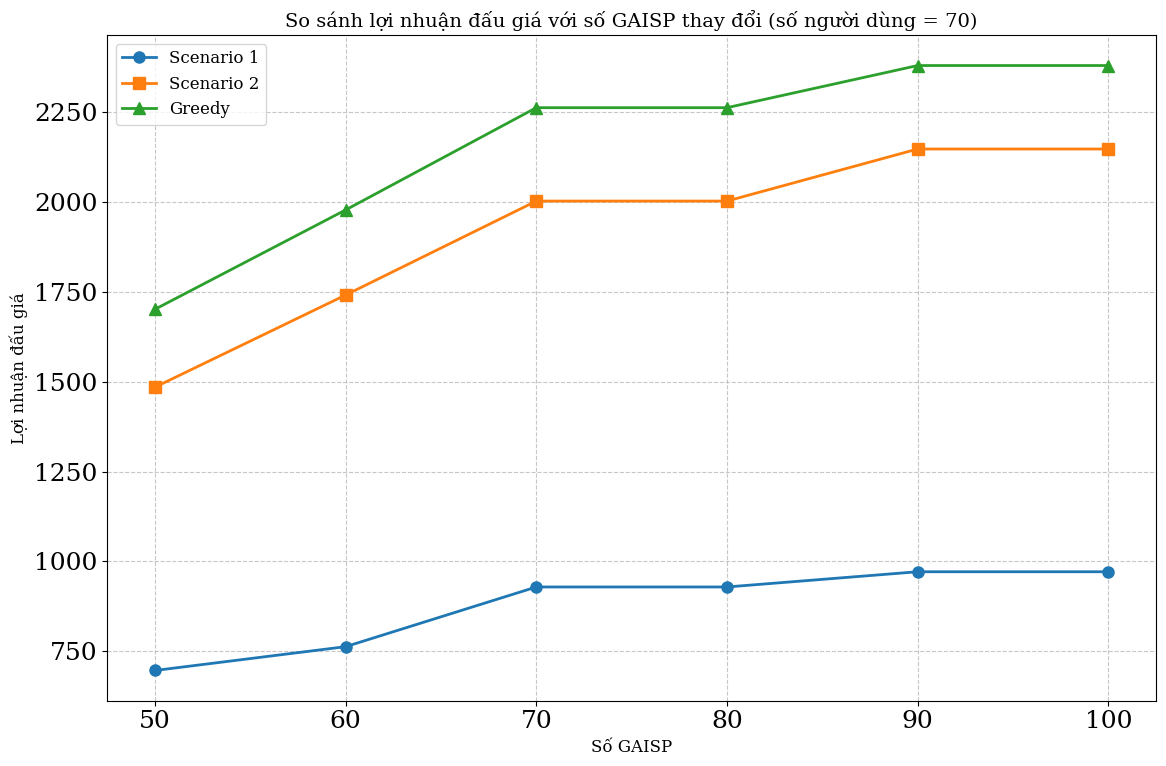

Biểu đồ đã được lưu dưới dạng 'auction_profit_comparison_GAISP.png'

===== BẢNG KẾT QUẢ CHI TIẾT =====
Số GAISP   Scenario 1      Scenario 2      Greedy         
-------------------------------------------------------
50         696.84          1484.77         1701.38        
60         763.07          1741.07         1977.70        
70         929.09          2002.40         2262.11        
80         929.09          2002.40         2262.11        
90         971.43          2147.16         2379.35        
100        971.43          2147.16         2379.35        


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

def compare_profits_with_varying_gaisps(fixed_users=6, gaisp_range=[50, 60, 70, 80, 90, 100]):
    """
    So sánh lợi nhuận đấu giá của cả ba thuật toán với số người dùng cố định
    và số GAISP thay đổi
    """
    # Lưu trữ kết quả
    scenario1_profits = []
    scenario2_profits = []
    greedy_profits = []

    print(f"Đang so sánh lợi nhuận đấu giá với {fixed_users} người dùng và số GAISP thay đổi...")

    # Chạy so sánh cho mỗi giá trị num_gaisps
    for num_gaisps in gaisp_range:
        print(f"\nChạy với {num_gaisps} GAISP...")
        # Đặt seed để kết quả có thể tái tạo được
        np.random.seed(42)
        # Chạy so sánh
        results = run_three_way_comparison(num_users=fixed_users, num_gaisps=num_gaisps)

        # Lưu lợi nhuận đấu giá
        scenario1_profits.append(results['metrics1']['auctioneer_profit'])
        scenario2_profits.append(results['metrics2']['auctioneer_profit'])
        greedy_profits.append(results['metrics_greedy']['auctioneer_profit'])

        # In kết quả
        print(f"Lợi nhuận đấu giá với {num_gaisps} GAISP:")
        print(f"- Scenario 1: {results['metrics1']['auctioneer_profit']:.2f}")
        print(f"- Scenario 2: {results['metrics2']['auctioneer_profit']:.2f}")
        print(f"- Greedy: {results['metrics_greedy']['auctioneer_profit']:.2f}")

    # Vẽ biểu đồ đường
    plt.figure(figsize=(12, 8))
    plt.plot(gaisp_range, scenario1_profits, 'o-', label='Scenario 1', linewidth=2, markersize=8)
    plt.plot(gaisp_range, scenario2_profits, 's-', label='Scenario 2', linewidth=2, markersize=8)
    plt.plot(gaisp_range, greedy_profits, '^-', label='Greedy', linewidth=2, markersize=8)

    plt.title(f'So sánh lợi nhuận đấu giá với số GAISP thay đổi (số người dùng = {fixed_users})', fontsize=14)
    plt.xlabel('Số GAISP', fontsize=12)
    plt.ylabel('Lợi nhuận đấu giá', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(gaisp_range)
    plt.tight_layout()

    # Lưu và hiển thị biểu đồ
    plt.savefig('auction_profit_comparison_GAISP.png')
    plt.show()
    print("Biểu đồ đã được lưu dưới dạng 'auction_profit_comparison_GAISP.png'")

    # Trả về dữ liệu để phân tích thêm nếu cần
    return {
        'gaisp_range': gaisp_range,
        'scenario1_profits': scenario1_profits,
        'scenario2_profits': scenario2_profits,
        'greedy_profits': greedy_profits
    }

# Thêm một hàm chạy mà bạn có thể sử dụng để thực hiện phân tích này
def run_profit_comparison_analysis():
    np.random.seed(42)  # Để kết quả có thể tái tạo được
    gaisp_range = [50, 60, 70, 80, 90, 100]
    fixed_users = 70

    results = compare_profits_with_varying_gaisps(fixed_users=fixed_users, gaisp_range=gaisp_range)

    # In bảng kết quả
    print("\n===== BẢNG KẾT QUẢ CHI TIẾT =====")
    print(f"{'Số GAISP':<10} {'Scenario 1':<15} {'Scenario 2':<15} {'Greedy':<15}")
    print("-" * 55)

    for i, num_gaisps in enumerate(results['gaisp_range']):
        print(f"{num_gaisps:<10} {results['scenario1_profits'][i]:<15.2f} "
              f"{results['scenario2_profits'][i]:<15.2f} {results['greedy_profits'][i]:<15.2f}")

# Chỉ cần gọi hàm này để chạy phân tích
if __name__ == "__main__":
    run_profit_comparison_analysis()

Đang so sánh lợi nhuận đấu giá với 70 GAISP và số người dùng thay đổi...

Chạy với 50 người dùng...
Đang tạo bộ dữ liệu với 50 người dùng và 70 GAISP...
Tổng số nhiệm vụ: 100
Tổng công suất GAISP: 280

Đang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...
Scenario 1 hoàn thành trong 0.00 giây

Đang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...
Scenario 2 hoàn thành trong 0.00 giây

Đang chạy thuật toán Greedy...
Thuật toán Greedy hoàn thành trong 0.00 giây

Đang tính toán các chỉ số hiệu suất...

===== KẾT QUẢ SO SÁNH =====
Chỉ số                         Scenario 1      Scenario 2      Greedy         
---------------------------------------------------------------------------
num_matched_tasks              12.00           36.00           36.00          
num_matched_users              6.00            31.00           31.00          
num_users_all_tasks_matched    6.00            5.00            5.00           
total_payment                  1374.31

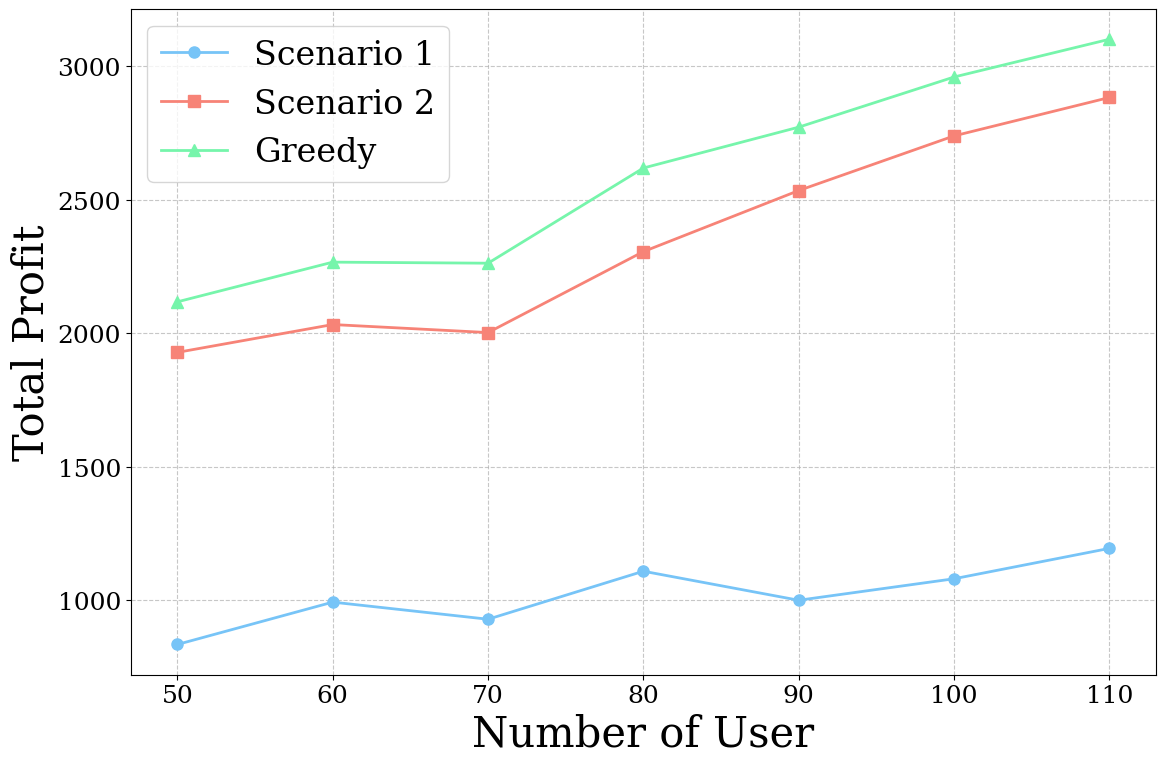

Biểu đồ đã được lưu dưới dạng 'auction_profit_comparison_users.png'

===== BẢNG KẾT QUẢ CHI TIẾT =====
Số người dùng   Scenario 1      Scenario 2      Greedy         
------------------------------------------------------------
50              834.66          1928.19         2117.44        
60              993.16          2032.43         2266.06        
70              929.09          2002.40         2262.11        
80              1108.87         2305.49         2618.43        
90              1000.17         2534.16         2771.46        
100             1080.65         2738.74         2959.22        
110             1194.40         2882.58         3100.54        

===== TỶ LỆ TĂNG TRƯỞNG (%) =====
Thay đổi người dùng  Scenario 1      Scenario 2      Greedy         
-----------------------------------------------------------------
50 → 60:<20 18.99           5.41            7.02           
60 → 70:<20 -6.45           -1.48           -0.17          
70 → 80:<20 19.35           15.14 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

def compare_profits_with_varying_users(fixed_gaisps=70, user_range=[50, 60, 70, 80, 90, 100]):
    """
    So sánh lợi nhuận đấu giá của cả ba thuật toán với số GAISP cố định
    và số người dùng thay đổi
    """
    # Lưu trữ kết quả
    scenario1_profits = []
    scenario2_profits = []
    greedy_profits = []

    print(f"Đang so sánh lợi nhuận đấu giá với {fixed_gaisps} GAISP và số người dùng thay đổi...")

    # Chạy so sánh cho mỗi giá trị num_users
    for num_users in user_range:
        print(f"\nChạy với {num_users} người dùng...")
        # Đặt seed để kết quả có thể tái tạo được
        np.random.seed(42)
        # Chạy so sánh
        results = run_three_way_comparison(num_users=num_users, num_gaisps=fixed_gaisps)

        # Lưu lợi nhuận đấu giá
        scenario1_profits.append(results['metrics1']['auctioneer_profit'])
        scenario2_profits.append(results['metrics2']['auctioneer_profit'])
        greedy_profits.append(results['metrics_greedy']['auctioneer_profit'])

        # In kết quả
        print(f"Lợi nhuận đấu giá với {num_users} người dùng:")
        print(f"- Scenario 1: {results['metrics1']['auctioneer_profit']:.2f}")
        print(f"- Scenario 2: {results['metrics2']['auctioneer_profit']:.2f}")
        print(f"- Greedy: {results['metrics_greedy']['auctioneer_profit']:.2f}")

    # Vẽ biểu đồ đường
    plt.figure(figsize=(12, 8))
    plt.plot(user_range, scenario1_profits, 'o-', color='#77c4f7', label='Scenario 1', linewidth=2, markersize=8)
    plt.plot(user_range, scenario2_profits, 's-', color="#f78377", label='Scenario 2', linewidth=2, markersize=8)
    plt.plot(user_range, greedy_profits, '^-',color="#76f5ab", label='Greedy', linewidth=2, markersize=8)

    # plt.title('So sánh lợi nhuận đấu giá với số người dùng thay đổi (số GAISP = 70)', fontsize=14)
    plt.xlabel('Number of User', fontsize=30)
    plt.ylabel('Total Profit', fontsize=30)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=24)
    plt.xticks(user_range)
    plt.tight_layout()

    # Lưu và hiển thị biểu đồ
    plt.savefig('auction_profit_comparison_users.pdf')
    plt.show()
    print("Biểu đồ đã được lưu dưới dạng 'auction_profit_comparison_users.png'")

    # Trả về dữ liệu để phân tích thêm nếu cần
    return {
        'user_range': user_range,
        'scenario1_profits': scenario1_profits,
        'scenario2_profits': scenario2_profits,
        'greedy_profits': greedy_profits
    }

# Thêm một hàm chạy để thực hiện phân tích
def run_profit_comparison_users_analysis():
    np.random.seed(42)  # Để kết quả có thể tái tạo được
    user_range = [i for i in range(50, 120, 10)]
    fixed_gaisps = 70

    results = compare_profits_with_varying_users(fixed_gaisps=fixed_gaisps, user_range=user_range)

    # In bảng kết quả
    print("\n===== BẢNG KẾT QUẢ CHI TIẾT =====")
    print(f"{'Số người dùng':<15} {'Scenario 1':<15} {'Scenario 2':<15} {'Greedy':<15}")
    print("-" * 60)

    for i, num_users in enumerate(results['user_range']):
        print(f"{num_users:<15} {results['scenario1_profits'][i]:<15.2f} "
              f"{results['scenario2_profits'][i]:<15.2f} {results['greedy_profits'][i]:<15.2f}")

    # Tính tỷ lệ tăng trưởng
    print("\n===== TỶ LỆ TĂNG TRƯỞNG (%) =====")
    print(f"{'Thay đổi người dùng':<20} {'Scenario 1':<15} {'Scenario 2':<15} {'Greedy':<15}")
    print("-" * 65)

    for i in range(1, len(user_range)):
        prev_users = user_range[i-1]
        curr_users = user_range[i]

        growth_s1 = ((results['scenario1_profits'][i] - results['scenario1_profits'][i-1]) /
                     results['scenario1_profits'][i-1] * 100) if results['scenario1_profits'][i-1] != 0 else float('inf')

        growth_s2 = ((results['scenario2_profits'][i] - results['scenario2_profits'][i-1]) /
                    results['scenario2_profits'][i-1] * 100) if results['scenario2_profits'][i-1] != 0 else float('inf')

        growth_gr = ((results['greedy_profits'][i] - results['greedy_profits'][i-1]) /
                    results['greedy_profits'][i-1] * 100) if results['greedy_profits'][i-1] != 0 else float('inf')

        print(f"{prev_users} → {curr_users}:<20 {growth_s1:<15.2f} {growth_s2:<15.2f} {growth_gr:<15.2f}")

# Chỉ cần gọi hàm này để chạy phân tích
if __name__ == "__main__":
    run_profit_comparison_users_analysis()

Đang so sánh lợi nhuận đấu giá với 10 người dùng, 10 GAISP và r_denoi_m thay đổi...

Chạy với r_denoi_m = 20...
Đang tạo bộ dữ liệu với 10 người dùng và 10 GAISP...
Tổng số nhiệm vụ: 20
Tổng công suất GAISP: 40

Đang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...
Scenario 1 hoàn thành trong 0.00 giây

Đang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...
Scenario 2 hoàn thành trong 0.00 giây

Đang chạy thuật toán Greedy...
Thuật toán Greedy hoàn thành trong 0.00 giây

Đang tính toán các chỉ số hiệu suất...

===== KẾT QUẢ SO SÁNH =====
Chỉ số                         Scenario 1      Scenario 2      Greedy         
---------------------------------------------------------------------------
num_matched_tasks              2.00            5.00            5.00           
num_matched_users              1.00            4.00            4.00           
num_users_all_tasks_matched    1.00            1.00            1.00           
total_payment               

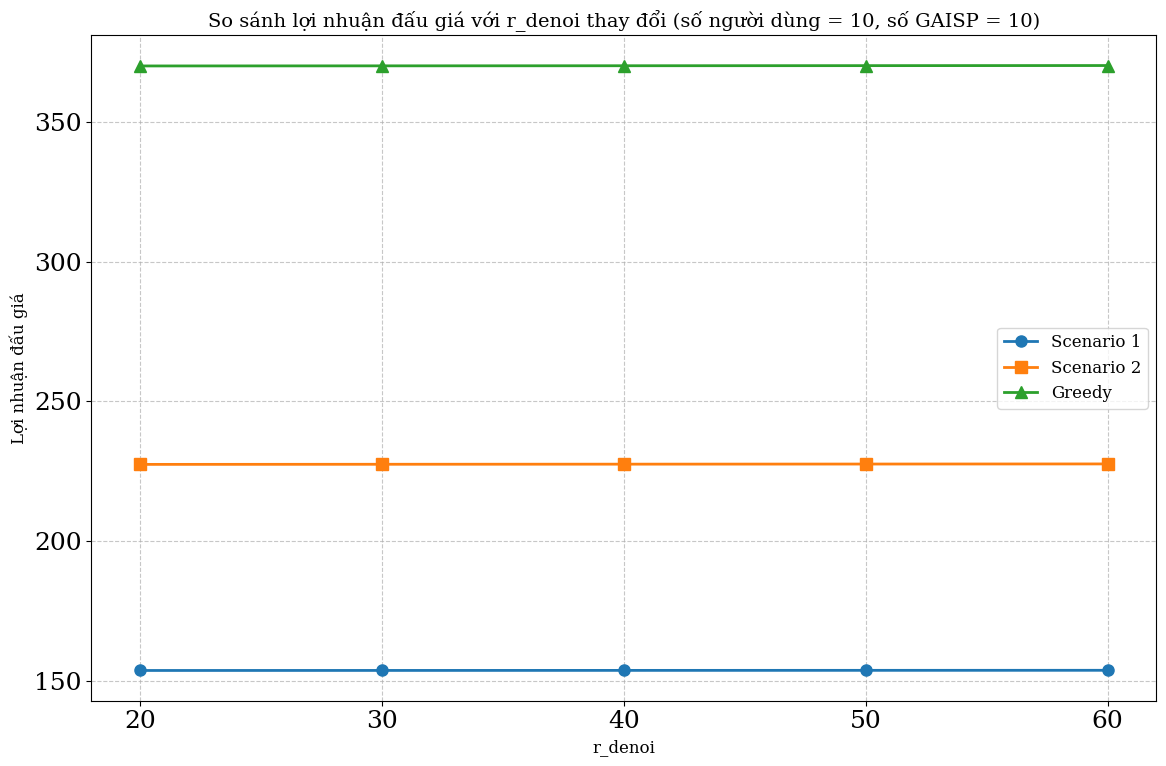

Biểu đồ đã được lưu dưới dạng 'auction_profit_r_denoi_comparison.png'

===== BẢNG KẾT QUẢ CHI TIẾT =====
r_denoi_m  Scenario 1      Scenario 2      Greedy         
-------------------------------------------------------
20         153.76          227.48          370.01         
30         153.77          227.52          370.05         
40         153.79          227.56          370.09         
50         153.80          227.60          370.12         
60         153.82          227.64          370.16         


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

def compare_profits_with_varying_r_denoi(fixed_users=70, fixed_gaisps=70, r_denoi_range=[20, 30, 40, 50, 60]):
    """
    So sánh lợi nhuận đấu giá của cả ba thuật toán với số người dùng và số GAISP cố định
    và giá trị r_denoi_m thay đổi
    """
    # Lưu trữ kết quả
    scenario1_profits = []
    scenario2_profits = []
    greedy_profits = []

    print(f"Đang so sánh lợi nhuận đấu giá với {fixed_users} người dùng, {fixed_gaisps} GAISP và r_denoi_m thay đổi...")

    # Chạy so sánh cho mỗi giá trị r_denoi_m
    for r_denoi_m in r_denoi_range:
        print(f"\nChạy với r_denoi_m = {r_denoi_m}...")
        # Đặt seed để kết quả có thể tái tạo được
        np.random.seed(42)
        # Chạy so sánh
        results = run_three_way_comparison(num_users=fixed_users, num_gaisps=fixed_gaisps, r_denoi_m=r_denoi_m)

        # Lưu lợi nhuận đấu giá
        scenario1_profits.append(results['metrics1']['auctioneer_profit'])
        scenario2_profits.append(results['metrics2']['auctioneer_profit'])
        greedy_profits.append(results['metrics_greedy']['auctioneer_profit'])

        # In kết quả
        print(f"Lợi nhuận đấu giá với r_denoi_m = {r_denoi_m}:")
        print(f"- Scenario 1: {results['metrics1']['auctioneer_profit']:.2f}")
        print(f"- Scenario 2: {results['metrics2']['auctioneer_profit']:.2f}")
        print(f"- Greedy: {results['metrics_greedy']['auctioneer_profit']:.2f}")

    # Vẽ biểu đồ đường
    plt.figure(figsize=(12, 8))
    plt.plot(r_denoi_range, scenario1_profits, 'o-', label='Scenario 1', linewidth=2, markersize=8)
    plt.plot(r_denoi_range, scenario2_profits, 's-', label='Scenario 2', linewidth=2, markersize=8)
    plt.plot(r_denoi_range, greedy_profits, '^-', label='Greedy', linewidth=2, markersize=8)

    plt.title(f'So sánh lợi nhuận đấu giá với r_denoi thay đổi (số người dùng = {fixed_users}, số GAISP = {fixed_gaisps})', fontsize=14)
    plt.xlabel('r_denoi', fontsize=12)
    plt.ylabel('Lợi nhuận đấu giá', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(r_denoi_range)
    plt.tight_layout()

    # Lưu và hiển thị biểu đồ
    plt.savefig('auction_profit_r_denoi_comparison.png')
    plt.show()
    print("Biểu đồ đã được lưu dưới dạng 'auction_profit_r_denoi_comparison.png'")

    # Trả về dữ liệu để phân tích thêm nếu cần
    return {
        'r_denoi_range': r_denoi_range,
        'scenario1_profits': scenario1_profits,
        'scenario2_profits': scenario2_profits,
        'greedy_profits': greedy_profits
    }

# Thêm một hàm chạy mà bạn có thể sử dụng để thực hiện phân tích này
def run_profit_comparison_r_denoi_analysis():
    np.random.seed(42)  # Để kết quả có thể tái tạo được
    r_denoi_range = [20, 30, 40, 50, 60]
    fixed_users = 10
    fixed_gaisps = 10

    results = compare_profits_with_varying_r_denoi(fixed_users=fixed_users, fixed_gaisps=fixed_gaisps, r_denoi_range=r_denoi_range)

    # In bảng kết quả
    print("\n===== BẢNG KẾT QUẢ CHI TIẾT =====")
    print(f"{'r_denoi_m':<10} {'Scenario 1':<15} {'Scenario 2':<15} {'Greedy':<15}")
    print("-" * 55)

    for i, r_denoi_m in enumerate(results['r_denoi_range']):
        print(f"{r_denoi_m:<10} {results['scenario1_profits'][i]:<15.2f} "
              f"{results['scenario2_profits'][i]:<15.2f} {results['greedy_profits'][i]:<15.2f}")

# Chỉ cần gọi hàm này để chạy phân tích
if __name__ == "__main__":
    run_profit_comparison_r_denoi_analysis()

## Boxplot compare

Đang tạo bộ dữ liệu với 70 người dùng và 60 GAISP...
Tổng số nhiệm vụ: 140
Tổng công suất GAISP: 240

Đang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...
Scenario 1 hoàn thành trong 0.00 giây

Đang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...
Scenario 2 hoàn thành trong 0.00 giây

Đang chạy thuật toán Greedy...
Thuật toán Greedy hoàn thành trong 0.00 giây

Đang tính toán các chỉ số hiệu suất...

===== KẾT QUẢ SO SÁNH =====
Chỉ số                         Scenario 1      Scenario 2      Greedy         
---------------------------------------------------------------------------
num_matched_tasks              16.00           35.00           35.00          
num_matched_users              8.00            29.00           29.00          
num_users_all_tasks_matched    8.00            6.00            6.00           
total_payment                  1742.88         4153.36         4233.06        
total_revenue                  979.81          2412.28     

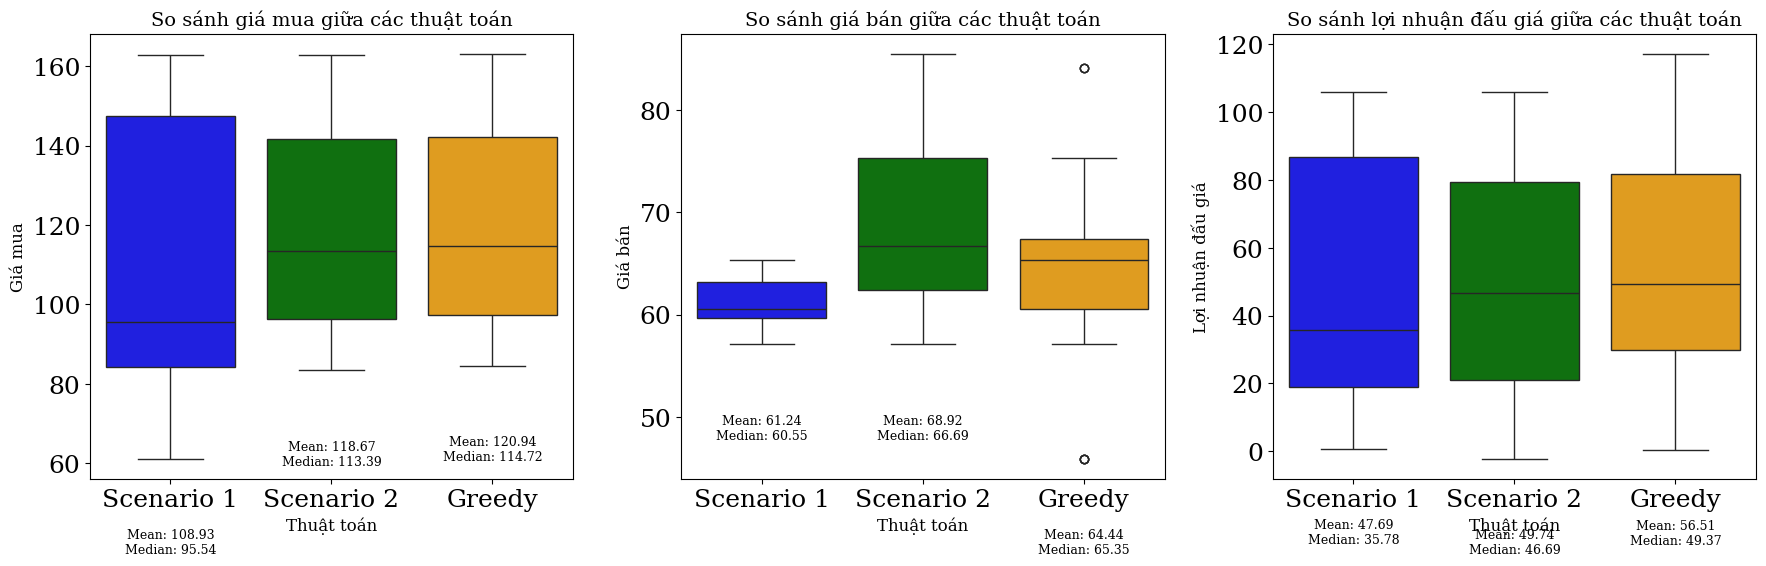

Boxplot so sánh đã được lưu dưới dạng 'boxplot_comparison.png'


<Figure size 1600x800 with 0 Axes>

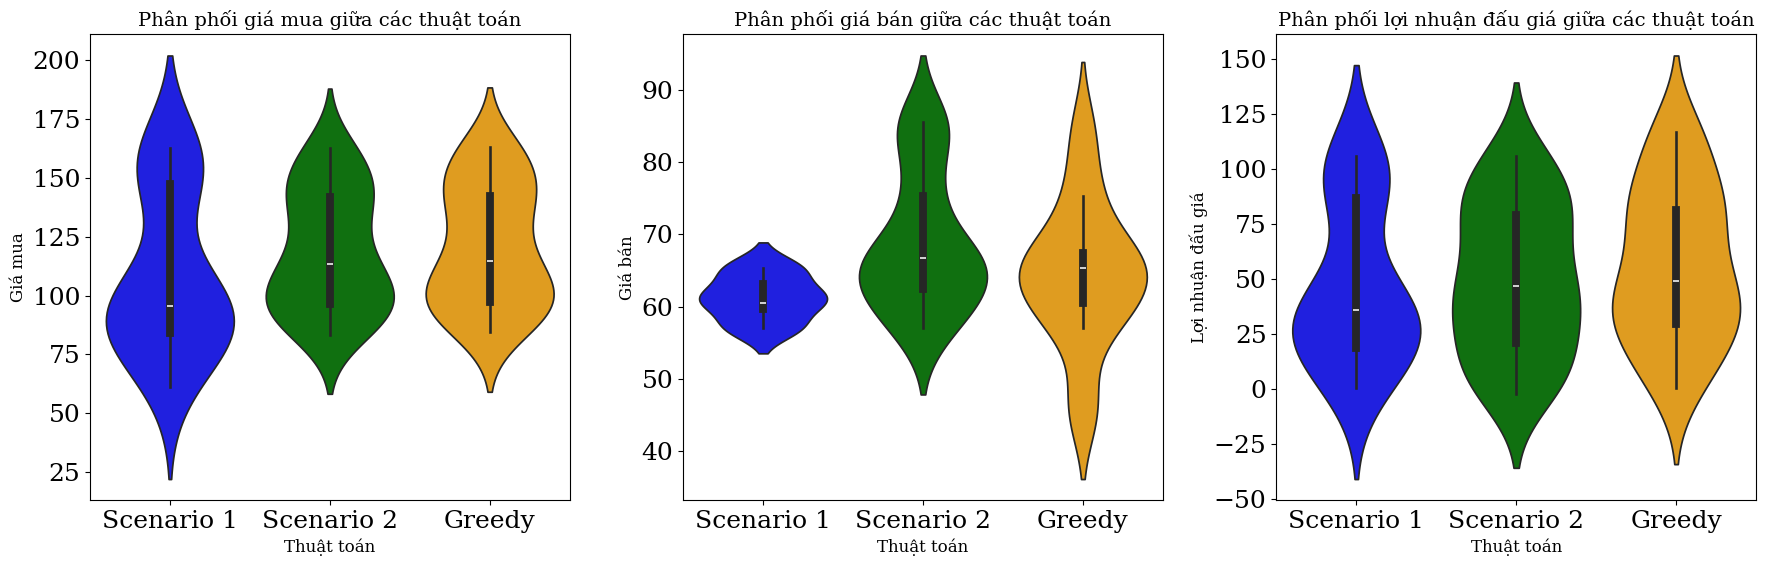

Violinplot so sánh đã được lưu dưới dạng 'violinplot_comparison.png'

Thống kê mô tả chi tiết:
Statistic Payment Scenario 1 Payment Scenario 2 Payment Greedy Selling Scenario 1 Selling Scenario 2 Selling Greedy Profit Scenario 1 Profit Scenario 2 Profit Greedy
     Mean             108.93             118.67         120.94              61.24              68.92          64.44             47.69             49.74         56.51
   Median              95.54             113.39         114.72              60.55              66.69          65.35             35.78             46.69         49.37
      Min              61.20              83.39          84.55              57.10              57.10          45.93              0.66             -2.12          0.46
      Max             162.91             162.91         163.10              65.35              85.52          84.09            105.81            105.81        117.17
  Std Dev              32.99              25.17          25.48             

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict

def visualize_boxplot_comparison(results):
    """
    Tạo boxplot để so sánh lợi nhuận đấu giá, giá mua, giá bán giữa các thuật toán

    Args:
        results: Kết quả từ hàm run_three_way_comparison chứa dữ liệu của cả ba thuật toán
    """
    # Tạo dữ liệu cho boxplot

    # 1. Giá mua (payment prices)
    payment_data = {
        'Scenario 1': list(results['payment_prices1'].values()),
        'Scenario 2': list(results['payment_prices2'].values()),
        'Greedy': list(results['payment_prices_greedy'].values())
    }

    # 2. Giá bán (selling prices)
    selling_data = {
        'Scenario 1': list(results['selling_prices1'].values()),
        'Scenario 2': list(results['selling_prices2'].values()),
        'Greedy': list(results['selling_prices_greedy'].values())
    }

    # 3. Lợi nhuận đấu giá (auctioneer profit) cho từng giao dịch
    # Tính lợi nhuận cho từng cặp giao dịch
    profit1 = []
    for key in results['payment_prices1']:
        if key in results['matching1']:
            gaisp_key = results['matching1'][key]
            payment = results['payment_prices1'][key]
            selling = results['selling_prices1'][gaisp_key]
            profit1.append(payment - selling)

    profit2 = []
    for key in results['payment_prices2']:
        if key in results['matching2']:
            gaisp_key = results['matching2'][key]
            payment = results['payment_prices2'][key]
            selling = results['selling_prices2'][gaisp_key]
            profit2.append(payment - selling)

    profit_greedy = []
    for key in results['payment_prices_greedy']:
        if key in results['matching_greedy']:
            gaisp_key = results['matching_greedy'][key]
            payment = results['payment_prices_greedy'][key]
            selling = results['selling_prices_greedy'][gaisp_key]
            profit_greedy.append(payment - selling)

    profit_data = {
        'Scenario 1': profit1,
        'Scenario 2': profit2,
        'Greedy': profit_greedy
    }

    # Tạo figure với 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Định nghĩa màu sắc cho từng thuật toán
    colors = ['blue', 'green', 'orange']

    # 1. Boxplot cho giá mua
    payment_df = pd.DataFrame({
        'Algorithm': [algo for algo in payment_data for _ in payment_data[algo]],
        'Payment Price': [price for algo in payment_data for price in payment_data[algo]]
    })

    sns.boxplot(x='Algorithm', y='Payment Price', data=payment_df, palette=colors, ax=axes[0])
    axes[0].set_title('So sánh giá mua giữa các thuật toán', fontsize=14)
    axes[0].set_ylabel('Giá mua', fontsize=12)
    axes[0].set_xlabel('Thuật toán', fontsize=12)

    # 2. Boxplot cho giá bán
    selling_df = pd.DataFrame({
        'Algorithm': [algo for algo in selling_data for _ in selling_data[algo]],
        'Selling Price': [price for algo in selling_data for price in selling_data[algo]]
    })

    sns.boxplot(x='Algorithm', y='Selling Price', data=selling_df, palette=colors, ax=axes[1])
    axes[1].set_title('So sánh giá bán giữa các thuật toán', fontsize=14)
    axes[1].set_ylabel('Giá bán', fontsize=12)
    axes[1].set_xlabel('Thuật toán', fontsize=12)

    # 3. Boxplot cho lợi nhuận đấu giá
    profit_df = pd.DataFrame({
        'Algorithm': [algo for algo in profit_data for _ in profit_data[algo]],
        'Auctioneer Profit': [profit for algo in profit_data for profit in profit_data[algo]]
    })

    sns.boxplot(x='Algorithm', y='Auctioneer Profit', data=profit_df, palette=colors, ax=axes[2])
    axes[2].set_title('So sánh lợi nhuận đấu giá giữa các thuật toán', fontsize=14)
    axes[2].set_ylabel('Lợi nhuận đấu giá', fontsize=12)
    axes[2].set_xlabel('Thuật toán', fontsize=12)

    # Thêm thông tin thống kê
    for idx, (data_name, data) in enumerate([('Payment', payment_data), ('Selling', selling_data), ('Profit', profit_data)]):
        for i, algo in enumerate(['Scenario 1', 'Scenario 2', 'Greedy']):
            if len(data[algo]) > 0:
                mean_val = np.mean(data[algo])
                median_val = np.median(data[algo])
                axes[idx].annotate(f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}',
                                 xy=(i, np.min(data[algo])),
                                 xytext=(0, -50),
                                 textcoords='offset points',
                                 ha='center', va='top',
                                 fontsize=9)

    plt.tight_layout()
    plt.savefig('boxplot_comparison.png', dpi=300)
    plt.show()
    print("Boxplot so sánh đã được lưu dưới dạng 'boxplot_comparison.png'")

    # Tạo thêm một biểu đồ violinplot để hiển thị phân phối chi tiết hơn
    plt.figure(figsize=(16, 8))

    # Tạo subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Violinplot cho giá mua
    sns.violinplot(x='Algorithm', y='Payment Price', data=payment_df, palette=colors, ax=axes[0], inner='box')
    axes[0].set_title('Phân phối giá mua giữa các thuật toán', fontsize=14)
    axes[0].set_ylabel('Giá mua', fontsize=12)
    axes[0].set_xlabel('Thuật toán', fontsize=12)

    # 2. Violinplot cho giá bán
    sns.violinplot(x='Algorithm', y='Selling Price', data=selling_df, palette=colors, ax=axes[1], inner='box')
    axes[1].set_title('Phân phối giá bán giữa các thuật toán', fontsize=14)
    axes[1].set_ylabel('Giá bán', fontsize=12)
    axes[1].set_xlabel('Thuật toán', fontsize=12)

    # 3. Violinplot cho lợi nhuận đấu giá
    sns.violinplot(x='Algorithm', y='Auctioneer Profit', data=profit_df, palette=colors, ax=axes[2], inner='box')
    axes[2].set_title('Phân phối lợi nhuận đấu giá giữa các thuật toán', fontsize=14)
    axes[2].set_ylabel('Lợi nhuận đấu giá', fontsize=12)
    axes[2].set_xlabel('Thuật toán', fontsize=12)

    plt.tight_layout()
    plt.savefig('violinplot_comparison.png', dpi=300)
    plt.show()
    print("Violinplot so sánh đã được lưu dưới dạng 'violinplot_comparison.png'")

    # Tạo bảng thống kê mô tả
    summary_stats = pd.DataFrame({
        'Statistic': ['Mean', 'Median', 'Min', 'Max', 'Std Dev', 'Count']
    })

    for data_name, data_dict in [('Payment', payment_data), ('Selling', selling_data), ('Profit', profit_data)]:
        for algo in ['Scenario 1', 'Scenario 2', 'Greedy']:
            if len(data_dict[algo]) > 0:
                stats = [
                    np.mean(data_dict[algo]),
                    np.median(data_dict[algo]),
                    np.min(data_dict[algo]),
                    np.max(data_dict[algo]),
                    np.std(data_dict[algo]),
                    len(data_dict[algo])
                ]
                summary_stats[f'{data_name} {algo}'] = [f'{s:.2f}' if i < 5 else f'{int(s)}' for i, s in enumerate(stats)]

    print("\nThống kê mô tả chi tiết:")
    print(summary_stats.to_string(index=False))

    return {
        'payment_stats': {algo: {'mean': np.mean(payment_data[algo]), 'median': np.median(payment_data[algo])}
                         for algo in payment_data if len(payment_data[algo]) > 0},
        'selling_stats': {algo: {'mean': np.mean(selling_data[algo]), 'median': np.median(selling_data[algo])}
                         for algo in selling_data if len(selling_data[algo]) > 0},
        'profit_stats': {algo: {'mean': np.mean(profit_data[algo]), 'median': np.median(profit_data[algo])}
                        for algo in profit_data if len(profit_data[algo]) > 0}
    }

# Để sử dụng hàm này, thêm đoạn mã sau vào hàm main:
if __name__ == "__main__":
    np.random.seed(42)  # Để đảm bảo tính tái tạo
    results = run_three_way_comparison(num_users=70, num_gaisps=60)
    # visualize_three_way_comparison(results)
    visualize_boxplot_comparison(results)  # Thêm dòng này

Đang tạo bộ dữ liệu với 70 người dùng và 60 GAISP...
Tổng số nhiệm vụ: 140
Tổng công suất GAISP: 240

Đang chạy Scenario 1 (Tất cả nhiệm vụ của mỗi người dùng phải được ghép nối)...
Scenario 1 hoàn thành trong 0.00 giây

Đang chạy Scenario 2 (Nhiệm vụ có thể được ghép nối một phần)...
Scenario 2 hoàn thành trong 0.00 giây

Đang chạy thuật toán Greedy...
Thuật toán Greedy hoàn thành trong 0.00 giây

Đang tính toán các chỉ số hiệu suất...

===== KẾT QUẢ SO SÁNH =====
Chỉ số                         Scenario 1      Scenario 2      Greedy         
---------------------------------------------------------------------------
num_matched_tasks              16.00           35.00           35.00          
num_matched_users              8.00            29.00           29.00          
num_users_all_tasks_matched    8.00            6.00            6.00           
total_payment                  1742.88         4153.36         4233.06        
total_revenue                  979.81          2412.28     

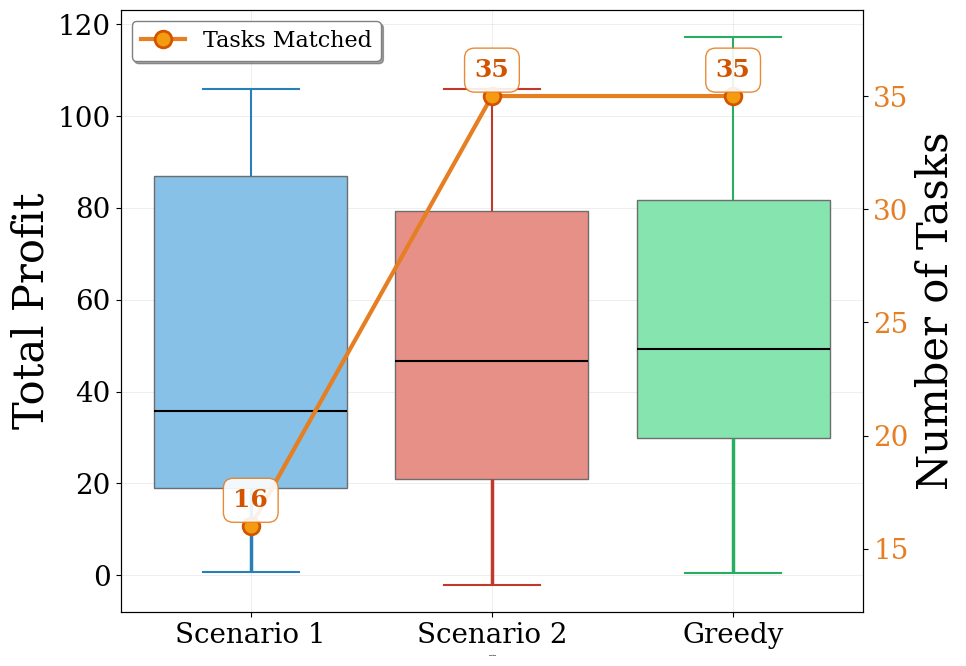

Auctioneer profit boxplot has been saved as 'auctioneer_profit_boxplot.png'

Descriptive Statistics for Auctioneer Profit:
 Algorithm  Mean  Median   Min    Max  Std Dev  Count  Tasks Matched
Scenario 1 47.69   35.78  0.66 105.81    35.03     16             16
Scenario 2 49.74   46.69 -2.12 105.81    33.77     35             35
    Greedy 56.51   49.37  0.46 117.17    34.69     35             35


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict

def visualize_boxplot_comparison(results):
    """
    Tạo boxplot để so sánh lợi nhuận đấu giá, giá mua, giá bán giữa các thuật toán
    và hiển thị số lượng nhiệm vụ được ghép đôi (tasks_matched)

    Args:
        results: Kết quả từ hàm run_three_way_comparison chứa dữ liệu của cả ba thuật toán
    """
    # Tạo dữ liệu cho boxplot

    # 1. Giá mua (payment prices)
    payment_data = {
        'Scenario 1': list(results['payment_prices1'].values()),
        'Scenario 2': list(results['payment_prices2'].values()),
        'Greedy': list(results['payment_prices_greedy'].values())
    }

    # 2. Giá bán (selling prices)
    selling_data = {
        'Scenario 1': list(results['selling_prices1'].values()),
        'Scenario 2': list(results['selling_prices2'].values()),
        'Greedy': list(results['selling_prices_greedy'].values())
    }

    # 3. Lợi nhuận đấu giá (auctioneer profit) cho từng giao dịch
    # Tính lợi nhuận cho từng cặp giao dịch
    profit1 = []
    for key in results['payment_prices1']:
        if key in results['matching1']:
            gaisp_key = results['matching1'][key]
            payment = results['payment_prices1'][key]
            selling = results['selling_prices1'][gaisp_key]
            profit1.append(payment - selling)

    profit2 = []
    for key in results['payment_prices2']:
        if key in results['matching2']:
            gaisp_key = results['matching2'][key]
            payment = results['payment_prices2'][key]
            selling = results['selling_prices2'][gaisp_key]
            profit2.append(payment - selling)

    profit_greedy = []
    for key in results['payment_prices_greedy']:
        if key in results['matching_greedy']:
            gaisp_key = results['matching_greedy'][key]
            payment = results['payment_prices_greedy'][key]
            selling = results['selling_prices_greedy'][gaisp_key]
            profit_greedy.append(payment - selling)

    profit_data = {
        'Scenario 1': profit1,
        'Scenario 2': profit2,
        'Greedy': profit_greedy
    }

    # Tính số lượng nhiệm vụ được ghép đôi (tasks_matched)
    tasks_matched = {
        'Scenario 1': len(results['matching1']),
        'Scenario 2': len(results['matching2']),
        'Greedy': len(results['matching_greedy'])
    }

    # Tạo figure với 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Định nghĩa màu sắc cho từng thuật toán
    colors = ['blue', 'green', 'orange']

    # 1. Boxplot cho giá mua
    payment_df = pd.DataFrame({
        'Algorithm': [algo for algo in payment_data for _ in payment_data[algo]],
        'Payment Price': [price for algo in payment_data for price in payment_data[algo]]
    })

    sns.boxplot(x='Algorithm', y='Payment Price', data=payment_df, palette=colors, ax=axes[0])
    axes[0].set_title('So sánh giá mua giữa các thuật toán', fontsize=14)
    axes[0].set_ylabel('Giá mua', fontsize=12)
    axes[0].set_xlabel('Thuật toán', fontsize=12)

    # 2. Boxplot cho giá bán
    selling_df = pd.DataFrame({
        'Algorithm': [algo for algo in selling_data for _ in selling_data[algo]],
        'Selling Price': [price for algo in selling_data for price in selling_data[algo]]
    })

    sns.boxplot(x='Algorithm', y='Selling Price', data=selling_df, palette=colors, ax=axes[1])
    axes[1].set_title('So sánh giá bán giữa các thuật toán', fontsize=14)
    axes[1].set_ylabel('Giá bán', fontsize=12)
    axes[1].set_xlabel('Thuật toán', fontsize=12)

    # 3. Boxplot cho lợi nhuận đấu giá với trục y phụ cho tasks_matched
    profit_df = pd.DataFrame({
        'Algorithm': [algo for algo in profit_data for _ in profit_data[algo]],
        'Auctioneer Profit': [profit for algo in profit_data for profit in profit_data[algo]]
    })

    # Định nghĩa màu sắc
    beautiful_colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green
    edge_colors = ['#2980b9', '#c0392b', '#27ae60']      # Darker versions for borders

    # Tạo boxplot cho lợi nhuận
    box_plot = sns.boxplot(x='Algorithm', y='Auctioneer Profit', data=profit_df,
                        palette=beautiful_colors, ax=axes[2])

    # Tùy chỉnh màu border cho từng box
    for i, (patch, edge_color) in enumerate(zip(box_plot.artists, edge_colors)):
        # Tùy chỉnh box (hình chữ nhật chính)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2)
        patch.set_alpha(0.8)  # Độ trong suốt

    # Tùy chỉnh màu cho các đường median, whiskers, caps, và outliers
    for i, color in enumerate(edge_colors):
        # Median lines
        axes[2].lines[i*6].set_color(color)  # median line
        axes[2].lines[i*6].set_linewidth(2.5)

        # Whiskers (đường thẳng từ box ra ngoài)
        axes[2].lines[i*6+1].set_color(color)  # bottom whisker
        axes[2].lines[i*6+2].set_color(color)  # top whisker
        axes[2].lines[i*6+1].set_linewidth(1.5)
        axes[2].lines[i*6+2].set_linewidth(1.5)

        # Caps (đường ngang ở đầu whiskers)
        axes[2].lines[i*6+3].set_color(color)  # bottom cap
        axes[2].lines[i*6+4].set_color(color)  # top cap
        axes[2].lines[i*6+3].set_linewidth(1.5)
        axes[2].lines[i*6+4].set_linewidth(1.5)

    # Tùy chỉnh outliers nếu có
    for i, collection in enumerate(axes[2].collections):
        if hasattr(collection, 'get_offsets') and len(collection.get_offsets()) > 0:
            collection.set_facecolors(beautiful_colors[i % len(beautiful_colors)])
            collection.set_edgecolors(edge_colors[i % len(edge_colors)])
            collection.set_linewidth(1.5)

    axes[2].set_title('So sánh lợi nhuận đấu giá và số lượng tasks_matched', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Lợi nhuận đấu giá', fontsize=12)
    axes[2].set_xlabel('Thuật toán', fontsize=12)

    # Tạo trục y phụ bên phải
    ax2 = axes[2].twinx()

    # Vẽ đường tasks_matched trên trục y phụ
    x_pos = range(len(['Scenario 1', 'Scenario 2', 'Greedy']))
    matched_counts = [tasks_matched['Scenario 1'], tasks_matched['Scenario 2'], tasks_matched['Greedy']]
    ax2.plot(x_pos, matched_counts, color='#e67e22', marker='o', linewidth=3,
            markersize=10, label='Tasks Matched', markerfacecolor='#f39c12',
            markeredgecolor='#d35400', markeredgewidth=2)

    # Thiết lập giới hạn cho trục y phụ
    max_tasks = max(matched_counts)
    min_tasks = min(matched_counts)
    margin = (max_tasks - min_tasks) * 0.2  # Tạo khoảng đệm 20%
    ax2.set_ylim([max(0, min_tasks - margin), max_tasks + margin])

    # Thêm nhãn cho trục y phụ
    ax2.set_ylabel('Số lượng tasks_matched', color='#e67e22', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#e67e22')

    # Thêm giá trị số lượng tasks_matched trên đường
    for i, count in enumerate(matched_counts):
        ax2.annotate(str(count),
                    xy=(i, count),
                    xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    color='#d35400',
                    fontweight='bold',
                    fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor='#e67e22', alpha=0.8))

    # Thêm legend với style
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    legend = ax2.legend(lines + lines2, labels + labels2, loc='upper right',
                    frameon=True, fancybox=True, shadow=True,
                    facecolor='white', edgecolor='gray')

    # Tùy chỉnh grid
    axes[2].grid(True, alpha=0.3, linewidth=0.5)
    axes[2].set_axisbelow(True)

    # Thêm thông tin thống kê và số lượng nhiệm vụ được ghép đôi
    for idx, (data_name, data) in enumerate([('Payment', payment_data), ('Selling', selling_data), ('Profit', profit_data)]):
        for i, algo in enumerate(['Scenario 1', 'Scenario 2', 'Greedy']):
            if len(data[algo]) > 0:
                mean_val = np.mean(data[algo])
                median_val = np.median(data[algo])
                annotation_text = f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}'

                # Thêm thông tin về tasks_matched vào biểu đồ lợi nhuận
                if idx == 2:  # Biểu đồ lợi nhuận
                    annotation_text += f'\nTasks matched: {tasks_matched[algo]}'

                # Tạo annotation box đẹp hơn
                axes[idx].annotate(annotation_text,
                                xy=(i, np.min(data[algo])),
                                xytext=(0, -70),
                                textcoords='offset points',
                                ha='center', va='top',
                                fontsize=9,
                                bbox=dict(boxstyle='round,pad=0.5',
                                        facecolor=beautiful_colors[i],
                                        edgecolor=edge_colors[i],
                                        alpha=0.2))

    plt.tight_layout()
    plt.savefig('boxplot_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Boxplot so sánh đã được lưu dưới dạng 'boxplot_comparison.png'")

    # Tạo thêm một biểu đồ violinplot để hiển thị phân phối chi tiết hơn
    plt.figure(figsize=(16, 8))

    # Tạo subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Violinplot cho giá mua
    sns.violinplot(x='Algorithm', y='Payment Price', data=payment_df, palette=colors, ax=axes[0], inner='box')
    axes[0].set_title('Phân phối giá mua giữa các thuật toán', fontsize=14)
    axes[0].set_ylabel('Giá mua', fontsize=12)
    axes[0].set_xlabel('Thuật toán', fontsize=12)

    # 2. Violinplot cho giá bán
    sns.violinplot(x='Algorithm', y='Selling Price', data=selling_df, palette=colors, ax=axes[1], inner='box')
    axes[1].set_title('Phân phối giá bán giữa các thuật toán', fontsize=14)
    axes[1].set_ylabel('Giá bán', fontsize=12)
    axes[1].set_xlabel('Thuật toán', fontsize=12)

    # 3. Violinplot cho lợi nhuận đấu giá với trục y phụ cho tasks_matched
    sns.violinplot(x='Algorithm', y='Auctioneer Profit', data=profit_df, palette=colors, ax=axes[2], inner='box')
    axes[2].set_title('Phân phối lợi nhuận đấu giá và số lượng tasks_matched', fontsize=14)
    axes[2].set_ylabel('Lợi nhuận đấu giá', fontsize=12)
    axes[2].set_xlabel('Thuật toán', fontsize=12)

    # Tạo trục y phụ bên phải cho violinplot
    ax2_violin = axes[2].twinx()

    # Vẽ đường tasks_matched trên trục y phụ
    x_pos = range(len(['Scenario 1', 'Scenario 2', 'Greedy']))
    matched_counts = [tasks_matched['Scenario 1'], tasks_matched['Scenario 2'], tasks_matched['Greedy']]
    ax2_violin.plot(x_pos, matched_counts, 'r-', marker='o', linewidth=2, markersize=8, label='Tasks Matched')

    # Thiết lập giới hạn cho trục y phụ
    max_tasks = max(matched_counts)
    min_tasks = min(matched_counts)
    margin = (max_tasks - min_tasks) * 0.2  # Tạo khoảng đệm 20%
    ax2_violin.set_ylim([max(0, min_tasks - margin), max_tasks + margin])

    # Thêm nhãn cho trục y phụ
    ax2_violin.set_ylabel('Số lượng tasks_matched', color='red', fontsize=12)
    ax2_violin.tick_params(axis='y', labelcolor='red')

    # Thêm giá trị số lượng tasks_matched trên đường
    for i, count in enumerate(matched_counts):
        ax2_violin.annotate(str(count),
                          xy=(i, count),
                          xytext=(0, 5),
                          textcoords='offset points',
                          ha='center',
                          color='red',
                          fontweight='bold')

    # Thêm legend
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2_violin.get_legend_handles_labels()
    ax2_violin.legend(lines + lines2, labels + labels2, loc='upper right')

    plt.tight_layout()
    plt.savefig('violinplot_comparison.png', dpi=300)
    plt.show()
    print("Violinplot so sánh đã được lưu dưới dạng 'violinplot_comparison.png'")

    # Tạo bảng thống kê mô tả
    summary_stats = pd.DataFrame({
        'Statistic': ['Mean', 'Median', 'Min', 'Max', 'Std Dev', 'Count', 'Tasks Matched']
    })

    for data_name, data_dict in [('Payment', payment_data), ('Selling', selling_data), ('Profit', profit_data)]:
        for algo in ['Scenario 1', 'Scenario 2', 'Greedy']:
            if len(data_dict[algo]) > 0:
                stats = [
                    np.mean(data_dict[algo]),
                    np.median(data_dict[algo]),
                    np.min(data_dict[algo]),
                    np.max(data_dict[algo]),
                    np.std(data_dict[algo]),
                    len(data_dict[algo]),
                    tasks_matched[algo]  # Thêm thông tin tasks_matched vào bảng thống kê
                ]
                summary_stats[f'{data_name} {algo}'] = [f'{s:.2f}' if i < 5 else f'{int(s)}' for i, s in enumerate(stats)]

    print("\nThống kê mô tả chi tiết:")
    print(summary_stats.to_string(index=False))

    # Tạo biểu đồ bar riêng cho tasks_matched
    plt.figure(figsize=(10, 6))
    plt.bar(['Scenario 1', 'Scenario 2', 'Greedy'],
            [tasks_matched['Scenario 1'], tasks_matched['Scenario 2'], tasks_matched['Greedy']],
            color=colors)
    plt.title('Số lượng nhiệm vụ được ghép đôi (Tasks Matched)', fontsize=14)
    plt.ylabel('Số lượng', fontsize=12)
    plt.xlabel('Thuật toán', fontsize=12)

    # Thêm số lượng tasks_matched lên đỉnh của mỗi cột
    for i, count in enumerate([tasks_matched['Scenario 1'], tasks_matched['Scenario 2'], tasks_matched['Greedy']]):
        plt.text(i, count + 0.5, str(count), ha='center', fontsize=12)

    plt.tight_layout()
    plt.savefig('tasks_matched_comparison.png', dpi=300)
    plt.show()
    print("Biểu đồ so sánh số lượng nhiệm vụ được ghép đôi đã được lưu dưới dạng 'tasks_matched_comparison.png'")

    return {
        'payment_stats': {algo: {'mean': np.mean(payment_data[algo]), 'median': np.median(payment_data[algo])}
                         for algo in payment_data if len(payment_data[algo]) > 0},
        'selling_stats': {algo: {'mean': np.mean(selling_data[algo]), 'median': np.median(selling_data[algo])}
                         for algo in selling_data if len(selling_data[algo]) > 0},
        'profit_stats': {algo: {'mean': np.mean(profit_data[algo]), 'median': np.median(profit_data[algo])}
                        for algo in profit_data if len(profit_data[algo]) > 0},
        'tasks_matched': tasks_matched  # Trả về thông tin tasks_matched trong kết quả
    }


def visualize_boxplot_comparison(results):
    """
    Tạo boxplot để so sánh lợi nhuận đấu giá giữa các thuật toán
    và hiển thị số lượng nhiệm vụ được ghép đôi (tasks_matched)

    Args:
        results: Kết quả từ hàm run_three_way_comparison chứa dữ liệu của cả ba thuật toán
    """

    # Tính lợi nhuận đấu giá (auctioneer profit) cho từng giao dịch
    profit1 = []
    for key in results['payment_prices1']:
        if key in results['matching1']:
            gaisp_key = results['matching1'][key]
            payment = results['payment_prices1'][key]
            selling = results['selling_prices1'][gaisp_key]
            profit1.append(payment - selling)

    profit2 = []
    for key in results['payment_prices2']:
        if key in results['matching2']:
            gaisp_key = results['matching2'][key]
            payment = results['payment_prices2'][key]
            selling = results['selling_prices2'][gaisp_key]
            profit2.append(payment - selling)

    profit_greedy = []
    for key in results['payment_prices_greedy']:
        if key in results['matching_greedy']:
            gaisp_key = results['matching_greedy'][key]
            payment = results['payment_prices_greedy'][key]
            selling = results['selling_prices_greedy'][gaisp_key]
            profit_greedy.append(payment - selling)

    profit_data = {
        'Scenario 1': profit1,
        'Scenario 2': profit2,
        'Greedy': profit_greedy
    }

    # Tính số lượng nhiệm vụ được ghép đôi (tasks_matched)
    tasks_matched = {
        'Scenario 1': len(results['matching1']),
        'Scenario 2': len(results['matching2']),
        'Greedy': len(results['matching_greedy'])
    }

    # Tạo figure với 1 subplot duy nhất
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Tạo DataFrame cho boxplot
    profit_df = pd.DataFrame({
        'Algorithm': [algo for algo in profit_data for _ in profit_data[algo]],
        'Auctioneer Profit': [profit for algo in profit_data for profit in profit_data[algo]]
    })

    # Định nghĩa màu sắc đẹp
    beautiful_colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green
    edge_colors = ['#2980b9', '#c0392b', '#27ae60']      # Darker versions for borders

    # Tạo boxplot cho lợi nhuận
    box_plot = sns.boxplot(x='Algorithm', y='Auctioneer Profit', data=profit_df,
                        palette=beautiful_colors, ax=ax)

    # Tùy chỉnh màu border cho từng box
    for i, (patch, edge_color) in enumerate(zip(box_plot.artists, edge_colors)):
        # Tùy chỉnh box (hình chữ nhật chính)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2)
        patch.set_alpha(0.8)  # Độ trong suốt

    # Tùy chỉnh màu cho các đường median, whiskers, caps, và outliers
    for i, color in enumerate(edge_colors):
        # Median lines
        ax.lines[i*6].set_color(color)  # median line
        ax.lines[i*6].set_linewidth(2.5)

        # Whiskers (đường thẳng từ box ra ngoài)
        ax.lines[i*6+1].set_color(color)  # bottom whisker
        ax.lines[i*6+2].set_color(color)  # top whisker
        ax.lines[i*6+1].set_linewidth(1.5)
        ax.lines[i*6+2].set_linewidth(1.5)

        # Caps (đường ngang ở đầu whiskers)
        ax.lines[i*6+3].set_color(color)  # bottom cap
        ax.lines[i*6+4].set_color(color)  # top cap
        ax.lines[i*6+3].set_linewidth(1.5)
        ax.lines[i*6+4].set_linewidth(1.5)

    # Tùy chỉnh outliers nếu có
    for i, collection in enumerate(ax.collections):
        if hasattr(collection, 'get_offsets') and len(collection.get_offsets()) > 0:
            collection.set_facecolors(beautiful_colors[i % len(beautiful_colors)])
            collection.set_edgecolors(edge_colors[i % len(edge_colors)])
            collection.set_linewidth(1.5)

    ax.set_title('So sánh lợi nhuận đấu giá và số lượng tasks_matched', fontsize=16, fontweight='bold')
    ax.set_ylabel('Lợi nhuận đấu giá', fontsize=14)
    ax.set_xlabel('Thuật toán', fontsize=14)

    # Tạo trục y phụ bên phải
    ax2 = ax.twinx()

    # Vẽ đường tasks_matched trên trục y phụ
    x_pos = range(len(['Scenario 1', 'Scenario 2', 'Greedy']))
    matched_counts = [tasks_matched['Scenario 1'], tasks_matched['Scenario 2'], tasks_matched['Greedy']]
    ax2.plot(x_pos, matched_counts, color='#e67e22', marker='o', linewidth=3,
            markersize=12, label='Tasks Matched', markerfacecolor='#f39c12',
            markeredgecolor='#d35400', markeredgewidth=2)

    # Thiết lập giới hạn cho trục y phụ
    max_tasks = max(matched_counts)
    min_tasks = min(matched_counts)
    margin = (max_tasks - min_tasks) * 0.2 if max_tasks != min_tasks else max_tasks * 0.1
    ax2.set_ylim([max(0, min_tasks - margin), max_tasks + margin])

    # Thêm nhãn cho trục y phụ
    ax2.set_ylabel('Số lượng tasks_matched', color='#e67e22', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#e67e22')

    # Thêm giá trị số lượng tasks_matched trên đường
    for i, count in enumerate(matched_counts):
        ax2.annotate(str(count),
                    xy=(i, count),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    color='#d35400',
                    fontweight='bold',
                    fontsize=12,
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                            edgecolor='#e67e22', alpha=0.9))

    # Thêm legend với style
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    legend = ax2.legend(lines + lines2, labels + labels2, loc='upper right',
                    frameon=True, fancybox=True, shadow=True,
                    facecolor='white', edgecolor='gray', fontsize=12)

    # Tùy chỉnh grid
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    # Thêm thông tin thống kê cho từng thuật toán
    for i, algo in enumerate(['Scenario 1', 'Scenario 2', 'Greedy']):
        if len(profit_data[algo]) > 0:
            mean_val = np.mean(profit_data[algo])
            median_val = np.median(profit_data[algo])
            annotation_text = f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nTasks matched: {tasks_matched[algo]}'

            # Tạo annotation box đẹp hơn
            ax.annotate(annotation_text,
                       xy=(i, np.min(profit_data[algo])),
                       xytext=(0, -80),
                       textcoords='offset points',
                       ha='center', va='top',
                       fontsize=10,
                       bbox=dict(boxstyle='round,pad=0.6',
                               facecolor=beautiful_colors[i],
                               edgecolor=edge_colors[i],
                               alpha=0.2))

    plt.tight_layout()
    plt.savefig('auctioneer_profit_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Boxplot lợi nhuận đấu giá đã được lưu dưới dạng 'auctioneer_profit_boxplot.png'")

    # Tạo bảng thống kê mô tả cho lợi nhuận
    summary_stats = pd.DataFrame({
        'Algorithm': ['Scenario 1', 'Scenario 2', 'Greedy'],
        'Mean': [np.mean(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Median': [np.median(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Min': [np.min(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Max': [np.max(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Std Dev': [np.std(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Count': [len(profit_data[algo]) for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Tasks Matched': [tasks_matched[algo] for algo in ['Scenario 1', 'Scenario 2', 'Greedy']]
    })

    # Định dạng số
    for col in ['Mean', 'Median', 'Min', 'Max', 'Std Dev']:
        summary_stats[col] = summary_stats[col].round(2)

    print("\nThống kê mô tả lợi nhuận đấu giá:")
    print(summary_stats.to_string(index=False))

    return {
        'profit_stats': {algo: {'mean': np.mean(profit_data[algo]), 'median': np.median(profit_data[algo])}
                        for algo in profit_data if len(profit_data[algo]) > 0},
        'tasks_matched': tasks_matched,
        'summary_table': summary_stats
    }

def visualize_boxplot_comparison(results):
    """
    Create boxplot to compare auctioneer profit between algorithms
    and display the number of matched tasks

    Args:
        results: Results from run_three_way_comparison function containing data from all three algorithms
    """

    # Font size configuration variables
    GENERAL_FONT_SIZE = 18      # General font size for the plot
    LABEL_FONT_SIZE = 30        # Font size for axis labels (x, y labels)
    TICK_LABEL_FONT_SIZE = 20   # Font size for tick labels
    ANNOTATION_FONT_SIZE = 18   # Font size for annotations
    LEGEND_FONT_SIZE = 16       # Font size for legend
    TITLE_FONT_SIZE = 20        # Font size for titles (if needed)

    # Calculate auctioneer profit for each transaction
    profit1 = []
    for key in results['payment_prices1']:
        if key in results['matching1']:
            gaisp_key = results['matching1'][key]
            payment = results['payment_prices1'][key]
            selling = results['selling_prices1'][gaisp_key]
            profit1.append(payment - selling)

    profit2 = []
    for key in results['payment_prices2']:
        if key in results['matching2']:
            gaisp_key = results['matching2'][key]
            payment = results['payment_prices2'][key]
            selling = results['selling_prices2'][gaisp_key]
            profit2.append(payment - selling)

    profit_greedy = []
    for key in results['payment_prices_greedy']:
        if key in results['matching_greedy']:
            gaisp_key = results['matching_greedy'][key]
            payment = results['payment_prices_greedy'][key]
            selling = results['selling_prices_greedy'][gaisp_key]
            profit_greedy.append(payment - selling)

    profit_data = {
        'Scenario 1': profit1,
        'Scenario 2': profit2,
        'Greedy': profit_greedy
    }

    # Calculate number of matched tasks
    tasks_matched = {
        'Scenario 1': len(results['matching1']),
        'Scenario 2': len(results['matching2']),
        'Greedy': len(results['matching_greedy'])
    }

    # Set font configuration using variables
    try:
        plt.rcParams['font.family'] = 'serif'
    except:
        # Fallback fonts if Times New Roman is not available
        plt.rcParams['font.family'] = 'serif'

    plt.rcParams['font.size'] = GENERAL_FONT_SIZE
    # plt.rcParams['font.weight'] = 'bold'


    # Create figure with 1 subplot only
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))

    # Create DataFrame for boxplot
    profit_df = pd.DataFrame({
        'Algorithm': [algo for algo in profit_data for _ in profit_data[algo]],
        'Auctioneer Profit': [profit for algo in profit_data for profit in profit_data[algo]]
    })

    # Define beautiful colors
    # beautiful_colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green
    beautiful_colors = ['#77c4f7', '#f78377', '#76f5ab']  # Blue, Red, Green

    edge_colors = ['#2980b9', '#c0392b', '#27ae60']      # Darker versions for borders

    # Create boxplot for profit
    box_plot = sns.boxplot(x='Algorithm', y='Auctioneer Profit', data=profit_df, palette=beautiful_colors, ax=ax)

    # Customize border colors for each box
    for i, (patch, edge_color) in enumerate(zip(box_plot.artists, edge_colors)):
        # Customize box (main rectangle)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2)
        patch.set_alpha(0.8)  # Transparency

    # Customize colors for median lines, whiskers, caps, and outliers
    for i, color in enumerate(edge_colors):
        # Median lines
        ax.lines[i*6].set_color(color)  # median line
        ax.lines[i*6].set_linewidth(2.5)

        # Whiskers (lines extending from box)
        ax.lines[i*6+1].set_color(color)  # bottom whisker
        ax.lines[i*6+2].set_color(color)  # top whisker
        ax.lines[i*6+1].set_linewidth(1.5)
        ax.lines[i*6+2].set_linewidth(1.5)

        # Caps (horizontal lines at whisker ends)
        ax.lines[i*6+3].set_color(color)  # bottom cap
        ax.lines[i*6+3].set_linewidth(1.5)
        color = 'black'
        ax.lines[i*6+4].set_color(color)  # top cap
        ax.lines[i*6+4].set_linewidth(1.5)

    # Customize outliers if any
    for i, collection in enumerate(ax.collections):
        if hasattr(collection, 'get_offsets') and len(collection.get_offsets()) > 0:
            collection.set_facecolors(beautiful_colors[i % len(beautiful_colors)])
            collection.set_edgecolors(edge_colors[i % len(edge_colors)])
            collection.set_linewidth(1.5)

    # Set axis labels with custom font size
    ax.set_ylabel('Total Profit', fontsize=LABEL_FONT_SIZE)
    ax.set_xlabel('Algorithm', fontsize=0, fontweight='bold')

    # Create secondary y-axis on the right
    ax2 = ax.twinx()

    # Plot tasks_matched line on secondary y-axis
    x_pos = range(len(['Scenario 1', 'Scenario 2', 'Greedy']))
    matched_counts = [tasks_matched['Scenario 1'], tasks_matched['Scenario 2'], tasks_matched['Greedy']]
    ax2.plot(x_pos, matched_counts, color='#e67e22', marker='o', linewidth=3,
            markersize=12, label='Tasks Matched', markerfacecolor='#f39c12',
            markeredgecolor='#d35400', markeredgewidth=2)

    # Set limits for secondary y-axis
    max_tasks = max(matched_counts)
    min_tasks = min(matched_counts)
    margin = (max_tasks - min_tasks) * 0.2 if max_tasks != min_tasks else max_tasks * 0.1
    ax2.set_ylim([max(0, min_tasks - margin), max_tasks + margin])

    # Add label for secondary y-axis with custom font size
    ax2.set_ylabel('Number of Tasks',
                   fontsize=LABEL_FONT_SIZE)
    ax2.tick_params(axis='y', labelcolor='#e67e22')

    # Add task count values on the line with custom font size
    for i, count in enumerate(matched_counts):
        ax2.annotate(str(count),
                    xy=(i, count),
                    xytext=(0, 10),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    color='#d35400',
                    fontweight='bold',
                    fontsize=ANNOTATION_FONT_SIZE,
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                            edgecolor='#e67e22', alpha=0.9))

    # Add legend with custom font size
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    legend = ax2.legend(lines + lines2, labels + labels2, loc='best',
                    frameon=True, fancybox=True, shadow=True,
                    facecolor='white', edgecolor='gray', fontsize=LEGEND_FONT_SIZE)

    # Customize grid
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    # Set font for tick labels with custom font size
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONT_SIZE)
    ax2.tick_params(axis='y', labelcolor='#e67e22', labelsize=TICK_LABEL_FONT_SIZE)

    plt.tight_layout()
    plt.savefig('auctioneer_profit_boxplot.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print("Auctioneer profit boxplot has been saved as 'auctioneer_profit_boxplot.png'")

    # Create descriptive statistics table for profit
    summary_stats = pd.DataFrame({
        'Algorithm': ['Scenario 1', 'Scenario 2', 'Greedy'],
        'Mean': [np.mean(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Median': [np.median(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Min': [np.min(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Max': [np.max(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Std Dev': [np.std(profit_data[algo]) if len(profit_data[algo]) > 0 else 0 for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Count': [len(profit_data[algo]) for algo in ['Scenario 1', 'Scenario 2', 'Greedy']],
        'Tasks Matched': [tasks_matched[algo] for algo in ['Scenario 1', 'Scenario 2', 'Greedy']]
    })

    # Format numbers
    for col in ['Mean', 'Median', 'Min', 'Max', 'Std Dev']:
        summary_stats[col] = summary_stats[col].round(2)

    print("\nDescriptive Statistics for Auctioneer Profit:")
    print(summary_stats.to_string(index=False))

    return {
        'profit_stats': {algo: {'mean': np.mean(profit_data[algo]), 'median': np.median(profit_data[algo])}
                        for algo in profit_data if len(profit_data[algo]) > 0},
        'tasks_matched': tasks_matched,
        'summary_table': summary_stats
    }

if __name__ == "__main__":
    np.random.seed(42)  # Để đảm bảo tính tái tạo
    results = run_three_way_comparison(num_users=70, num_gaisps=60)
    # visualize_three_way_comparison(results)
    visualize_boxplot_comparison(results)  # Thêm dòng này

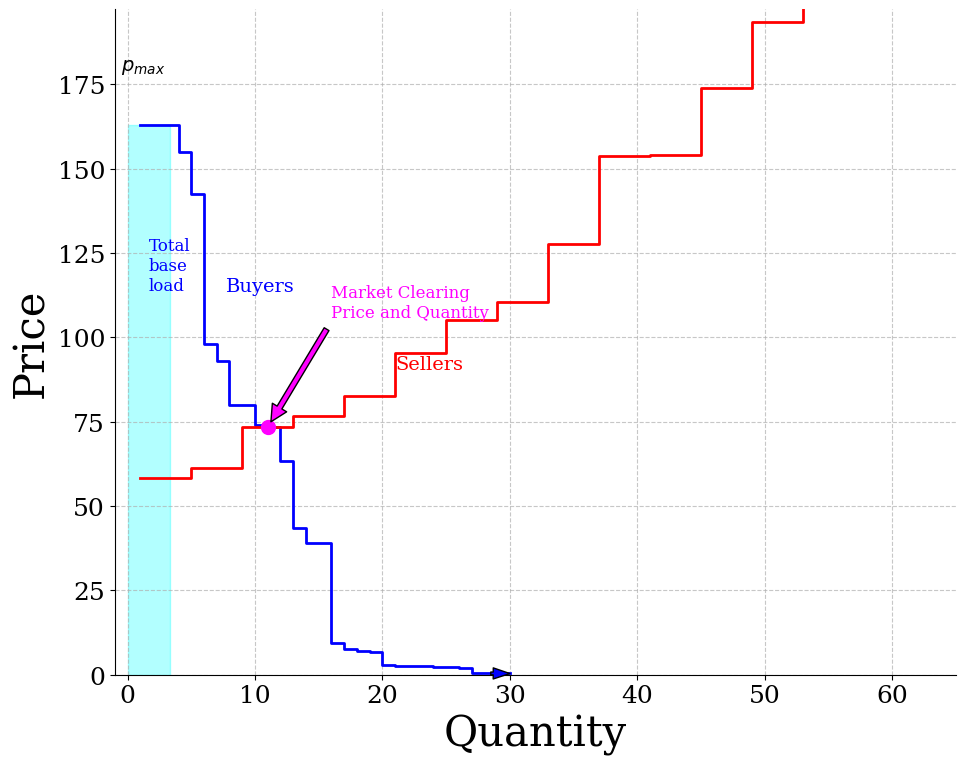

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple

def visualize_double_auction(users: List, gaisps: List, base_params: Dict, save_path: str = None):
    """
    Generate a visualization of the double auction mechanism for Scenario 2.

    Args:
        users: List of User objects
        gaisps: List of GAISP objects
        base_params: Dictionary containing base parameters
        save_path: Optional path to save the figure
    """
    # Compute bids for all users
    all_bids = []
    for user in users:
        user.compute_bids(base_params)
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    # Compute asks for all GAISPs
    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Sort bids in descending order
    B = sorted(all_bids, key=lambda x: x[2], reverse=True)

    # Sort asks in ascending order
    S = sorted(all_asks, key=lambda x: x[2])

    # Create x and y coordinates for step function
    bid_x = list(range(1, len(B) + 1))
    bid_y = [bid[2] for bid in B]

    ask_x = list(range(1, len(S) + 1))
    ask_y = [ask[2] for ask in S]

    # Identify the breakeven index (market clearing point)
    k = 0
    while k < min(len(B), len(S)) and B[k][2] >= S[k][2]:
        k += 1

    # Create the figure
    plt.figure(figsize=(10, 8))

    # Draw step function for bids (buyers)
    plt.step(bid_x, bid_y, where='post', color='blue', linewidth=2, label='Buyers')

    # Draw step function for asks (sellers)
    plt.step(ask_x, ask_y, where='post', color='red', linewidth=2, label='Sellers')

    # Find market clearing point coordinates
    if k > 0:
        clear_x = k
        clear_y = S[k-1][2]  # Use the last matched ask price

        # Mark market clearing point
        plt.plot(clear_x, clear_y, 'o', markersize=10, color='magenta', label='Market Clearing Point')

        # Add text annotation for market clearing
        plt.annotate('Market Clearing\nPrice and Quantity',
                     xy=(clear_x, clear_y),
                     xytext=(clear_x + 5, clear_y + 0.2 * max(bid_y)),
                     arrowprops=dict(facecolor='magenta', shrink=0.05),
                     fontsize=12, color='magenta')

        # Add total base load (blue shaded area)
        x_base = np.linspace(0, clear_x * 0.3, 100)
        y_base = np.ones_like(x_base) * bid_y[0]
        plt.fill_between(x_base, y_base, 0, color='cyan', alpha=0.3)

        # Label for total base load
        plt.annotate('Total\nbase\nload',
                     xy=(clear_x * 0.15, bid_y[0] * 0.7),
                     fontsize=12, color='blue')

    # Add arrows to indicate direction
    if len(bid_x) > 1:
        plt.annotate('', xy=(bid_x[-1], bid_y[-1] * 0.8), xytext=(bid_x[-1] * 0.95, bid_y[-1] * 0.9),
                     arrowprops=dict(facecolor='blue', width=2, headwidth=8))

    if len(ask_x) > 1:
        plt.annotate('', xy=(ask_x[-1] * 0.95, ask_y[-1] * 1.1), xytext=(ask_x[-1] * 0.9, ask_y[-1]),
                     arrowprops=dict(facecolor='red', width=2, headwidth=8))

    # Labels and title
    plt.xlabel('Quantity', fontsize=30)
    plt.ylabel('Price', fontsize=30)
    # plt.title('Double Auction Mechanism for GAI Resource Allocation', fontsize=16)

    # Add p_max label
    p_max = max(bid_y) * 1.1
    plt.text(-0.5, p_max, '$p_{max}$', fontsize=14)

    # Label for buyers and sellers
    plt.text(bid_x[len(bid_x)//3]*0.7, bid_y[len(bid_x)//3] * 1.55, 'Buyers', fontsize=14, color='blue')
    plt.text(ask_x[len(ask_x)//3], ask_y[len(ask_x)//3] * 0.95, 'Sellers', fontsize=14, color='red')

    # Set axis limits
    plt.xlim(-1, max(len(B), len(S)) + 5)
    plt.ylim(0, p_max * 1.1)

    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Grid and legend
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.tight_layout()
    return plt

if __name__ == "__main__":
    # These imports would come from your main script
    # from your_module import User, GAISP, generate_large_dataset

    # Generate test data
    np.random.seed(42)  # For reproducibility
    users, gaisps, base_params = generate_large_dataset(num_users=15, num_gaisps=15)

    # Visualize the double auction
    plt_obj = visualize_double_auction(users, gaisps, base_params, save_path='market_clearing_price_and_quantity.pdf')

    # Show the plot
    plt_obj.show()

Comparing execution times with 70 GAISPs and varying users...

Running with 50 users...
Execution times with 50 users:
- Scenario 1: 0.0015 seconds
- Scenario 2: 0.0005 seconds
- Greedy: 0.0100 seconds

Running with 60 users...
Execution times with 60 users:
- Scenario 1: 0.0007 seconds
- Scenario 2: 0.0005 seconds
- Greedy: 0.0040 seconds

Running with 70 users...
Execution times with 70 users:
- Scenario 1: 0.0009 seconds
- Scenario 2: 0.0005 seconds
- Greedy: 0.0048 seconds

Running with 80 users...
Execution times with 80 users:
- Scenario 1: 0.0009 seconds
- Scenario 2: 0.0006 seconds
- Greedy: 0.0048 seconds

Running with 90 users...
Execution times with 90 users:
- Scenario 1: 0.0011 seconds
- Scenario 2: 0.0007 seconds
- Greedy: 0.0068 seconds

Running with 100 users...
Execution times with 100 users:
- Scenario 1: 0.0011 seconds
- Scenario 2: 0.0007 seconds
- Greedy: 0.0076 seconds


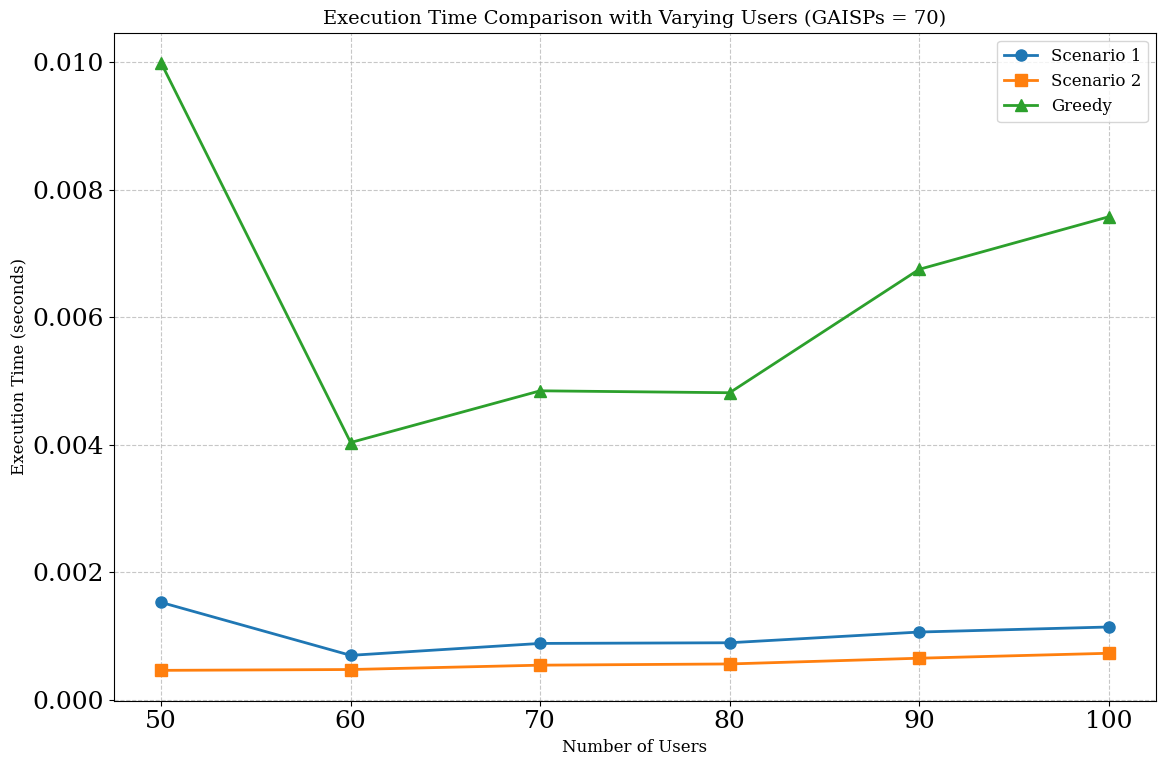

Chart saved as 'execution_time_comparison_users.png'
===== EXECUTION TIME COMPARISON (SECONDS) =====

+-------+-----------------------+------------------------+----------------------+
| Users |    Scenario 1 (s)     |     Scenario 2 (s)     |      Greedy (s)      |
+-------+-----------------------+------------------------+----------------------+
| 50.0  | 0.0015270709991455078 | 0.0004608631134033203  | 0.009991168975830078 |
| 60.0  | 0.0006961822509765625 | 0.00047397613525390625 | 0.004035472869873047 |
| 70.0  | 0.0008833408355712891 | 0.0005421638488769531  | 0.004847049713134766 |
| 80.0  | 0.0008938312530517578 | 0.0005612373352050781  | 0.004816770553588867 |
| 90.0  | 0.0010619163513183594 | 0.0006513595581054688  | 0.006752729415893555 |
| 100.0 | 0.0011410713195800781 | 0.0007288455963134766  | 0.007577180862426758 |
+-------+-----------------------+------------------------+----------------------+

===== SUMMARY STATISTICS =====

+----------------+-----------------------+---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from tabulate import tabulate
from typing import List, Dict, Tuple

def compare_execution_times_with_varying_users(fixed_gaisps=70, user_range=[50, 60, 70, 80, 90, 100]):
    """
    Compare the execution times of all three algorithms with a fixed number of GAISPs
    and varying number of users.

    Args:
        fixed_gaisps: Number of GAISPs to use for all runs
        user_range: List of user counts to test

    Returns:
        Dictionary containing execution time data and summary statistics
    """
    # Storage for results
    scenario1_times = []
    scenario2_times = []
    greedy_times = []

    print(f"Comparing execution times with {fixed_gaisps} GAISPs and varying users...")

    # Run comparison for each user count
    for num_users in user_range:
        print(f"\nRunning with {num_users} users...")
        # Set seed for reproducibility
        np.random.seed(42)

        # Generate dataset once for all algorithms
        users, gaisps, base_params = generate_large_dataset(num_users=num_users, num_gaisps=fixed_gaisps)

        # Measure execution time for Scenario 1
        start_time = time.time()
        matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
        end_time = time.time()
        scenario1_time = end_time - start_time
        scenario1_times.append(scenario1_time)

        # Measure execution time for Scenario 2
        start_time = time.time()
        matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
        end_time = time.time()
        scenario2_time = end_time - start_time
        scenario2_times.append(scenario2_time)

        # Measure execution time for Greedy
        start_time = time.time()
        matching_greedy, payment_prices_greedy, selling_prices_greedy = greedy_auction(users, gaisps, base_params)
        end_time = time.time()
        greedy_time = end_time - start_time
        greedy_times.append(greedy_time)

        # Print results
        print(f"Execution times with {num_users} users:")
        print(f"- Scenario 1: {scenario1_time:.4f} seconds")
        print(f"- Scenario 2: {scenario2_time:.4f} seconds")
        print(f"- Greedy: {greedy_time:.4f} seconds")

    # Create DataFrame for easy display and analysis
    results_df = pd.DataFrame({
        'Users': user_range,
        'Scenario 1 (s)': scenario1_times,
        'Scenario 2 (s)': scenario2_times,
        'Greedy (s)': greedy_times
    })

    # Calculate summary statistics
    mean_times = results_df[['Scenario 1 (s)', 'Scenario 2 (s)', 'Greedy (s)']].mean()
    median_times = results_df[['Scenario 1 (s)', 'Scenario 2 (s)', 'Greedy (s)']].median()
    std_times = results_df[['Scenario 1 (s)', 'Scenario 2 (s)', 'Greedy (s)']].std()

    # Create summary DataFrame
    summary_df = pd.DataFrame({
        'Mean (s)': mean_times,
        'Median (s)': median_times,
        'Std Dev (s)': std_times
    })

    # Plot line chart
    plt.figure(figsize=(12, 8))
    plt.plot(user_range, scenario1_times, 'o-', label='Scenario 1', linewidth=2, markersize=8)
    plt.plot(user_range, scenario2_times, 's-', label='Scenario 2', linewidth=2, markersize=8)
    plt.plot(user_range, greedy_times, '^-', label='Greedy', linewidth=2, markersize=8)

    plt.title('Execution Time Comparison with Varying Users (GAISPs = 70)', fontsize=14)
    plt.xlabel('Number of Users', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(user_range)
    plt.tight_layout()

    # Save and display chart
    plt.savefig('execution_time_comparison_users.png')
    plt.show()
    print("Chart saved as 'execution_time_comparison_users.png'")

    # Return data for further analysis
    return {
        'results_df': results_df,
        'summary_df': summary_df,
        'user_range': user_range,
        'scenario1_times': scenario1_times,
        'scenario2_times': scenario2_times,
        'greedy_times': greedy_times
    }

def create_execution_time_table(results):
    """
    Creates and displays a formatted table comparing execution times.

    Args:
        results: Dictionary containing execution time data

    Returns:
        Formatted table as string
    """
    # Create detailed results table
    results_table = tabulate(
        results['results_df'],
        headers='keys',
        tablefmt='pretty',
        floatfmt='.4f',
        showindex=False
    )

    # Create summary statistics table
    summary_table = tabulate(
        results['summary_df'],
        headers='keys',
        tablefmt='pretty',
        floatfmt='.4f'
    )

    # Calculate speedup relative to the slowest algorithm
    speedup_df = pd.DataFrame(index=results['user_range'])

    for i, users in enumerate(results['user_range']):
        max_time = max(results['scenario1_times'][i],
                       results['scenario2_times'][i],
                       results['greedy_times'][i])

        speedup_df.loc[users, 'Scenario 1 Speedup'] = max_time / results['scenario1_times'][i]
        speedup_df.loc[users, 'Scenario 2 Speedup'] = max_time / results['scenario2_times'][i]
        speedup_df.loc[users, 'Greedy Speedup'] = max_time / results['greedy_times'][i]

    speedup_table = tabulate(
        speedup_df,
        headers='keys',
        tablefmt='pretty',
        floatfmt='.2f',
        showindex=True
    )

    # Combine tables with headers
    full_table = (
        "===== EXECUTION TIME COMPARISON (SECONDS) =====\n\n" +
        results_table +
        "\n\n===== SUMMARY STATISTICS =====\n\n" +
        summary_table +
        "\n\n===== RELATIVE SPEEDUP (HIGHER IS BETTER) =====\n\n" +
        speedup_table
    )

    return full_table

def run_execution_time_analysis():
    """
    Run a complete execution time analysis and display the results
    """
    np.random.seed(42)  # For reproducibility
    user_range = [50, 60, 70, 80, 90, 100]
    fixed_gaisps = 70

    # Run the comparison
    results = compare_execution_times_with_varying_users(
        fixed_gaisps=fixed_gaisps,
        user_range=user_range
    )

    # Create and print the formatted table
    table = create_execution_time_table(results)
    print(table)

    # Create a version of the table suitable for LaTeX (optional)
    latex_table = results['results_df'].to_latex(index=False, float_format="%.4f")
    latex_summary = results['summary_df'].to_latex(float_format="%.4f")

    print("\nLaTeX table for results:")
    print(latex_table)

    print("\nLaTeX table for summary:")
    print(latex_summary)

    return results

# Run the analysis when the script is executed directly
if __name__ == "__main__":
    run_execution_time_analysis()

##Utility

Starting utility analysis with [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245

Processing user counts: 100%|██████████| 760/760 [00:56<00:00, 13.46it/s]


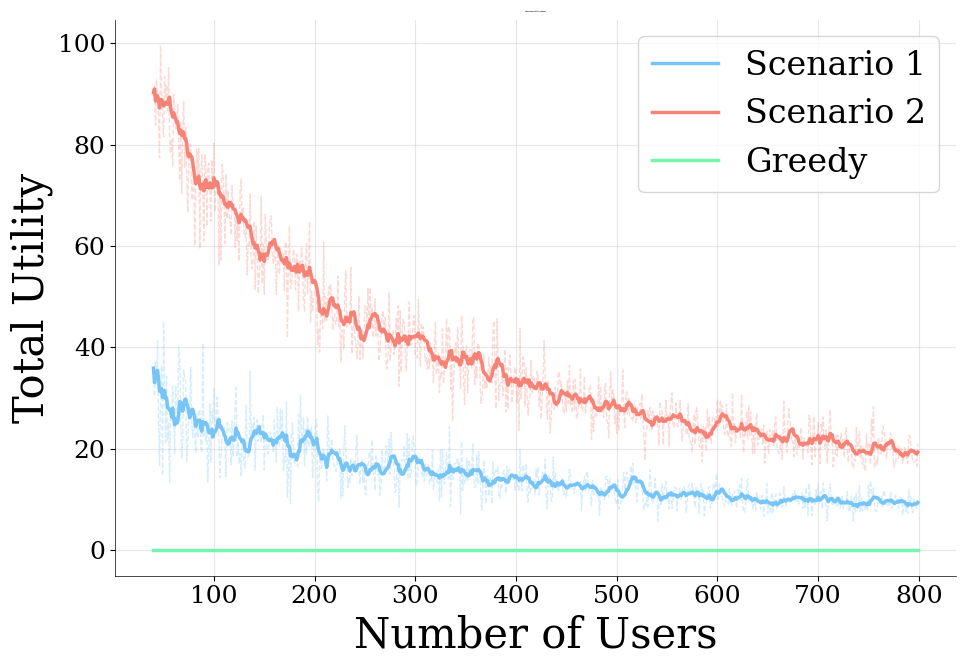

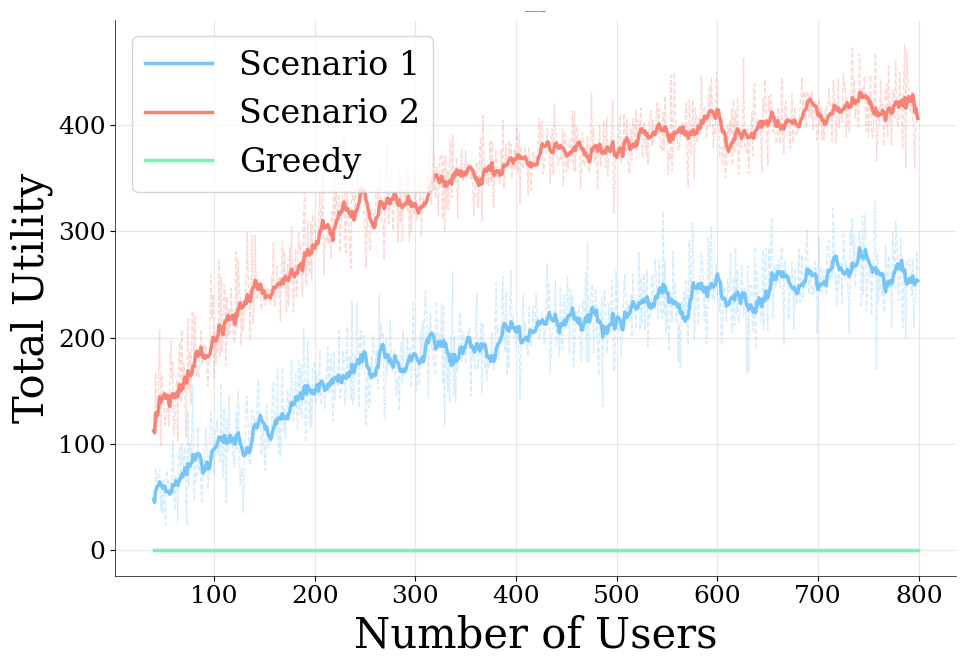

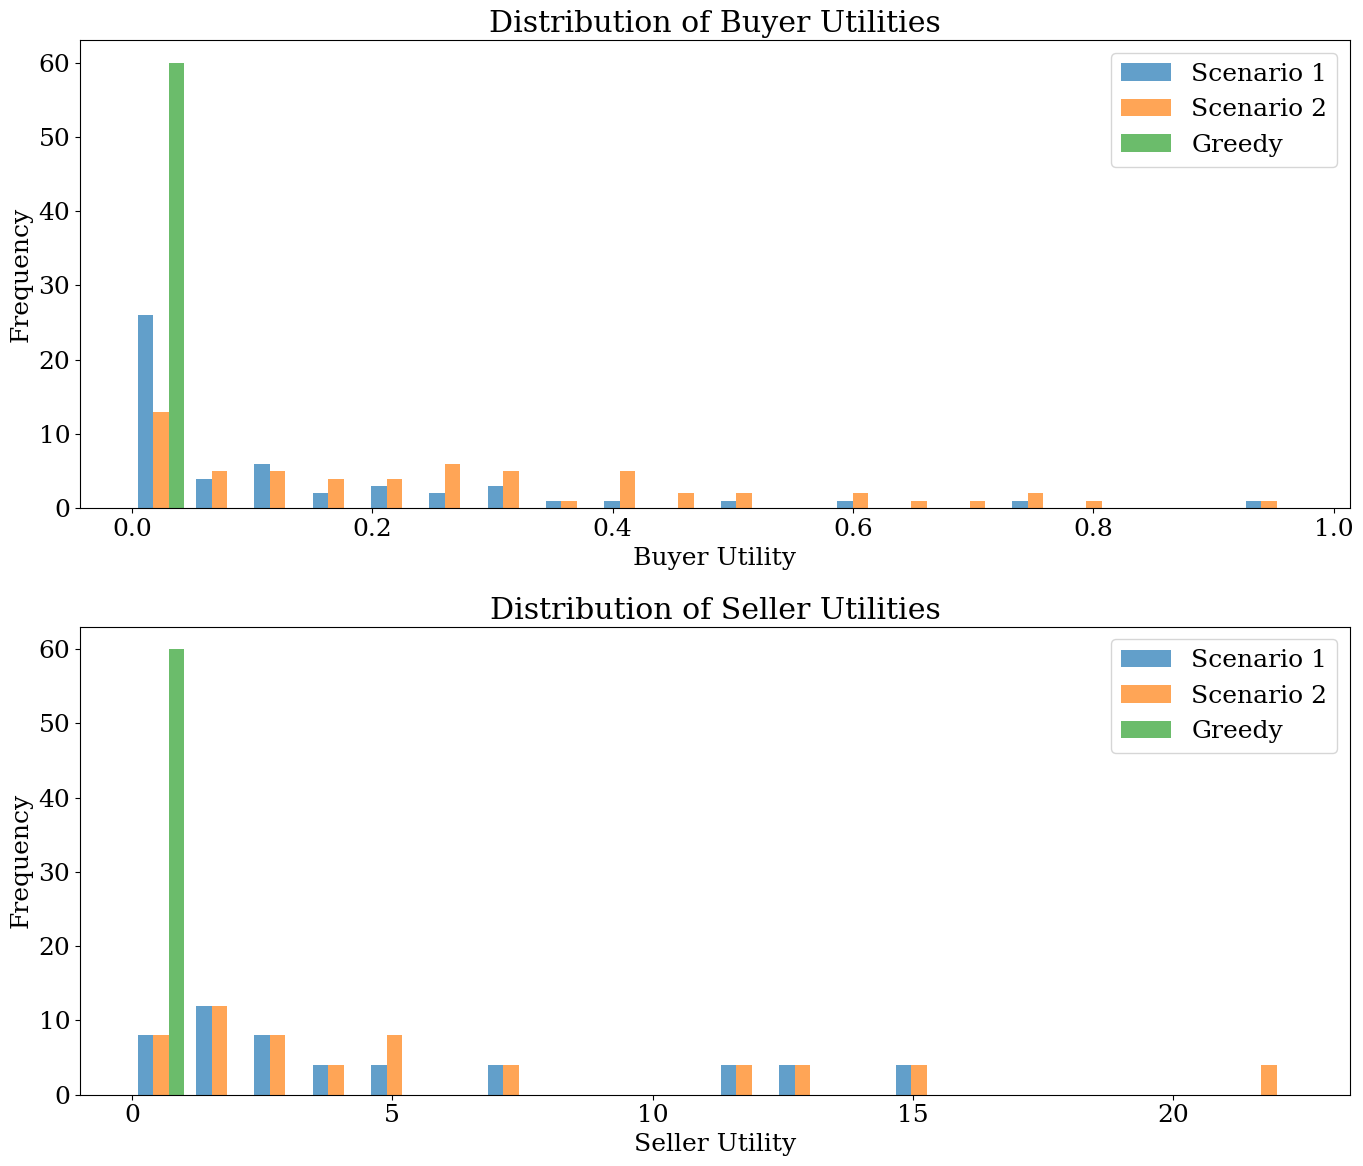

Utility analysis completed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time
from typing import List, Dict, Tuple
import pandas as pd
from tqdm import tqdm

def calculate_utilities(matching, payment_prices, selling_prices, users, gaisps, all_bids, all_asks, auction=True):
    """
    Calculate buyer and seller utilities for matched tasks

    Buyer utility = Buyer bid price - Payment price
    Seller utility = Payment price - Seller ask price
    """
    # Create dictionaries to map task_ids to bids and gaisp_task_ids to asks
    bid_dict = {(u_id, t_id): bid_value for u_id, t_id, bid_value in all_bids}
    ask_dict = {(g_id, gt_id): ask_value for g_id, gt_id, ask_value in all_asks}

    # Initialize utility metrics
    buyer_utilities = []
    seller_utilities = []

    # Calculate utilities for each matched task
    for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching.items():
        # Get bid and payment prices
        bid_price = bid_dict.get((user_id, task_id), 0)
        payment_price = payment_prices.get((user_id, task_id), 0)

        # Get ask and selling prices
        ask_price = ask_dict.get((gaisp_id, gaisp_task_id), 0)
        selling_price = selling_prices.get((gaisp_id, gaisp_task_id), 0)

        # Calculate utilities
        seller_utility = selling_price - ask_price
        if auction:
            buyer_utility = bid_price - payment_price
        else:
            buyer_utility = abs(selling_price - bid_price)

        buyer_utilities.append(buyer_utility)
        seller_utilities.append(seller_utility)

    # Calculate average utilities
    avg_buyer_utility = np.mean(buyer_utilities) if buyer_utilities else 0
    avg_seller_utility = np.mean(seller_utilities) if seller_utilities else 0

    # Calculate total utilities
    total_buyer_utility = sum(buyer_utilities)
    total_seller_utility = sum(seller_utilities)

    return {
        'avg_buyer_utility': avg_buyer_utility,
        'avg_seller_utility': avg_seller_utility,
        'total_buyer_utility': total_buyer_utility,
        'total_seller_utility': total_seller_utility,
        'buyer_utilities': buyer_utilities,
        'seller_utilities': seller_utilities
    }

def analyze_utilities_by_user_count(user_counts, num_gaisps=50, r_denoi_m=50, num_trials=3):
    """
    Analyze how utilities change as the number of users increases

    Parameters:
    - user_counts: List of different user counts to analyze
    - num_gaisps: Number of GAISPs to use
    - r_denoi_m: Maximum denoising steps
    - num_trials: Number of times to run each scenario for statistical significance
    """
    # Initialize results dictionary
    results = {
        'scenario1': {count: {'avg_buyer_utility': [], 'avg_seller_utility': [],
                             'total_buyer_utility': [], 'total_seller_utility': []}
                     for count in user_counts},
        'scenario2': {count: {'avg_buyer_utility': [], 'avg_seller_utility': [],
                             'total_buyer_utility': [], 'total_seller_utility': []}
                     for count in user_counts},
        'greedy': {count: {'avg_buyer_utility': [], 'avg_seller_utility': [],
                          'total_buyer_utility': [], 'total_seller_utility': []}
                  for count in user_counts}
    }

    # Run multiple trials for each user count
    for count in tqdm(user_counts, desc="Processing user counts"):
        for trial in range(num_trials):
            # Generate dataset
            users, gaisps, base_params = generate_large_dataset(count, num_gaisps, r_denoi_m)

            # Prepare bid and ask data
            all_bids = []
            for user in users:
                user.compute_bids(base_params)
                for task in user.tasks:
                    all_bids.append((user.user_id, task.task_id, task.bid))

            all_asks = []
            for gaisp in gaisps:
                all_asks.extend(gaisp.compute_asks())

            # Run scenario 1
            matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
            utils1 = calculate_utilities(matching1, payment_prices1, selling_prices1, users, gaisps, all_bids, all_asks)

            # Run scenario 2
            matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
            utils2 = calculate_utilities(matching2, payment_prices2, selling_prices2, users, gaisps, all_bids, all_asks)

            # Run greedy
            matching_greedy, payment_prices_greedy, selling_prices_greedy = greedy_auction(users, gaisps, base_params)
            utils_greedy = calculate_utilities(matching_greedy, payment_prices_greedy, selling_prices_greedy,
                                               users, gaisps, all_bids, all_asks)

            # Store results
            for metric in ['avg_buyer_utility', 'avg_seller_utility', 'total_buyer_utility', 'total_seller_utility']:
                results['scenario1'][count][metric].append(utils1[metric])
                results['scenario2'][count][metric].append(utils2[metric])
                results['greedy'][count][metric].append(utils_greedy[metric])

    # Calculate averages over trials
    avg_results = {
        'scenario1': {count: {metric: np.mean(values) for metric, values in metrics.items()}
                     for count, metrics in results['scenario1'].items()},
        'scenario2': {count: {metric: np.mean(values) for metric, values in metrics.items()}
                     for count, metrics in results['scenario2'].items()},
        'greedy': {count: {metric: np.mean(values) for metric, values in metrics.items()}
                  for count, metrics in results['greedy'].items()}
    }

    return avg_results

def analyze_utilities_by_size(user_counts = [8, 16, 32, 64, 128, 512, 1024, 2048], num_gaisps=50, r_denoi_m=50, num_trials=3):
    """
    Analyze how utilities change as the number of users increases

    Parameters:
    - user_counts: List of different user counts to analyze
    - num_gaisps: Number of GAISPs to use
    - r_denoi_m: Maximum denoising steps
    - num_trials: Number of times to run each scenario for statistical significance
    """
    # Initialize results dictionary
    results = {
        'scenario1': {count: {'avg_buyer_utility': [], 'avg_seller_utility': [],
                             'total_buyer_utility': [], 'total_seller_utility': []}
                     for count in user_counts},
        'scenario2': {count: {'avg_buyer_utility': [], 'avg_seller_utility': [],
                             'total_buyer_utility': [], 'total_seller_utility': []}
                     for count in user_counts},
        'greedy': {count: {'avg_buyer_utility': [], 'avg_seller_utility': [],
                          'total_buyer_utility': [], 'total_seller_utility': []}
                  for count in user_counts}
    }

    num_user = 50
    # Run multiple trials for each user count
    for count in tqdm(user_counts, desc="Processing user counts"):
        for trial in range(num_trials):
            # Generate dataset
            users, gaisps, base_params = generate_large_dataset(num_user, num_gaisps, r_denoi_m, [count])

            # Prepare bid and ask data
            all_bids = []
            for user in users:
                user.compute_bids(base_params)
                for task in user.tasks:
                    all_bids.append((user.user_id, task.task_id, task.bid))

            all_asks = []
            for gaisp in gaisps:
                all_asks.extend(gaisp.compute_asks())

            # Run scenario 1
            matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users, gaisps, base_params)
            utils1 = calculate_utilities(matching1, payment_prices1, selling_prices1, users, gaisps, all_bids, all_asks)

            # Run scenario 2
            matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users, gaisps, base_params)
            utils2 = calculate_utilities(matching2, payment_prices2, selling_prices2, users, gaisps, all_bids, all_asks)

            # Run greedy
            matching_greedy, payment_prices_greedy, selling_prices_greedy = greedy_auction(users, gaisps, base_params)
            utils_greedy = calculate_utilities(matching_greedy, payment_prices_greedy, selling_prices_greedy,
                                               users, gaisps, all_bids, all_asks)

            # Store results
            for metric in ['avg_buyer_utility', 'avg_seller_utility', 'total_buyer_utility', 'total_seller_utility']:
                results['scenario1'][count][metric].append(utils1[metric])
                results['scenario2'][count][metric].append(utils2[metric])
                results['greedy'][count][metric].append(utils_greedy[metric])

    # Calculate averages over trials
    avg_results = {
        'scenario1': {count: {metric: np.mean(values) for metric, values in metrics.items()}
                     for count, metrics in results['scenario1'].items()},
        'scenario2': {count: {metric: np.mean(values) for metric, values in metrics.items()}
                     for count, metrics in results['scenario2'].items()},
        'greedy': {count: {metric: np.mean(values) for metric, values in metrics.items()}
                  for count, metrics in results['greedy'].items()}
    }

    return avg_results


def visualize_utility_analysis_(results, user_counts):
    """
    Create visualizations for utility analysis across different user counts
    with Total Utility on row 0 and Average Utility on row 1
    """
    # Set up figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(18, 14))

    # Extract data for plotting
    s1_avg_buyer = [results['scenario1'][count]['avg_buyer_utility'] for count in user_counts]
    s2_avg_buyer = [results['scenario2'][count]['avg_buyer_utility'] for count in user_counts]
    greedy_avg_buyer = [results['greedy'][count]['avg_buyer_utility'] for count in user_counts]

    s1_avg_seller = [results['scenario1'][count]['avg_seller_utility'] for count in user_counts]
    s2_avg_seller = [results['scenario2'][count]['avg_seller_utility'] for count in user_counts]
    greedy_avg_seller = [results['greedy'][count]['avg_seller_utility'] for count in user_counts]

    s1_total_buyer = [results['scenario1'][count]['total_buyer_utility'] for count in user_counts]
    s2_total_buyer = [results['scenario2'][count]['total_buyer_utility'] for count in user_counts]
    greedy_total_buyer = [results['greedy'][count]['total_buyer_utility'] for count in user_counts]

    s1_total_seller = [results['scenario1'][count]['total_seller_utility'] for count in user_counts]
    s2_total_seller = [results['scenario2'][count]['total_seller_utility'] for count in user_counts]
    greedy_total_seller = [results['greedy'][count]['total_seller_utility'] for count in user_counts]

    # Plot 1: Total Buyer Utility (now in row 0, col 0)
    axs[0, 0].plot(user_counts, s1_total_buyer, 'b-o', label='Scenario 1')
    axs[0, 0].plot(user_counts, s2_total_buyer, 'g-s', label='Scenario 2')
    axs[0, 0].plot(user_counts, greedy_total_buyer, 'r-^', label='Greedy')
    axs[0, 0].set_xlabel('Number of Users')
    axs[0, 0].set_ylabel('Total Buyer Utility')
    axs[0, 0].set_title('Total Buyer Utility vs. Number of Users')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Plot 2: Total Seller Utility (now in row 0, col 1)
    axs[0, 1].plot(user_counts, s1_total_seller, 'b-o', label='Scenario 1')
    axs[0, 1].plot(user_counts, s2_total_seller, 'g-s', label='Scenario 2')
    axs[0, 1].plot(user_counts, greedy_total_seller, 'r-^', label='Greedy')
    axs[0, 1].set_xlabel('Number of Users')
    axs[0, 1].set_ylabel('Total Seller Utility')
    axs[0, 1].set_title('Total Seller Utility vs. Number of Users')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Plot 3: Average Buyer Utility (now in row 1, col 0)
    axs[1, 0].plot(user_counts, s1_avg_buyer, 'b-o', label='Scenario 1')
    axs[1, 0].plot(user_counts, s2_avg_buyer, 'g-s', label='Scenario 2')
    axs[1, 0].plot(user_counts, greedy_avg_buyer, 'r-^', label='Greedy')
    axs[1, 0].set_xlabel('Number of Users')
    axs[1, 0].set_ylabel('Average Buyer Utility')
    axs[1, 0].set_title('Average Buyer Utility vs. Number of Users')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # Plot 4: Average Seller Utility (now in row 1, col 1)
    axs[1, 1].plot(user_counts, s1_avg_seller, 'b-o', label='Scenario 1')
    axs[1, 1].plot(user_counts, s2_avg_seller, 'g-s', label='Scenario 2')
    axs[1, 1].plot(user_counts, greedy_avg_seller, 'r-^', label='Greedy')
    axs[1, 1].set_xlabel('Number of Users')
    axs[1, 1].set_ylabel('Average Seller Utility')
    axs[1, 1].set_title('Average Seller Utility vs. Number of Users')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('utility_analysis.png')
    plt.show()

    return fig

def visualize_utility_analysis_(results, user_counts):
    """
    Create a single visualization with dual y-axes and smoothed trend lines:
    - Left y-axis for Total Buyer Utility
    - Right y-axis for Total Seller Utility
    - Original data shown with lighter colors
    - Smoothed trend lines shown with darker colors and labels
    """
    # Set up figure with a single plot and twin axes
    fig, ax1 = plt.subplots(figsize=(10, 7))
    ax2 = ax1.twinx()  # Create a twin axis that shares the same x-axis

    # Import for smoothing
    from scipy.interpolate import make_interp_spline
    import numpy as np

    # Extract total utility data for plotting
    s1_total_buyer = [results['scenario1'][count]['total_buyer_utility'] for count in user_counts]
    s2_total_buyer = [results['scenario2'][count]['total_buyer_utility'] for count in user_counts]
    greedy_total_buyer = [results['greedy'][count]['total_buyer_utility'] for count in user_counts]

    s1_total_seller = [results['scenario1'][count]['total_seller_utility'] for count in user_counts]
    s2_total_seller = [results['scenario2'][count]['total_seller_utility'] for count in user_counts]
    greedy_total_seller = [results['greedy'][count]['total_seller_utility'] for count in user_counts]

    # Create smoothed versions of the data for trendlines
    # Convert user_counts to array for interpolation
    x_array = np.array(user_counts)

    # Create a finer x scale for the smoothed curves (5x more points)
    x_smooth = np.linspace(min(user_counts), max(user_counts), 100)

    # Function to create smoothed data, handling cases with few points
    def create_smooth_data(y_data):
        if len(user_counts) > 3:  # Only smooth if we have enough points
            try:
                # Create the spline function
                spline = make_interp_spline(x_array, y_data, k=min(10, len(user_counts)-1))
                # Use the spline function to generate smoothed y values
                y_smooth = spline(x_smooth)
                return x_smooth, y_smooth
            except:
                # If smoothing fails, return original data
                return x_array, np.array(y_data)
        else:
            # Not enough points for smoothing, return original
            return x_array, np.array(y_data)

    # Create smoothed datasets
    x_s1b, s1_buyer_smooth = create_smooth_data(s1_total_buyer)
    x_s2b, s2_buyer_smooth = create_smooth_data(s2_total_buyer)
    x_gb, greedy_buyer_smooth = create_smooth_data(greedy_total_buyer)

    x_s1s, s1_seller_smooth = create_smooth_data(s1_total_seller)
    x_s2s, s2_seller_smooth = create_smooth_data(s2_total_seller)
    x_gs, greedy_seller_smooth = create_smooth_data(greedy_total_seller)

    # Define colors - original data will use lighter versions
    colors = {
        'scenario1': {'main': 'blue', 'light': 'lightblue'},
        'scenario2': {'main': 'green', 'light': 'lightgreen'},
        'greedy': {'main': 'red', 'light': 'salmon'}
    }

    # Plot original buyer utilities with lighter colors (no labels)
    ax1.plot(user_counts, s1_total_buyer, color=colors['scenario1']['light'], linewidth=1, alpha=0.5)
    ax1.plot(user_counts, s2_total_buyer, color=colors['scenario2']['light'], linewidth=1, alpha=0.5)
    ax1.plot(user_counts, greedy_total_buyer, color=colors['greedy']['light'], linewidth=1, alpha=0.5)

    # Plot original seller utilities with lighter colors (no labels)
    ax2.plot(user_counts, s1_total_seller, color=colors['scenario1']['light'], linewidth=1, linestyle='--', alpha=0.5)
    ax2.plot(user_counts, s2_total_seller, color=colors['scenario2']['light'], linewidth=1, linestyle='--', alpha=0.5)
    ax2.plot(user_counts, greedy_total_seller, color=colors['greedy']['light'], linewidth=1, linestyle='--', alpha=0.5)

    # Plot smoothed buyer utilities with darker colors and labels
    buyer_lines = [
        ax1.plot(x_s1b, s1_buyer_smooth, color=colors['scenario1']['main'], linewidth=2.5, label='Scenario 1 - Buyer')[0],
        ax1.plot(x_s2b, s2_buyer_smooth, color=colors['scenario2']['main'], linewidth=2.5, label='Scenario 2 - Buyer')[0],
        ax1.plot(x_gb, greedy_buyer_smooth, color=colors['greedy']['main'], linewidth=2.5, label='Greedy - Buyer')[0]
    ]

    # Plot smoothed seller utilities with darker colors and labels
    seller_lines = [
        ax2.plot(x_s1s, s1_seller_smooth, color=colors['scenario1']['main'], linewidth=2.5, linestyle='--', label='Scenario 1 - Seller')[0],
        ax2.plot(x_s2s, s2_seller_smooth, color=colors['scenario2']['main'], linewidth=2.5, linestyle='-.', label='Scenario 2 - Seller')[0],
        ax2.plot(x_gs, greedy_seller_smooth, color=colors['greedy']['main'], linewidth=2.5, linestyle='--', label='Greedy - Seller')[0]
    ]

    # Set axis labels and title
    ax1.set_xlabel('Number of Users')
    ax1.set_ylabel('Total Buyer Utility', color='darkblue')
    ax2.set_ylabel('Total Seller Utility', color='darkred')
    plt.title('Total Buyer and Seller Utility by Algorithm')

    # Adjust y-axis ranges to be visually balanced
    buyer_min = min(min(s1_total_buyer), min(s2_total_buyer), min(greedy_total_buyer))
    buyer_max = max(max(s1_total_buyer), max(s2_total_buyer), max(greedy_total_buyer))
    seller_min = min(min(s1_total_seller), min(s2_total_seller), min(greedy_total_seller))
    seller_max = max(max(s1_total_seller), max(s2_total_seller), max(greedy_total_seller))

    # Calculate padding for better visualization (5% padding)
    buyer_range = buyer_max - buyer_min
    seller_range = seller_max - seller_min
    buyer_padding = buyer_range * 0.05
    seller_padding = seller_range * 0.05

    # Set limits with padding
    ax1.set_ylim(buyer_min - buyer_padding, buyer_max + buyer_padding)
    ax2.set_ylim(seller_min - seller_padding, seller_max + seller_padding)

    # Ensure the tick intervals are balanced between the two axes
    ax1.yaxis.set_major_locator(plt.MaxNLocator(10))
    ax2.yaxis.set_major_locator(plt.MaxNLocator(10))

    # Add all lines to a single legend
    all_lines = buyer_lines + seller_lines
    all_labels = [line.get_label() for line in all_lines]
    ax1.legend(all_lines, all_labels, loc='best')

    # Add grid for better readability
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('smoothed_dual_axis_utility_analysis.png')
    plt.show()

    return fig

def visualize_utility_analysis(results, user_counts):
    """
    Create visualizations showing only Total Utility charts with added smooth curves
    """
    import numpy as np
    from scipy.interpolate import make_interp_spline
    import matplotlib.pyplot as plt

    # Set up figure with 2 subplots side by side
    fig, axs = plt.subplots(1, 2, figsize=(16, 7))

    # Extract only total utility data for plotting
    s1_total_buyer = [results['scenario1'][count]['total_buyer_utility'] for count in user_counts]
    s2_total_buyer = [results['scenario2'][count]['total_buyer_utility'] for count in user_counts]
    greedy_total_buyer = [results['greedy'][count]['total_buyer_utility'] for count in user_counts]

    s1_total_seller = [results['scenario1'][count]['total_seller_utility'] for count in user_counts]
    s2_total_seller = [results['scenario2'][count]['total_seller_utility'] for count in user_counts]
    greedy_total_seller = [results['greedy'][count]['total_seller_utility'] for count in user_counts]


    k_smooth = 3  # Smoothing factor
    # Generate smooth curves using spline interpolation
    if len(user_counts) >= 4:  # Need at least 4 points for good interpolation
        # Create a finer mesh for smooth curves
        x_smooth = np.linspace(min(user_counts), max(user_counts), 300)

        # Buyer Utility - Create splines
        s1_buyer_spline = make_interp_spline(user_counts, s1_total_buyer, k=k_smooth)
        s2_buyer_spline = make_interp_spline(user_counts, s2_total_buyer, k=k_smooth)
        greedy_buyer_spline = make_interp_spline(user_counts, greedy_total_buyer, k=k_smooth)

        # Compute smoothed values
        s1_buyer_smooth = s1_buyer_spline(x_smooth)
        s2_buyer_smooth = s2_buyer_spline(x_smooth)
        greedy_buyer_smooth = greedy_buyer_spline(x_smooth)

        # Seller Utility - Create splines
        s1_seller_spline = make_interp_spline(user_counts, s1_total_seller, k=k_smooth)
        s2_seller_spline = make_interp_spline(user_counts, s2_total_seller, k=k_smooth)
        greedy_seller_spline = make_interp_spline(user_counts, greedy_total_seller, k=k_smooth)

        # Compute smoothed values
        s1_seller_smooth = s1_seller_spline(x_smooth)
        s2_seller_smooth = s2_seller_spline(x_smooth)
        greedy_seller_smooth = greedy_seller_spline(x_smooth)
    else:
        # If not enough points, just use the original data
        x_smooth = 30
        s1_buyer_smooth = s1_total_buyer
        s2_buyer_smooth = s2_total_buyer
        greedy_buyer_smooth = greedy_total_buyer
        s1_seller_smooth = s1_total_seller
        s2_seller_smooth = s2_total_seller
        greedy_seller_smooth = greedy_total_seller

    # Plot 1: Total Buyer Utility (left)
    # Original data with transparency
    axs[0].plot(user_counts, s1_total_buyer, 'b--', alpha=0.3)
    axs[0].plot(user_counts, s2_total_buyer, 'g--', alpha=0.3)
    axs[0].plot(user_counts, greedy_total_buyer, 'r--', alpha=0.3)

    # Smoothed curves with full opacity
    axs[0].plot(x_smooth, s1_buyer_smooth, 'b-', label='Scenario 1')
    axs[0].plot(x_smooth, s2_buyer_smooth, 'g-', label='Scenario 2')
    axs[0].plot(x_smooth, greedy_buyer_smooth, 'r-', label='Greedy')

    axs[0].set_xlabel('Number of Users')
    axs[0].set_ylabel('Total Buyer Utility')
    axs[0].set_title('Total Buyer Utility')
    axs[0].legend()
    axs[0].grid(True)

    # Plot 2: Total Seller Utility (right)
    # Original data with transparency
    axs[1].plot(user_counts, s1_total_seller, 'b--', alpha=0.3)
    axs[1].plot(user_counts, s2_total_seller, 'g--', alpha=0.3)
    axs[1].plot(user_counts, greedy_total_seller, 'r--', alpha=0.3)

    # Smoothed curves with full opacity
    axs[1].plot(x_smooth, s1_seller_smooth, 'b--', label='Scenario 1')
    axs[1].plot(x_smooth, s2_seller_smooth, 'g--', label='Scenario 2')
    axs[1].plot(x_smooth, greedy_seller_smooth, 'r--', label='Greedy')

    axs[1].set_xlabel('Number of Users')
    axs[1].set_ylabel('Total Seller Utility')
    axs[1].set_title('Total Seller Utility')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig('total_utility_analysis.png')
    plt.show()

    return fig

def visualize_utility_analysis(results, user_counts):
    """
    Create separate visualizations for Buyer and Seller Utility with beautiful colors
    """
    import numpy as np
    from scipy.interpolate import make_interp_spline
    import matplotlib.pyplot as plt

    # Beautiful colors
    beautiful_colors = ['#77c4f7', '#f78377', '#76f5ab']  # Blue, Red, Green

    # Extract only total utility data for plotting
    s1_total_buyer = [results['scenario1'][count]['total_buyer_utility'] for count in user_counts]
    s2_total_buyer = [results['scenario2'][count]['total_buyer_utility'] for count in user_counts]
    greedy_total_buyer = [results['greedy'][count]['total_buyer_utility'] for count in user_counts]

    s1_total_seller = [results['scenario1'][count]['total_seller_utility'] for count in user_counts]
    s2_total_seller = [results['scenario2'][count]['total_seller_utility'] for count in user_counts]
    greedy_total_seller = [results['greedy'][count]['total_seller_utility'] for count in user_counts]

    def rolling_average_smooth(data, window_size=10):
        """
        Smooth data using rolling average of up to 10 previous points
        """
        smoothed = []
        for i in range(len(data)):
            # Get window starting point (max 30 points back or from beginning)
            start_idx = max(0, i - window_size + 1)
            # Calculate average of points in window
            window_data = data[start_idx:i+1]
            smoothed.append(np.mean(window_data))
        return smoothed

    # Apply rolling average smoothing
    x_smooth = user_counts  # Use original x values

    # Buyer Utility - Apply rolling average
    s1_buyer_smooth = rolling_average_smooth(s1_total_buyer)
    s2_buyer_smooth = rolling_average_smooth(s2_total_buyer)
    greedy_buyer_smooth = rolling_average_smooth(greedy_total_buyer)

    # Seller Utility - Apply rolling average
    s1_seller_smooth = rolling_average_smooth(s1_total_seller)
    s2_seller_smooth = rolling_average_smooth(s2_total_seller)
    greedy_seller_smooth = rolling_average_smooth(greedy_total_seller)

    # --- FIGURE 1: Total Buyer Utility ---
    fig1, ax1 = plt.subplots(1, 1, figsize=(10, 7))

    # Original data with transparency
    ax1.plot(user_counts, s1_total_buyer, '--', color=beautiful_colors[0], alpha=0.3, linewidth=1)
    ax1.plot(user_counts, s2_total_buyer, '--', color=beautiful_colors[1], alpha=0.3, linewidth=1)
    ax1.plot(user_counts, greedy_total_buyer, '--', color=beautiful_colors[2], alpha=0.3, linewidth=1)

    # Smoothed curves with full opacity
    ax1.plot(x_smooth, s1_buyer_smooth, '-', color=beautiful_colors[0], label='Scenario 1', linewidth=2.5)
    ax1.plot(x_smooth, s2_buyer_smooth, '-', color=beautiful_colors[1], label='Scenario 2', linewidth=2.5)
    ax1.plot(x_smooth, greedy_buyer_smooth, '-', color=beautiful_colors[2], label='Greedy', linewidth=2.5)

    ax1.set_xlabel('Number of Users', fontsize=12)
    ax1.set_ylabel('Total Utility', fontsize=12)
    # ax1.set_title('Total Buyer Utility Analysis', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Improve aesthetics
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(0.5)
    ax1.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig('buyer_utility_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # --- FIGURE 2: Total Seller Utility ---
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 7))

    # Original data with transparency
    ax2.plot(user_counts, s1_total_seller, '--', color=beautiful_colors[0], alpha=0.3, linewidth=1)
    ax2.plot(user_counts, s2_total_seller, '--', color=beautiful_colors[1], alpha=0.3, linewidth=1)
    ax2.plot(user_counts, greedy_total_seller, '--', color=beautiful_colors[2], alpha=0.3, linewidth=1)

    # Smoothed curves with full opacity
    ax2.plot(x_smooth, s1_seller_smooth, '-', color=beautiful_colors[0], label='Scenario 1', linewidth=2.5)
    ax2.plot(x_smooth, s2_seller_smooth, '-', color=beautiful_colors[1], label='Scenario 2', linewidth=2.5)
    ax2.plot(x_smooth, greedy_seller_smooth, '-', color=beautiful_colors[2], label='Greedy', linewidth=2.5)

    ax2.set_xlabel('Number of Users', fontsize=12)
    ax2.set_ylabel('Total Utility', fontsize=12)
    # ax2.set_title('Total Seller Utility Analysis', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    # Improve aesthetics
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_linewidth(0.5)
    ax2.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig('seller_utility_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    return fig1, fig2


# Beautiful colors
beautiful_colors = ['#77c4f7', '#f78377', '#76f5ab', '#a503fc']  # Blue, Red, Green - scenario1, scenario2, greedy, drl


def visualize_utility_analysis(results, user_counts):
    """
    Create separate visualizations for Buyer and Seller Utility with beautiful colors
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Font size configuration variables
    GENERAL_FONT_SIZE = 18      # General font size for the plot
    LABEL_FONT_SIZE = 30        # Font size for axis labels (x, y labels)
    TICK_LABEL_FONT_SIZE = 20   # Font size for tick labels
    ANNOTATION_FONT_SIZE = 18   # Font size for annotations
    LEGEND_FONT_SIZE = 24       # Font size for legend
    TITLE_FONT_SIZE = 0        # Font size for titles (if needed)

     # Extract only total utility data for plotting
    s1_total_buyer = [results['scenario1'][count]['total_buyer_utility'] for count in user_counts]
    s2_total_buyer = [results['scenario2'][count]['total_buyer_utility'] for count in user_counts]
    greedy_total_buyer = [results['greedy'][count]['total_buyer_utility'] for count in user_counts]

    s1_total_seller = [results['scenario1'][count]['total_seller_utility'] for count in user_counts]
    s2_total_seller = [results['scenario2'][count]['total_seller_utility'] for count in user_counts]
    greedy_total_seller = [results['greedy'][count]['total_seller_utility'] for count in user_counts]

    def rolling_average_smooth(data, window_size=10):
        """
        Smooth data using rolling average of up to 10 previous points
        """
        smoothed = []
        for i in range(len(data)):
            # Get window starting point (max 10 points back or from beginning)
            start_idx = max(0, i - window_size + 1)
            # Calculate average of points in window
            window_data = data[start_idx:i+1]
            smoothed.append(np.mean(window_data))
        return smoothed

    # Apply rolling average smoothing
    x_smooth = user_counts  # Use original x values

    # Buyer Utility - Apply rolling average
    s1_buyer_smooth = rolling_average_smooth(s1_total_buyer)
    s2_buyer_smooth = rolling_average_smooth(s2_total_buyer)
    greedy_buyer_smooth = rolling_average_smooth(greedy_total_buyer)

    # Seller Utility - Apply rolling average
    s1_seller_smooth = rolling_average_smooth(s1_total_seller)
    s2_seller_smooth = rolling_average_smooth(s2_total_seller)
    greedy_seller_smooth = rolling_average_smooth(greedy_total_seller)

    # --- FIGURE 1: Total Buyer Utility ---
    fig1, ax1 = plt.subplots(1, 1, figsize=(10, 7))

    # Original data with transparency
    ax1.plot(user_counts, s1_total_buyer, '--', color=beautiful_colors[0], alpha=0.3, linewidth=1)
    ax1.plot(user_counts, s2_total_buyer, '--', color=beautiful_colors[1], alpha=0.3, linewidth=1)
    ax1.plot(user_counts, greedy_total_buyer, '--', color=beautiful_colors[2], alpha=0.3, linewidth=1)

    # Smoothed curves with full opacity
    ax1.plot(x_smooth, s1_buyer_smooth, '-', color=beautiful_colors[0], label='Scenario 1', linewidth=2.5)
    ax1.plot(x_smooth, s2_buyer_smooth, '-', color=beautiful_colors[1], label='Scenario 2', linewidth=2.5)
    ax1.plot(x_smooth, greedy_buyer_smooth, '-', color=beautiful_colors[2], label='Greedy', linewidth=2.5)

    ax1.set_xlabel('Number of Users', fontsize=LABEL_FONT_SIZE)
    ax1.set_ylabel('Total Utility', fontsize=LABEL_FONT_SIZE)
    ax1.set_title('Total Buyer Utility Analysis', fontsize=TITLE_FONT_SIZE, fontweight='bold')
    ax1.legend(fontsize=LEGEND_FONT_SIZE)
    ax1.grid(True, alpha=0.3)

    # Improve aesthetics
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_linewidth(0.5)
    ax1.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig('buyer_utility_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # --- FIGURE 2: Total Seller Utility ---
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 7))

    # Original data with transparency
    ax2.plot(user_counts, s1_total_seller, '--', color=beautiful_colors[0], alpha=0.3, linewidth=1)
    ax2.plot(user_counts, s2_total_seller, '--', color=beautiful_colors[1], alpha=0.3, linewidth=1)
    ax2.plot(user_counts, greedy_total_seller, '--', color=beautiful_colors[2], alpha=0.3, linewidth=1)

    # Smoothed curves with full opacity
    ax2.plot(x_smooth, s1_seller_smooth, '-', color=beautiful_colors[0], label='Scenario 1', linewidth=2.5)
    ax2.plot(x_smooth, s2_seller_smooth, '-', color=beautiful_colors[1], label='Scenario 2', linewidth=2.5)
    ax2.plot(x_smooth, greedy_seller_smooth, '-', color=beautiful_colors[2], label='Greedy', linewidth=2.5)

    ax2.set_xlabel('Number of Users', fontsize=LABEL_FONT_SIZE)
    ax2.set_ylabel('Total Utility', fontsize=LABEL_FONT_SIZE)
    ax2.set_title('Total Seller Utility Analysis', fontsize=TITLE_FONT_SIZE, fontweight='bold')
    ax2.legend(fontsize=LEGEND_FONT_SIZE)
    ax2.grid(True, alpha=0.3)

    # Improve aesthetics
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_linewidth(0.5)
    ax2.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    plt.savefig('seller_utility_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    return fig1, fig2

def visualize_utility_distribution(users, gaisps, base_params):
    """
    Create visualizations showing distribution of utilities for a single scenario
    """
    # Run all three algorithms
    users_copy = users.copy()
    for user in users_copy:
        user.compute_bids(base_params)

    all_bids = []
    for user in users_copy:
        for task in user.tasks:
            all_bids.append((user.user_id, task.task_id, task.bid))

    all_asks = []
    for gaisp in gaisps:
        all_asks.extend(gaisp.compute_asks())

    # Run all three algorithms
    matching1, payment_prices1, selling_prices1 = double_auction_scenario1(users_copy, gaisps, base_params)
    matching2, payment_prices2, selling_prices2 = double_auction_scenario2(users_copy, gaisps, base_params)
    matching_greedy, payment_prices_greedy, selling_prices_greedy = greedy_auction(users_copy, gaisps, base_params)

    # Calculate individual utilities
    buyer_utils1 = {}
    seller_utils1 = {}
    for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching1.items():
        bid = next((b for u_id, t_id, b in all_bids if u_id == user_id and t_id == task_id), 0)
        payment = payment_prices1[(user_id, task_id)]
        buyer_utils1[(user_id, task_id)] = bid - payment

        ask = next((a for g_id, gt_id, a in all_asks if g_id == gaisp_id and gt_id == gaisp_task_id), 0)
        selling = selling_prices1[(gaisp_id, gaisp_task_id)]
        seller_utils1[(gaisp_id, gaisp_task_id)] = selling - ask

    buyer_utils2 = {}
    seller_utils2 = {}
    for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching2.items():
        bid = next((b for u_id, t_id, b in all_bids if u_id == user_id and t_id == task_id), 0)
        payment = payment_prices2[(user_id, task_id)]
        buyer_utils2[(user_id, task_id)] = bid - payment

        ask = next((a for g_id, gt_id, a in all_asks if g_id == gaisp_id and gt_id == gaisp_task_id), 0)
        selling = selling_prices2[(gaisp_id, gaisp_task_id)]
        seller_utils2[(gaisp_id, gaisp_task_id)] = selling - ask

    buyer_utils_greedy = {}
    seller_utils_greedy = {}
    for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching_greedy.items():
        bid = next((b for u_id, t_id, b in all_bids if u_id == user_id and t_id == task_id), 0)
        payment = payment_prices_greedy[(user_id, task_id)]
        buyer_utils_greedy[(user_id, task_id)] = bid - payment

        ask = next((a for g_id, gt_id, a in all_asks if g_id == gaisp_id and gt_id == gaisp_task_id), 0)
        selling = selling_prices_greedy[(gaisp_id, gaisp_task_id)]
        seller_utils_greedy[(gaisp_id, gaisp_task_id)] = selling - ask

    # Create figure with subplots
    fig, axs = plt.subplots(2, 1, figsize=(14, 12))

    # Plot buyer utility distributions
    axs[0].hist([list(buyer_utils1.values()), list(buyer_utils2.values()), list(buyer_utils_greedy.values())],
                bins=20, alpha=0.7, label=['Scenario 1', 'Scenario 2', 'Greedy'])
    axs[0].set_xlabel('Buyer Utility')
    axs[0].set_ylabel('Frequency')
    axs[0].set_title('Distribution of Buyer Utilities')
    axs[0].legend()

    # Plot seller utility distributions
    axs[1].hist([list(seller_utils1.values()), list(seller_utils2.values()), list(seller_utils_greedy.values())],
                bins=20, alpha=0.7, label=['Scenario 1', 'Scenario 2', 'Greedy'])
    axs[1].set_xlabel('Seller Utility')
    axs[1].set_ylabel('Frequency')
    axs[1].set_title('Distribution of Seller Utilities')
    axs[1].legend()

    plt.tight_layout()
    plt.savefig('utility_distribution.png')
    plt.show()

    return fig

def run_utility_analysis(user_counts=[10, 20, 30, 40, 50],num_gaisps=50, r_denoi_m=50, num_trials=3, size_options=None):
    """
    Main function to run utility analysis across different user counts
    """
    print(f"Starting utility analysis with {user_counts} users, {num_gaisps} GAISPs...")

    # Analyze utilities for different user counts
    if size_options:
        results = analyze_utilities_by_size(size_options, num_gaisps, r_denoi_m, num_trials)
    else:
        results = analyze_utilities_by_user_count(user_counts, num_gaisps, r_denoi_m, num_trials)

    # Create visualizations
    fig = visualize_utility_analysis(results, user_counts)

    # For the last user count, create a distribution visualization
    users, gaisps, base_params = generate_large_dataset(user_counts[-1], num_gaisps, r_denoi_m)
    dist_fig = visualize_utility_distribution(users, gaisps, base_params)

    print("Utility analysis completed.")
    return results

if __name__ == "__main__":
    # Example user counts to analyze
    user_counts = [i for i in range(40, 800, 1)]

    size_options = [8, 16, 32, 64, 128, 512, 1024, 2048]
    # Run the analysis with fewer trials for demonstration
    results = run_utility_analysis(user_counts, num_gaisps=40, num_trials=2)

## Images size


Generating large realistic dataset...
Created 1000 users with 2000 total tasks
Created 50 GAISPs

Running double auction...

Running double_auction_scenario1...
Matched 20 tasks successfully

=== AUCTION ANALYSIS ===
Total tasks: 2000
Total GAISP capacity: 200
Matched tasks: 20
Matching rate: 1.0%

Payment Statistics:
  Average payment: $2.31e+02
  Min payment: $4.35e+01
  Max payment: $6.92e+02

Selling Price Statistics:
  Average selling price: $5.83e+01
  Min selling price: $3.98e+01
  Max selling price: $7.74e+01

Extracting image sizes from matched tasks...
Found 9 unique image size combinations

=== MATCHED TASKS SUMMARY ===
Total matched tasks: 20

Image size distribution:
  2048×2048: 4 tasks
  1024×1024: 4 tasks
  2048×1024: 3 tasks
  1024×2048: 2 tasks
  512×2048: 2 tasks
  2048×512: 2 tasks
  2048×128: 1 tasks
  1024×512: 1 tasks
  512×1024: 1 tasks

Creating 3D visualization...

Creating 2D heatmap...
2D heatmap saved to: double_auction_scenario1_2d_heatmap.pdf


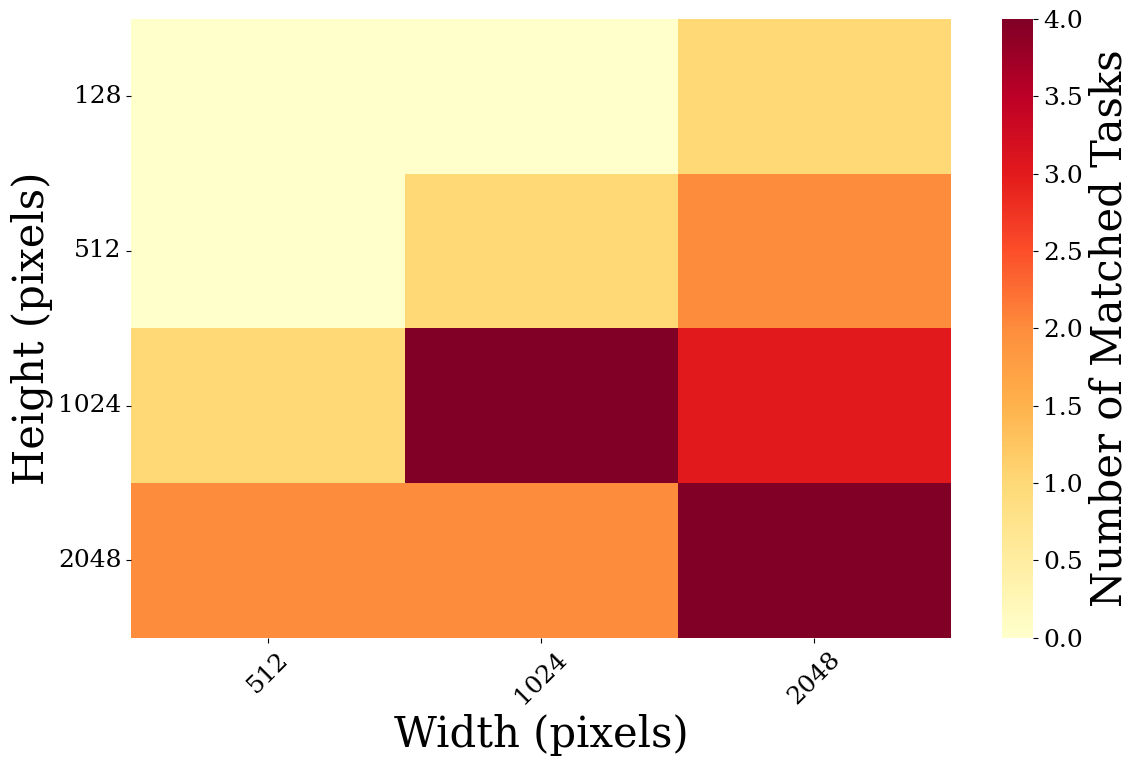


Visualization complete!

Running double_auction_scenario2...
Matched 92 tasks successfully

=== AUCTION ANALYSIS ===
Total tasks: 2000
Total GAISP capacity: 200
Matched tasks: 92
Matching rate: 4.6%

Payment Statistics:
  Average payment: $3.15e+02
  Min payment: $1.64e+02
  Max payment: $6.95e+02

Selling Price Statistics:
  Average selling price: $1.09e+02
  Min selling price: $4.62e+01
  Max selling price: $1.69e+02

Extracting image sizes from matched tasks...
Found 6 unique image size combinations

=== MATCHED TASKS SUMMARY ===
Total matched tasks: 92

Image size distribution:
  1024×2048: 29 tasks
  2048×1024: 22 tasks
  2048×2048: 20 tasks
  2048×512: 8 tasks
  512×2048: 7 tasks
  1024×1024: 6 tasks

Creating 3D visualization...

Creating 2D heatmap...
2D heatmap saved to: double_auction_scenario2_2d_heatmap.pdf


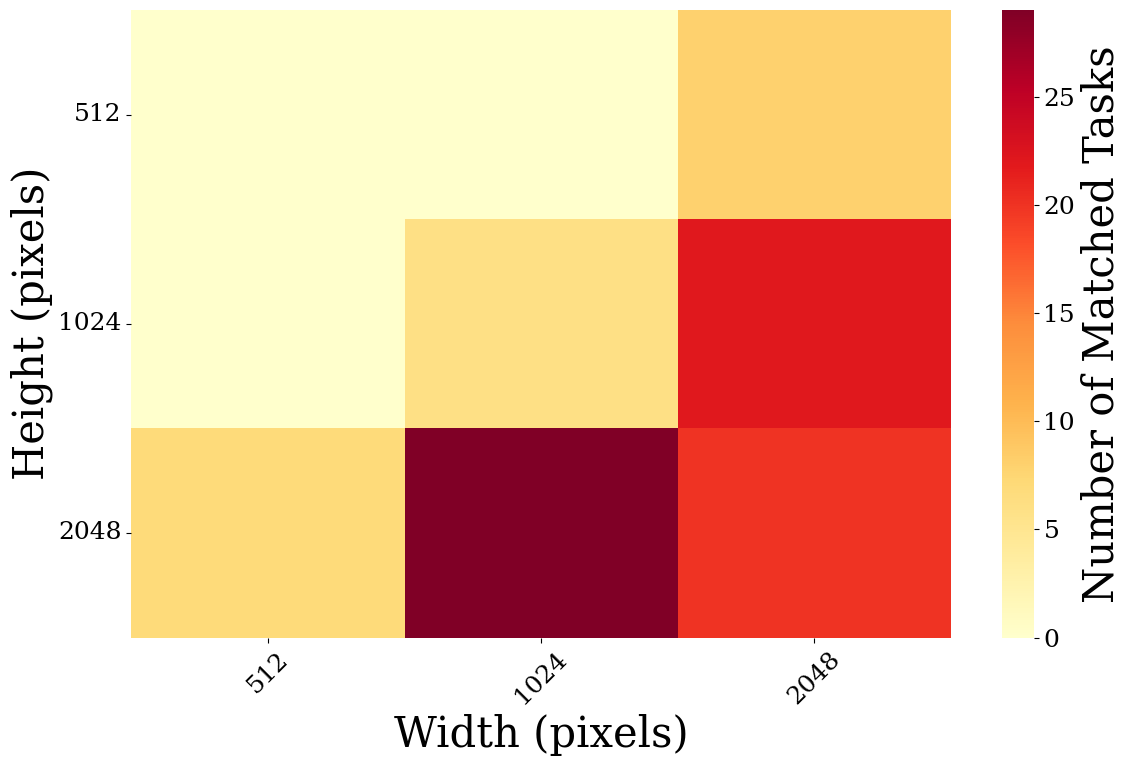


Visualization complete!

Running greedy_auction...
Matched 92 tasks successfully

=== AUCTION ANALYSIS ===
Total tasks: 2000
Total GAISP capacity: 200
Matched tasks: 92
Matching rate: 4.6%

Payment Statistics:
  Average payment: $3.21e+02
  Min payment: $1.66e+02
  Max payment: $6.97e+02

Selling Price Statistics:
  Average selling price: $1.03e+02
  Min selling price: $3.98e+01
  Max selling price: $1.59e+02

Extracting image sizes from matched tasks...
Found 6 unique image size combinations

=== MATCHED TASKS SUMMARY ===
Total matched tasks: 92

Image size distribution:
  1024×2048: 29 tasks
  2048×1024: 22 tasks
  2048×2048: 20 tasks
  2048×512: 8 tasks
  512×2048: 7 tasks
  1024×1024: 6 tasks

Creating 3D visualization...

Creating 2D heatmap...
2D heatmap saved to: greedy_auction_2d_heatmap.pdf


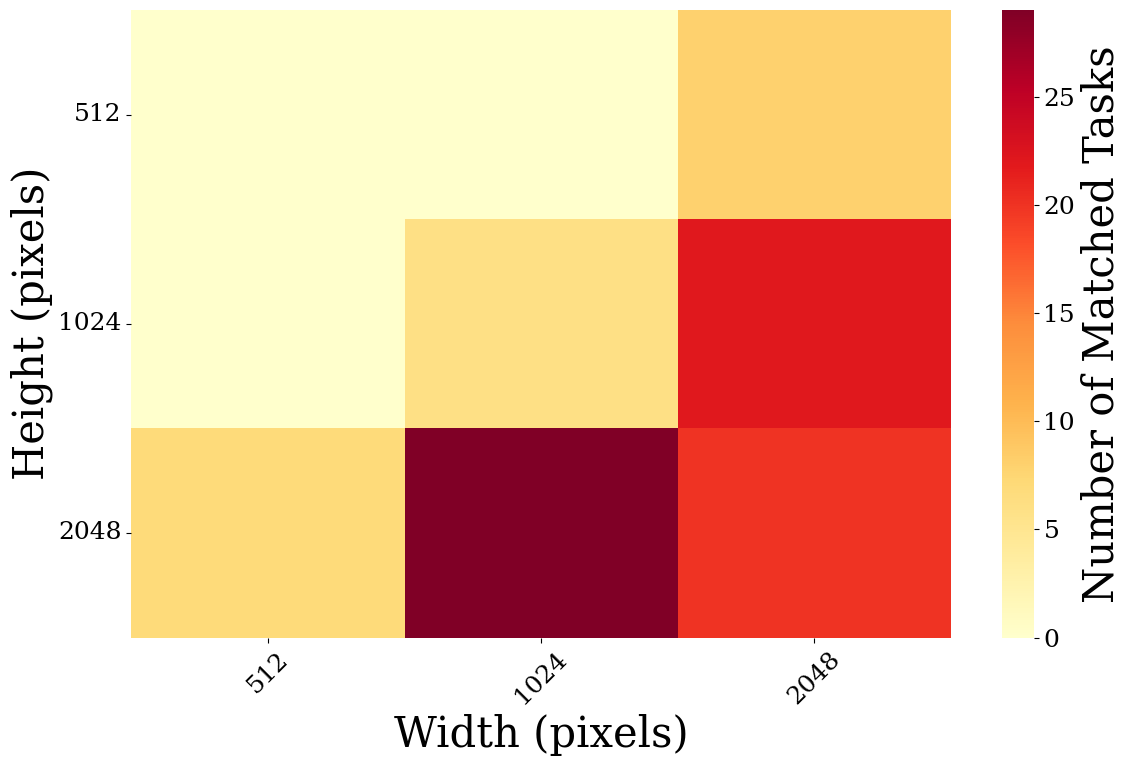


Visualization complete!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from typing import Dict, List, Tuple
import seaborn as sns

# Import the classes from previous code
from typing import Dict, List, Optional
import math

def extract_matched_image_sizes(matching: Dict, users: List[User]) -> List[Dict]:
    """Extract image sizes from matched tasks"""
    size_counts = {}

    for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching.items():
        # Find the corresponding task
        for user in users:
            if user.user_id == user_id:
                for task in user.tasks:
                    if task.task_id == task_id:
                        size_key = (task.height, task.width)
                        if size_key not in size_counts:
                            size_counts[size_key] = 0
                        size_counts[size_key] += 1
                        break
                break

    return [{"height": h, "width": w, "count": c}
            for (h, w), c in size_counts.items()]

def create_3d_visualization(image_sizes_data: List[Dict], save_path: str = None):
    """Create 3D bar chart visualization of image sizes"""

    # Set up the figure and 3D axis
    fig = plt.figure(figsize=(15, 12))
    ax = fig.add_subplot(111, projection='3d')

    # Extract data
    heights = [item['height'] for item in image_sizes_data]
    widths = [item['width'] for item in image_sizes_data]
    counts = [item['count'] for item in image_sizes_data]

    # Normalize positions for better visualization - swapped height and count positions
    x_pos = np.array(widths)
    z_pos = np.array(counts)  # Count on Z-axis
    y_pos = np.zeros_like(heights)  # Base of bars at y=0

    # Bar dimensions
    dx = np.full_like(x_pos, 50)  # Width of bars
    dy = np.array(heights)  # Height of bars (the image height)
    dz = np.full_like(z_pos, 50)  # Depth of bars

    # Color mapping based on count
    colors = plt.cm.viridis(np.array(counts) / max(counts))

    # Create 3D bar chart
    bars = ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz,
                    color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

    # Customize the plot
    ax.set_xlabel('Width (pixels)', fontsize=12, labelpad=10)
    ax.set_ylabel('Height (pixels)', fontsize=12, labelpad=10)
    ax.set_zlabel('Number of Matched Tasks', fontsize=12, labelpad=10)
    ax.set_title('3D Distribution of Image Sizes in Matched GAI Tasks',
                 fontsize=16, pad=20)

    # Add text labels on top of bars
    for i, (width, height, count) in enumerate(zip(widths, heights, counts)):
        ax.text(width, height + max(heights) * 0.05, count,
                f'{width}×{height}\n{count} tasks',
                fontsize=8, ha='center', va='bottom')

    # Improve viewing angle
    ax.view_init(elev=20, azim=45)

    # Add grid
    ax.grid(True, alpha=0.3)

    # Color bar
    mappable = plt.cm.ScalarMappable(cmap='viridis',
                                   norm=plt.Normalize(vmin=min(counts), vmax=max(counts)))
    mappable.set_array(counts)
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.6, aspect=20, pad=0.1)
    cbar.set_label('Number of Tasks', rotation=270, labelpad=15)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"3D visualization saved to: {save_path}")

    plt.show()

# Font size configuration variables
GENERAL_FONT_SIZE = 18      # General font size for the plot
LABEL_FONT_SIZE = 30        # Font size for axis labels (x, y labels)
TICK_LABEL_FONT_SIZE = 20   # Font size for tick labels
ANNOTATION_FONT_SIZE = 18   # Font size for annotations
LEGEND_FONT_SIZE = 24       # Font size for legend
TITLE_FONT_SIZE = 0        # Font size for titles (if needed)
def create_2d_heatmap(image_sizes_data: List[Dict], save_path: str = None, funct_name=""):
    """Create 2D heatmap of image sizes"""

    # Create a pivot table for heatmap
    df = pd.DataFrame(image_sizes_data)

    # Create a matrix for heatmap
    unique_heights = sorted(df['height'].unique())
    unique_widths = sorted(df['width'].unique())

    # Create matrix
    matrix = np.zeros((len(unique_heights), len(unique_widths)))

    for _, row in df.iterrows():
        h_idx = unique_heights.index(row['height'])
        w_idx = unique_widths.index(row['width'])
        matrix[h_idx, w_idx] = row['count']

    # Create heatmap
    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(matrix,
                xticklabels=unique_widths,
                yticklabels=unique_heights,
                # annot=True,
                fmt='g',
                cmap='YlOrRd')
    # ,
                # cbar_kws={'label': 'Number of Matched Tasks'})
    cbar = ax.collections[0].colorbar
    cbar.set_label('Number of Matched Tasks', fontsize=LABEL_FONT_SIZE)

    # plt.title(f'{funct_name}', fontsize=16)
    # plt.title('Heatmap of Image Sizes in Matched GAI Tasks', fontsize=16)
    plt.xlabel('Width (pixels)', fontsize=LABEL_FONT_SIZE)
    plt.ylabel('Height (pixels)', fontsize=LABEL_FONT_SIZE)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"2D heatmap saved to: {save_path}")

    plt.tight_layout()
    plt.show()

def analyze_auction_results(matching, payment_prices, selling_prices, users, gaisps):
    """Analyze and print detailed auction results"""
    print("\n=== AUCTION ANALYSIS ===")

    # Basic statistics
    total_matched = len(matching)
    total_tasks = sum(len(user.tasks) for user in users)
    total_capacity = sum(gaisp.max_tasks for gaisp in gaisps)

    print(f"Total tasks: {total_tasks}")
    print(f"Total GAISP capacity: {total_capacity}")
    print(f"Matched tasks: {total_matched}")
    print(f"Matching rate: {total_matched/total_tasks:.1%}")

    # Payment analysis
    if payment_prices:
        payments = list(payment_prices.values())
        print(f"\nPayment Statistics:")
        print(f"  Average payment: ${np.mean(payments):.2e}")
        print(f"  Min payment: ${np.min(payments):.2e}")
        print(f"  Max payment: ${np.max(payments):.2e}")

    # Selling price analysis
    if selling_prices:
        prices = list(selling_prices.values())
        print(f"\nSelling Price Statistics:")
        print(f"  Average selling price: ${np.mean(prices):.2e}")
        print(f"  Min selling price: ${np.min(prices):.2e}")
        print(f"  Max selling price: ${np.max(prices):.2e}")

def main():
    """Main function to run the simulation and create visualizations"""

    print("\nGenerating large realistic dataset...")
    users, gaisps, base_params = generate_large_dataset(num_users=1000, num_gaisps=50, size_options = [8, 16, 32, 64, 128, 512, 1024, 2048], h_same_w=False)

    print(f"Created {len(users)} users with {sum(len(u.tasks) for u in users)} total tasks")
    print(f"Created {len(gaisps)} GAISPs")

    print("\nRunning double auction...")
    for funct in [double_auction_scenario1, double_auction_scenario2, greedy_auction]:
        print(f"\nRunning {funct.__name__}...")
        matching, payment_prices, selling_prices = funct(users, gaisps, base_params)

        print(f"Matched {len(matching)} tasks successfully")

        # Analyze results
        analyze_auction_results(matching, payment_prices, selling_prices, users, gaisps)

        if not matching:
            print("No tasks were matched. Try adjusting the parameters.")
            return

        # Extract image sizes from matched tasks
        print("\nExtracting image sizes from matched tasks...")
        image_sizes_data = extract_matched_image_sizes(matching, users)

        print(f"Found {len(image_sizes_data)} unique image size combinations")

        # Print summary
        print("\n=== MATCHED TASKS SUMMARY ===")
        total_matched = sum(item['count'] for item in image_sizes_data)
        print(f"Total matched tasks: {total_matched}")

        print("\nImage size distribution:")
        sorted_data = sorted(image_sizes_data, key=lambda x: x['count'], reverse=True)
        for item in sorted_data:
            print(f"  {item['width']}×{item['height']}: {item['count']} tasks")

        # Create visualizations
        if image_sizes_data:
            print("\nCreating 3D visualization...")
            # create_3d_visualization(image_sizes_data, "gai_3d_visualization.png")

            print("\nCreating 2D heatmap...")
            create_2d_heatmap(image_sizes_data, f"{funct.__name__}_2d_heatmap.pdf", funct.__name__)

            print("\nVisualization complete!")
        else:
            print("No data to visualize - no tasks were matched.")

if __name__ == "__main__":
    main()

# DRL

## Define auction

In [ ]:
# double_auction_scenario2 = double_auction_scenario1

## Training

In [ ]:
import gym
from gym import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
from typing import List, Dict, Tuple
import copy
import warnings
warnings.filterwarnings('ignore')

class GAISPPricingEnvironment(gym.Env):
    """
    DRL Environment for GAISP pricing strategy
    """
    def __init__(self, users: List[User], gaisps: List[GAISP], base_params: Dict):
        super(GAISPPricingEnvironment, self).__init__()

        self.users = users
        self.gaisps = gaisps
        self.base_params = base_params
        self.current_step = 0
        self.max_steps = 50  # Reduced for faster training

        # State space: Market info + GAISP-specific info
        self.state_dim = 10 + len(self.gaisps) * 3  # Reduced dimensionality

        # Action space: Price multipliers for [xi_s, eta_s, zeta_s] for each GAISP
        self.action_dim = len(self.gaisps) * 3

        self.observation_space = spaces.Box(
            low=0, high=5, shape=(self.state_dim,), dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=0.7, high=1.5, shape=(self.action_dim,), dtype=np.float32
        )

        # Store original prices
        self.original_prices = []
        for gaisp in self.gaisps:
            self.original_prices.append([gaisp.xi_s, gaisp.eta_s, gaisp.zeta_s])

        # Initialize tracking
        self.profit_history = [deque(maxlen=10) for _ in range(len(self.gaisps))]
        self.utilization_history = [deque(maxlen=10) for _ in range(len(self.gaisps))]
        self.market_history = deque(maxlen=10)

        # Baseline metrics from double auction
        self.baseline_metrics = self._calculate_baseline_metrics()

        self.reset()


    def _calculate_baseline_metrics(self):
        """Calculate baseline metrics using double auction"""
        total_trades = 0
        total_efficiency = 0
        total_profit = 0

        for _ in range(10):  # Average over multiple runs
            # Reset prices to original
            for i, gaisp in enumerate(self.gaisps):
                gaisp.xi_s = self.original_prices[i][0]
                gaisp.eta_s = self.original_prices[i][1]
                gaisp.zeta_s = self.original_prices[i][2]

            matching, payment_prices, selling_prices = double_auction_scenario2(
                self.users, self.gaisps, self.base_params
            )

            total_trades += len(matching)

            # Calculate efficiency
            if matching:
                surplus = sum(payment_prices[(user_id, task_id)] - selling_prices[gaisp_info]
                            for (user_id, task_id), gaisp_info in matching.items())
                total_efficiency += surplus / len(matching)

            # Calculate profit
            for gaisp in self.gaisps:
                gaisp_profit = 0
                for (user_id, task_id), (matched_gaisp_id, gaisp_task_id) in matching.items():
                    if matched_gaisp_id == gaisp.gaisp_id:
                        selling_price = selling_prices[(matched_gaisp_id, gaisp_task_id)]
                        actual_cost = gaisp.xi_s * gaisp.r_comp + gaisp.zeta_s * gaisp.r_denoi + gaisp.eta_s * gaisp.r_comm
                        gaisp_profit += selling_price - actual_cost
                total_profit += gaisp_profit

        return {
            'avg_trades': total_trades / 10,
            'avg_efficiency': total_efficiency / 10,
            'avg_profit': total_profit / 10
        }

    def reset(self):
        """Reset environment to initial state"""
        self.current_step = 0

        # Reset GAISP prices to original values
        for i, gaisp in enumerate(self.gaisps):
            gaisp.xi_s = self.original_prices[i][0]
            gaisp.eta_s = self.original_prices[i][1]
            gaisp.zeta_s = self.original_prices[i][2]

        # Clear history
        for i in range(len(self.gaisps)):
            self.profit_history[i].clear()
            self.utilization_history[i].clear()
        self.market_history.clear()

        return self._get_state()

    def step(self, action):
        """Execute one step in the environment"""
        self.current_step += 1

        # Apply price multipliers to GAISPs
        self._apply_action(action)

        # Run double auction to get market outcome
        matching, payment_prices, selling_prices = double_auction_scenario2(
            self.users, self.gaisps, self.base_params
        )

        # Calculate rewards and update state
        reward = self._calculate_reward(matching, payment_prices, selling_prices)

        # Update tracking variables
        self._update_tracking(matching, payment_prices, selling_prices)

        # Check if episode is done
        done = self.current_step >= self.max_steps

        state = self._get_state()
        info = {
            'matching': matching,
            'payment_prices': payment_prices,
            'selling_prices': selling_prices,
            'total_trades': len(matching),
            'market_efficiency': self._calculate_market_efficiency(matching, payment_prices, selling_prices)
        }

        return state, reward, done, info

    def _apply_action(self, action):
        """Apply price multipliers to GAISPs"""
        for i, gaisp in enumerate(self.gaisps):
            base_idx = i * 3
            gaisp.xi_s = self.original_prices[i][0] * action[base_idx]
            gaisp.eta_s = self.original_prices[i][1] * action[base_idx + 1]
            gaisp.zeta_s = self.original_prices[i][2] * action[base_idx + 2]

    def _get_state(self):
        """Get current state representation"""
        state = []

        # Market-level features (normalized)
        total_demand = sum(len(user.tasks) for user in self.users)
        total_supply = sum(gaisp.max_tasks for gaisp in self.gaisps)
        market_demand = min(total_demand / total_supply, 3.0) if total_supply > 0 else 0

        # Competition level
        all_asks = []
        for gaisp in self.gaisps:
            gaisp_asks = gaisp.compute_asks()
            all_asks.extend([ask[2] for ask in gaisp_asks])

        if all_asks:
            competition_level = min(np.std(all_asks) / np.mean(all_asks), 2.0)
            avg_price = np.mean(all_asks) / 1e8  # Normalize
        else:
            competition_level = 0
            avg_price = 0

        # Historical metrics
        avg_utilization = np.mean([np.mean(hist) if hist else 0 for hist in self.utilization_history])
        avg_profit = np.mean([np.mean(hist) if hist else 0 for hist in self.profit_history]) / 1e6
        recent_efficiency = self.market_history[-1] if self.market_history else 0

        # Baseline comparisons
        baseline_trade_ratio = total_demand / max(self.baseline_metrics['avg_trades'], 1)
        baseline_profit_ratio = avg_profit / max(abs(self.baseline_metrics['avg_profit']), 1e-6)

        # Market trends
        profit_trend = 0
        if len(self.profit_history[0]) > 1:
            recent_profits = [hist[-1] - hist[-2] if len(hist) > 1 else 0 for hist in self.profit_history]
            profit_trend = np.mean(recent_profits) / 1e6

        # Time factor
        time_factor = self.current_step / self.max_steps

        state.extend([
            market_demand, competition_level, avg_price, avg_utilization, avg_profit,
            recent_efficiency, baseline_trade_ratio, baseline_profit_ratio, profit_trend, time_factor
        ])

        # GAISP-specific features (normalized)
        for i, gaisp in enumerate(self.gaisps):
            # Price multipliers
            xi_multiplier = gaisp.xi_s / self.original_prices[i][0]
            eta_multiplier = gaisp.eta_s / self.original_prices[i][1]
            zeta_multiplier = gaisp.zeta_s / self.original_prices[i][2]

            state.extend([xi_multiplier, eta_multiplier, zeta_multiplier])

        return np.array(state, dtype=np.float32)

    def _calculate_reward(self, matching, payment_prices, selling_prices):
        """Calculate reward based on auction outcome"""
        total_profit = 0
        total_utilization = 0
        total_trades = len(matching)

        # Calculate profit and utilization for each GAISP
        for i, gaisp in enumerate(self.gaisps):
            gaisp_profit = 0
            gaisp_tasks = 0

            for (user_id, task_id), (matched_gaisp_id, gaisp_task_id) in matching.items():
                if matched_gaisp_id == gaisp.gaisp_id:
                    gaisp_tasks += 1
                    selling_price = selling_prices[(matched_gaisp_id, gaisp_task_id)]
                    actual_cost = gaisp.xi_s * gaisp.r_comp + gaisp.zeta_s * gaisp.r_denoi + gaisp.eta_s * gaisp.r_comm
                    gaisp_profit += max(0, selling_price - actual_cost)  # Only positive profits

            total_profit += gaisp_profit
            total_utilization += gaisp_tasks / gaisp.max_tasks

        # Normalize rewards
        profit_reward = total_profit / 1e8  # Scale down
        utilization_reward = total_utilization / len(self.gaisps) * 10  # Average utilization

        # Market efficiency
        market_efficiency = self._calculate_market_efficiency(matching, payment_prices, selling_prices)
        efficiency_reward = market_efficiency * 100

        # Trade volume reward
        trade_volume_reward = total_trades / max(self.baseline_metrics['avg_trades'], 1) * 5

        # Stability reward (penalize extreme price changes)
        stability_penalty = 0
        for i, gaisp in enumerate(self.gaisps):
            for j, current_price in enumerate([gaisp.xi_s, gaisp.eta_s, gaisp.zeta_s]):
                multiplier = current_price / self.original_prices[i][j]
                if multiplier > 1.4 or multiplier < 0.8:
                    stability_penalty += abs(multiplier - 1.0)

        # Total reward
        total_reward = profit_reward + utilization_reward + efficiency_reward + trade_volume_reward - stability_penalty

        return total_reward

    def _calculate_market_efficiency(self, matching, payment_prices, selling_prices):
        """Calculate market efficiency metric"""
        if not matching:
            return 0

        total_surplus = 0
        for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching.items():
            payment_price = payment_prices[(user_id, task_id)]
            selling_price = selling_prices[(gaisp_id, gaisp_task_id)]
            surplus = payment_price - selling_price
            total_surplus += surplus

        return total_surplus / len(matching) / 1e8  # Normalize

    def _update_tracking(self, matching, payment_prices, selling_prices):
        """Update tracking variables"""
        # Update profit and utilization history for each GAISP
        for i, gaisp in enumerate(self.gaisps):
            gaisp_profit = 0
            gaisp_tasks = 0

            for (user_id, task_id), (matched_gaisp_id, gaisp_task_id) in matching.items():
                if matched_gaisp_id == gaisp.gaisp_id:
                    gaisp_tasks += 1
                    selling_price = selling_prices[(matched_gaisp_id, gaisp_task_id)]
                    actual_cost = gaisp.xi_s * gaisp.r_comp + gaisp.zeta_s * gaisp.r_denoi + gaisp.eta_s * gaisp.r_comm
                    gaisp_profit += selling_price - actual_cost

            self.profit_history[i].append(gaisp_profit)
            self.utilization_history[i].append(gaisp_tasks / gaisp.max_tasks)

        # Update market history
        efficiency = self._calculate_market_efficiency(matching, payment_prices, selling_prices)
        self.market_history.append(efficiency)


class ActorCritic(nn.Module):
    """Actor-Critic Network for continuous action space"""
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(ActorCritic, self).__init__()

        # Shared layers
        self.shared_fc1 = nn.Linear(state_dim, hidden_dim)
        self.shared_fc2 = nn.Linear(hidden_dim, hidden_dim)

        # Actor head (policy)
        self.actor_fc = nn.Linear(hidden_dim, action_dim)

        # Critic head (value)
        self.critic_fc = nn.Linear(hidden_dim, 1)

        self.dropout = nn.Dropout(0.1)

    def forward(self, state):
        x = torch.relu(self.shared_fc1(state))
        x = self.dropout(x)
        x = torch.relu(self.shared_fc2(x))

        # Actor output (actions)
        action_probs = torch.sigmoid(self.actor_fc(x)) * 0.8 + 0.7  # Scale to [0.7, 1.5]

        # Critic output (state value)
        state_value = self.critic_fc(x)

        return action_probs, state_value


class A2CAgent:
    """Advantage Actor-Critic Agent"""
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99):
        self.gamma = gamma
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_critic = ActorCritic(state_dim, action_dim).to(self.device)
        self.optimizer = optim.Adam(self.actor_critic.parameters(), lr=lr)

        self.log_probs = []
        self.values = []
        self.rewards = []
        self.masks = []

    def act(self, state):
        """Select action using current policy"""
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad():
            action_probs, value = self.actor_critic(state)

        # Add noise for exploration
        noise = torch.normal(0, 0.1, size=action_probs.shape).to(self.device)
        action = torch.clamp(action_probs + noise, 0.7, 1.5)

        return action.cpu().numpy()[0], value.cpu().numpy()[0]

    def remember(self, log_prob, value, reward, mask):
        """Store transition"""
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.masks.append(mask)

    def compute_returns(self, next_value):
        """Compute discounted returns"""
        R = next_value
        returns = []
        for step in reversed(range(len(self.rewards))):
            R = self.rewards[step] + self.gamma * R * self.masks[step]
            returns.insert(0, R)
        return returns

    def update(self, next_value):
        """Update policy and value function"""
        if len(self.rewards) == 0:
            return

        returns = self.compute_returns(next_value)

        returns = torch.tensor(returns, dtype=torch.float32).to(self.device)
        values = torch.tensor(self.values, dtype=torch.float32).to(self.device)

        advantages = returns - values

        # Actor loss
        actor_loss = -(torch.stack(self.log_probs) * advantages.detach()).mean()

        # Critic loss
        critic_loss = advantages.pow(2).mean()

        # Total loss
        loss = actor_loss + 0.5 * critic_loss

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor_critic.parameters(), 0.5)
        self.optimizer.step()

        # Clear memory
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.masks = []


def train_drl_agent(users, gaisps, base_params, episodes=500):
    """Train DRL agent for GAISP pricing"""
    env = GAISPPricingEnvironment(users, gaisps, base_params)
    agent = A2CAgent(env.state_dim, env.action_dim)

    scores = deque(maxlen=100)
    best_score = float('-inf')

    print("Training DRL agent...")

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0

        for step in range(env.max_steps):
            action, value = agent.act(state)
            next_state, reward, done, info = env.step(action)

            # Calculate log probability for current action
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(agent.device)
            action_tensor = torch.FloatTensor(action).unsqueeze(0).to(agent.device)
            action_probs, _ = agent.actor_critic(state_tensor)

            # Simple log probability calculation
            log_prob = -torch.sum((action_tensor - action_probs) ** 2)

            mask = 0 if done else 1
            agent.remember(log_prob, value, reward, mask)

            state = next_state
            total_reward += reward

            if done:
                break

        # Update agent
        _, next_value = agent.act(state)
        agent.update(next_value)

        scores.append(total_reward)

        # Print progress
        if episode % 100 == 0:
            avg_score = np.mean(scores)
            print(f"Episode {episode}, Average Score: {avg_score:.2f}, Trades: {info['total_trades']}")

            if avg_score > best_score:
                best_score = avg_score

    return agent, env


def evaluate_drl_vs_auction(users, gaisps, base_params, trained_agent, episodes=10):
    """Compare DRL agent performance with double auction"""
    env = GAISPPricingEnvironment(users, gaisps, base_params)

    # Test DRL agent
    drl_results = []
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0

        for step in range(env.max_steps):
            action, _ = trained_agent.act(state)
            next_state, reward, done, info = env.step(action)
            state = next_state
            total_reward += reward

            if done:
                break

        drl_results.append({
            'total_reward': total_reward,
            'total_trades': info['total_trades'],
            'market_efficiency': info['market_efficiency']
        })

    # Test original double auction
    auction_results = []
    for episode in range(episodes):
        env.reset()
        matching, payment_prices, selling_prices = double_auction_scenario2(users, gaisps, base_params)

        total_trades = len(matching)
        market_efficiency = env._calculate_market_efficiency(matching, payment_prices, selling_prices)

        auction_results.append({
            'total_trades': total_trades,
            'market_efficiency': market_efficiency
        })

    return drl_results, auction_results


# Generate smaller dataset for faster training
users, gaisps, base_params = generate_large_dataset(num_users=50, num_gaisps=5, h_same_w=True)

# # Train DRL agent
# trained_agent, env = train_drl_agent(users, gaisps, base_params, episodes=500)

# # Evaluate performance
# print("\nEvaluating DRL vs Double Auction...")
# drl_results, auction_results = evaluate_drl_vs_auction(users, gaisps, base_params, trained_agent)

# # Print comparison
# print("\nDRL Agent Results:")
# print(f"Average Reward: {np.mean([r['total_reward'] for r in drl_results]):.2f}")
# print(f"Average Trades: {np.mean([r['total_trades'] for r in drl_results]):.2f}")
# print(f"Average Market Efficiency: {np.mean([r['market_efficiency'] for r in drl_results]):.6f}")

# print("\nDouble Auction Results:")
# print(f"Average Trades: {np.mean([r['total_trades'] for r in auction_results]):.2f}")
# print(f"Average Market Efficiency: {np.mean([r['market_efficiency'] for r in auction_results]):.6f}")

# print(f"\nBaseline Metrics:")
# print(f"Baseline Trades: {env.baseline_metrics['avg_trades']:.2f}")
# print(f"Baseline Efficiency: {env.baseline_metrics['avg_efficiency']:.6f}")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal, Categorical
import numpy as np
import gym
from gym import spaces

class ImprovedActorCritic(nn.Module):
    """
    Improved Actor-Critic với proper probability distributions
    """
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(ImprovedActorCritic, self).__init__()

        self.action_dim = action_dim

        # Shared feature extractor
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU()
        )

        # Actor head - outputs mean and log_std for continuous actions
        self.actor_mean = nn.Linear(hidden_dim//2, action_dim)
        self.actor_log_std = nn.Parameter(torch.zeros(action_dim))

        # Critic head
        self.critic = nn.Linear(hidden_dim//2, 1)

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, 0.01)
            nn.init.constant_(m.bias, 0)

    def forward(self, state):
        features = self.shared_layers(state)

        # Actor output
        action_mean = self.actor_mean(features)
        action_std = torch.exp(self.actor_log_std.clamp(-20, 2))  # Clamp for stability

        # Critic output
        value = self.critic(features)

        return action_mean, action_std, value

class DiscreteActorCritic(nn.Module):
    """
    Alternative: Discrete action space cho pricing
    """
    def __init__(self, state_dim, num_gaisps, price_levels=5, hidden_dim=256):
        super(DiscreteActorCritic, self).__init__()

        self.num_gaisps = num_gaisps
        self.price_levels = price_levels
        self.action_dim = num_gaisps * 3 * price_levels  # 3 prices per GAISP

        # Shared layers
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Actor head - separate for each GAISP and price type
        self.actor_heads = nn.ModuleList([
            nn.Linear(hidden_dim, price_levels) for _ in range(num_gaisps * 3)
        ])

        # Critic head
        self.critic = nn.Linear(hidden_dim, 1)

        # Price multiplier levels
        self.price_multipliers = torch.linspace(0.5, 2.0, price_levels)

    def forward(self, state):
        features = self.shared_layers(state)

        # Actor outputs (logits for each price choice)
        action_logits = []
        for head in self.actor_heads:
            action_logits.append(head(features))

        # Critic output
        value = self.critic(features)

        return action_logits, value

class ImprovedA2CAgent:
    """
    Improved A2C với proper continuous action handling
    """
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99,
                 entropy_coef=0.01, value_coef=0.5, max_grad_norm=0.5):

        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef
        self.max_grad_norm = max_grad_norm

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_critic = ImprovedActorCritic(state_dim, action_dim).to(self.device)
        self.optimizer = optim.Adam(self.actor_critic.parameters(), lr=lr)

        # Experience buffer
        self.states = []
        self.actions = []
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.dones = []

        # For adaptive exploration
        self.exploration_rate = 1.0
        self.exploration_decay = 0.995
        self.min_exploration = 0.1

    def act(self, state, deterministic=False):
        """
        Select action using proper probability distribution
        """
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad():
            action_mean, action_std, value = self.actor_critic(state)

        # Create normal distribution
        dist = Normal(action_mean, action_std)

        if deterministic:
            action = action_mean
        else:
            # Sample from distribution
            action = dist.sample()

        # Clamp to valid range and apply sigmoid transformation
        action = torch.clamp(action, -3, 3)  # Larger range before transformation
        action = torch.sigmoid(action) * 1.3 + 0.7  # Transform to [0.7, 2.0]

        # Calculate log probability
        log_prob = dist.log_prob(action).sum(-1)

        return action.cpu().numpy()[0], log_prob.cpu().numpy()[0], value.cpu().numpy()[0]

    def remember(self, state, action, log_prob, value, reward, done):
        """Store experience"""
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.dones.append(done)

    def compute_gae(self, next_value, gae_lambda=0.95):
        """
        Compute Generalized Advantage Estimation
        """
        advantages = []
        returns = []

        gae = 0
        for step in reversed(range(len(self.rewards))):
            if step == len(self.rewards) - 1:
                next_non_terminal = 1.0 - self.dones[step]
                next_value_step = next_value
            else:
                next_non_terminal = 1.0 - self.dones[step + 1]
                next_value_step = self.values[step + 1]

            delta = self.rewards[step] + self.gamma * next_value_step * next_non_terminal - self.values[step]
            gae = delta + self.gamma * gae_lambda * next_non_terminal * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + self.values[step])

        return advantages, returns

    def update(self, next_value):
        """
        Update policy using collected experience
        """
        if len(self.states) == 0:
            return {}

        # Compute advantages and returns
        advantages, returns = self.compute_gae(next_value)

        # Convert to tensors
        states = torch.FloatTensor(np.array(self.states)).to(self.device)
        actions = torch.FloatTensor(np.array(self.actions)).to(self.device)
        old_log_probs = torch.FloatTensor(np.array(self.log_probs)).to(self.device)
        values = torch.FloatTensor(np.array(self.values)).to(self.device)
        advantages = torch.FloatTensor(advantages).to(self.device)
        returns = torch.FloatTensor(returns).to(self.device)

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Forward pass
        action_means, action_stds, new_values = self.actor_critic(states)

        # Create distribution
        dist = Normal(action_means, action_stds)

        # Transform actions back to distribution space
        transformed_actions = torch.log((actions - 0.7) / 1.3 + 1e-8) - torch.log(1 - (actions - 0.7) / 1.3 + 1e-8)

        # Calculate losses
        new_log_probs = dist.log_prob(transformed_actions).sum(-1)
        entropy = dist.entropy().sum(-1).mean()

        # Policy loss
        policy_loss = -(new_log_probs * advantages).mean()

        # Value loss
        value_loss = F.mse_loss(new_values.squeeze(), returns)

        # Total loss
        total_loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

        # Backward pass
        self.optimizer.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(self.actor_critic.parameters(), self.max_grad_norm)
        self.optimizer.step()

        # Update exploration rate
        self.exploration_rate = max(self.min_exploration,
                                   self.exploration_rate * self.exploration_decay)

        # Clear buffer
        self.clear_buffer()

        return {
            'policy_loss': policy_loss.item(),
            'value_loss': value_loss.item(),
            'entropy': entropy.item(),
            'total_loss': total_loss.item()
        }

    def clear_buffer(self):
        """Clear experience buffer"""
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.values.clear()
        self.rewards.clear()
        self.dones.clear()

class DiscreteA2CAgent:
    """
    Alternative: Discrete action space agent
    """
    def __init__(self, state_dim, num_gaisps, price_levels=5, lr=3e-4, gamma=0.99):
        self.gamma = gamma
        self.num_gaisps = num_gaisps
        self.price_levels = price_levels

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.actor_critic = DiscreteActorCritic(state_dim, num_gaisps, price_levels).to(self.device)
        self.optimizer = optim.Adam(self.actor_critic.parameters(), lr=lr)

        # Price multiplier levels
        self.price_multipliers = torch.linspace(0.5, 2.0, price_levels)

        # Experience buffer
        self.states = []
        self.actions = []
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.dones = []

    def act(self, state, deterministic=False):
        """Select discrete actions"""
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad():
            action_logits, value = self.actor_critic(state)

        actions = []
        log_probs = []

        for logits in action_logits:
            dist = Categorical(logits=logits)
            if deterministic:
                action = torch.argmax(logits, dim=-1)
            else:
                action = dist.sample()

            actions.append(action.item())
            log_probs.append(dist.log_prob(action).item())

        # Convert discrete actions to continuous multipliers
        continuous_actions = [self.price_multipliers[a].item() for a in actions]

        return continuous_actions, sum(log_probs), value.item()

class RealisticPricingEnvironment(gym.Env):
    """
    More realistic pricing environment
    """
    def __init__(self, users, gaisps, base_params):
        super(RealisticPricingEnvironment, self).__init__()

        self.users = users
        self.gaisps = gaisps
        self.base_params = base_params

        # More realistic constraints
        self.min_multiplier = 0.5   # Can cut prices by 50%
        self.max_multiplier = 3.0   # Can increase prices by 300%

        # Track market conditions
        self.market_volatility = 0.1
        self.competitor_reaction_prob = 0.3

        # Define action and observation spaces
        self.action_dim = len(self.gaisps) * 3
        self.observation_space = spaces.Box(low=0, high=10, shape=(20,), dtype=np.float32)
        self.action_space = spaces.Box(
            low=self.min_multiplier,
            high=self.max_multiplier,
            shape=(self.action_dim,),
            dtype=np.float32
        )

        # Store original prices
        self.original_prices = []
        for gaisp in self.gaisps:
            self.original_prices.append([gaisp.xi_s, gaisp.eta_s, gaisp.zeta_s])

        self.reset()

    def step(self, action):
        """
        More realistic step function with market dynamics
        """
        # Apply pricing with market volatility
        self._apply_pricing_with_volatility(action)

        # Simulate competitor reactions
        self._simulate_competitor_reactions()

        # Run auction
        matching, payment_prices, selling_prices = double_auction_scenario2(
            self.users, self.gaisps, self.base_params
        )

        # Calculate more realistic rewards
        reward = self._calculate_realistic_reward(matching, payment_prices, selling_prices, action)

        # Update state
        self.current_step += 1
        done = self.current_step >= self.max_steps

        state = self._get_state()
        info = {
            'matching': matching,
            'payment_prices': payment_prices,
            'selling_prices': selling_prices,
            'market_volatility': self.market_volatility
        }

        return state, reward, done, info

    def _apply_pricing_with_volatility(self, action):
        """Apply pricing with market volatility"""
        for i, gaisp in enumerate(self.gaisps):
            base_idx = i * 3

            # Add market volatility
            volatility = np.random.normal(0, self.market_volatility, 3)

            gaisp.xi_s = self.original_prices[i][0] * action[base_idx] * (1 + volatility[0])
            gaisp.eta_s = self.original_prices[i][1] * action[base_idx + 1] * (1 + volatility[1])
            gaisp.zeta_s = self.original_prices[i][2] * action[base_idx + 2] * (1 + volatility[2])

            # Ensure positive prices
            gaisp.xi_s = max(gaisp.xi_s, 0.01)
            gaisp.eta_s = max(gaisp.eta_s, 0.01)
            gaisp.zeta_s = max(gaisp.zeta_s, 0.01)

    def _simulate_competitor_reactions(self):
        """Simulate competitor price reactions"""
        if np.random.random() < self.competitor_reaction_prob:
            # Some GAISPs might react to others' pricing
            for i, gaisp in enumerate(self.gaisps):
                if np.random.random() < 0.3:  # 30% chance to react
                    # Slightly adjust prices based on competition
                    adjustment = np.random.normal(1.0, 0.05)
                    gaisp.xi_s *= adjustment
                    gaisp.eta_s *= adjustment
                    gaisp.zeta_s *= adjustment

    def _calculate_realistic_reward(self, matching, payment_prices, selling_prices, action):
        """
        More realistic reward calculation
        """
        # Base profit reward
        total_profit = 0
        for i, gaisp in enumerate(self.gaisps):
            for (user_id, task_id), (matched_gaisp_id, gaisp_task_id) in matching.items():
                if matched_gaisp_id == gaisp.gaisp_id:
                    selling_price = selling_prices[(matched_gaisp_id, gaisp_task_id)]
                    actual_cost = (gaisp.xi_s * gaisp.r_comp +
                                 gaisp.zeta_s * gaisp.r_denoi +
                                 gaisp.eta_s * gaisp.r_comm)
                    total_profit += max(0, selling_price - actual_cost)

        profit_reward = total_profit / 1e8

        # Penalize extreme pricing
        price_stability_penalty = 0
        for i, gaisp in enumerate(self.gaisps):
            base_idx = i * 3
            for j in range(3):
                if action[base_idx + j] > 2.0 or action[base_idx + j] < 0.7:
                    price_stability_penalty += abs(action[base_idx + j] - 1.0) * 0.1

        # Market share reward
        market_share_reward = len(matching) / len(self.users) * 10

        # Long-term sustainability (penalize very low prices)
        sustainability_penalty = 0
        for i, gaisp in enumerate(self.gaisps):
            base_idx = i * 3
            avg_multiplier = np.mean(action[base_idx:base_idx+3])
            if avg_multiplier < 0.8:
                sustainability_penalty += (0.8 - avg_multiplier) * 5

        total_reward = (profit_reward + market_share_reward -
                       price_stability_penalty - sustainability_penalty)

        return total_reward

    def _get_state(self):
        """Get more informative state"""
        # Implementation similar to original but with more market indicators
        state = np.zeros(20)

        # Market demand/supply ratio
        total_demand = sum(len(user.tasks) for user in self.users)
        total_supply = sum(gaisp.max_tasks for gaisp in self.gaisps)
        state[0] = total_demand / max(total_supply, 1)

        # Current pricing levels
        current_prices = []
        for gaisp in self.gaisps:
            current_prices.extend([gaisp.xi_s, gaisp.eta_s, gaisp.zeta_s])

        # Price competition metrics
        if current_prices:
            state[1] = np.mean(current_prices) / 1e8
            state[2] = np.std(current_prices) / 1e8
            state[3] = np.min(current_prices) / 1e8
            state[4] = np.max(current_prices) / 1e8

        # Market volatility
        state[5] = self.market_volatility

        # Time factor
        state[6] = self.current_step / self.max_steps

        # Fill remaining with normalized GAISP-specific info
        for i, gaisp in enumerate(self.gaisps):
            if i < 4:  # Limit to first 4 GAISPs for state space
                base_idx = 7 + i * 3
                state[base_idx] = gaisp.xi_s / self.original_prices[i][0]
                state[base_idx + 1] = gaisp.eta_s / self.original_prices[i][1]
                state[base_idx + 2] = gaisp.zeta_s / self.original_prices[i][2]

        return state

    def reset(self):
        """Reset environment"""
        self.current_step = 0
        self.max_steps = 50

        # Reset prices
        for i, gaisp in enumerate(self.gaisps):
            gaisp.xi_s = self.original_prices[i][0]
            gaisp.eta_s = self.original_prices[i][1]
            gaisp.zeta_s = self.original_prices[i][2]

        # Reset market volatility
        self.market_volatility = np.random.uniform(0.05, 0.15)

        return self._get_state()

# Example usage:
# Sử dụng improved continuous agent
env = RealisticPricingEnvironment(users, gaisps, base_params)
agent = ImprovedA2CAgent(env.observation_space.shape[0], env.action_space.shape[0])

# Hoặc sử dụng discrete agent
# discrete_agent = DiscreteA2CAgent(env.observation_space.shape[0], len(gaisps), price_levels=7)

# Training loop sẽ tương tự nhưng với better action handling
# Train DRL agent
trained_agent, env = train_drl_agent(users, gaisps, base_params, episodes=1000)

# Evaluate performance
print("\nEvaluating DRL vs Double Auction...")
drl_results, auction_results = evaluate_drl_vs_auction(users, gaisps, base_params, trained_agent)

# Print comparison
print("\nDRL Agent Results:")
print(f"Average Reward: {np.mean([r['total_reward'] for r in drl_results]):.2f}")
print(f"Average Trades: {np.mean([r['total_trades'] for r in drl_results]):.2f}")
print(f"Average Market Efficiency: {np.mean([r['market_efficiency'] for r in drl_results]):.6f}")

print("\nDouble Auction Results:")
print(f"Average Trades: {np.mean([r['total_trades'] for r in auction_results]):.2f}")
print(f"Average Market Efficiency: {np.mean([r['market_efficiency'] for r in auction_results]):.6f}")

print(f"\nBaseline Metrics:")
print(f"Baseline Trades: {env.baseline_metrics['avg_trades']:.2f}")
print(f"Baseline Efficiency: {env.baseline_metrics['avg_efficiency']:.6f}")

Training DRL agent...
Episode 0, Average Score: 447.74, Trades: 8
Episode 100, Average Score: 446.71, Trades: 8
Episode 200, Average Score: 444.30, Trades: 8
Episode 300, Average Score: 442.36, Trades: 8
Episode 400, Average Score: 444.05, Trades: 8
Episode 500, Average Score: 446.96, Trades: 8
Episode 600, Average Score: 447.13, Trades: 8
Episode 700, Average Score: 447.02, Trades: 8
Episode 800, Average Score: 445.37, Trades: 8
Episode 900, Average Score: 446.91, Trades: 8

Evaluating DRL vs Double Auction...

DRL Agent Results:
Average Reward: 445.04
Average Trades: 8.00
Average Market Efficiency: -0.000000

Double Auction Results:
Average Trades: 8.00
Average Market Efficiency: -0.000000

Baseline Metrics:
Baseline Trades: 8.00
Baseline Efficiency: -4.939715


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import seaborn as sns

def extract_winning_gaisp_prices(matching, selling_prices, gaisps):
    """
    Trích xuất giá của các GAISPs trúng thầu

    Args:
        matching: Dict mapping (user_id, task_id) -> (gaisp_id, gaisp_task_id)
        selling_prices: Dict mapping (gaisp_id, gaisp_task_id) -> price
        gaisps: List of GAISP objects

    Returns:
        Dict with GAISP info and their winning prices
    """
    winning_prices = defaultdict(list)
    gaisp_info = {}

    # Tạo mapping từ gaisp_id đến GAISP object
    gaisp_map = {gaisp.gaisp_id: gaisp for gaisp in gaisps}

    for (user_id, task_id), (gaisp_id, gaisp_task_id) in matching.items():
        if gaisp_id in gaisp_map:
            gaisp = gaisp_map[gaisp_id]
            selling_price = selling_prices[(gaisp_id, gaisp_task_id)]

            winning_prices[gaisp_id].append(selling_price)

            # Lưu thông tin về pricing parameters hiện tại
            if gaisp_id not in gaisp_info:
                gaisp_info[gaisp_id] = {
                    'xi_s': gaisp.xi_s,
                    'eta_s': gaisp.eta_s,
                    'zeta_s': gaisp.zeta_s,
                    'r_comp': gaisp.r_comp,
                    'r_denoi': gaisp.r_denoi,
                    'r_comm': gaisp.r_comm,
                    'max_tasks': gaisp.max_tasks
                }

    return winning_prices, gaisp_info

def analyze_pricing_strategies(users, gaisps, base_params, trained_agent, episodes=20):
    """
    Phân tích và so sánh chiến lược pricing giữa Auction và DRL
    """
    env = GAISPPricingEnvironment(users, gaisps, base_params)

    # Lưu giá gốc
    original_prices = []
    for gaisp in gaisps:
        original_prices.append([gaisp.xi_s, gaisp.eta_s, gaisp.zeta_s])

    auction_results = []
    drl_results = []

    print("Đang phân tích chiến lược pricing...")

    # Test với Double Auction (giá gốc)
    for episode in range(episodes):
        # Reset về giá gốc
        for i, gaisp in enumerate(gaisps):
            gaisp.xi_s = original_prices[i][0]
            gaisp.eta_s = original_prices[i][1]
            gaisp.zeta_s = original_prices[i][2]

        matching, payment_prices, selling_prices = double_auction_scenario2(users, gaisps, base_params)

        # Prepare bid and ask data
        all_bids = []
        for user in users:
            user.compute_bids(base_params)
            for task in user.tasks:
                all_bids.append((user.user_id, task.task_id, task.bid))

        all_asks = []
        for gaisp in gaisps:
            all_asks.extend(gaisp.compute_asks())


        utils_auction = calculate_utilities(matching, payment_prices, selling_prices, users, gaisps, all_bids, all_asks)


        winning_prices, gaisp_info = extract_winning_gaisp_prices(matching, selling_prices, gaisps)

        auction_results.append({
            'episode': episode,
            'matching': matching,
            'payment_prices': payment_prices,
            'selling_prices': selling_prices,
            'winning_prices': winning_prices,
            'gaisp_info': gaisp_info,
            'total_trades': len(matching),
            'utils': utils_auction
        })

    # Test với DRL Agent
    for episode in range(episodes):
        state = env.reset()
        episode_actions = []

        for step in range(env.max_steps):
            action, _ = trained_agent.act(state)
            episode_actions.append(action.copy())
            next_state, reward, done, info = env.step(action)
            state = next_state

            if done:
                break

        # Lấy kết quả cuối cùng
        matching = info['matching']
        payment_prices = info['payment_prices']
        selling_prices = info['selling_prices']

        utils_drl = calculate_utilities(matching, payment_prices, selling_prices, users, gaisps, all_bids, all_asks, auction=False)

        winning_prices, gaisp_info = extract_winning_gaisp_prices(matching, selling_prices, gaisps)

        drl_results.append({
            'episode': episode,
            'matching': matching,
            'payment_prices': payment_prices,
            'selling_prices': selling_prices,
            'winning_prices': winning_prices,
            'gaisp_info': gaisp_info,
            'total_trades': len(matching),
            'final_action': episode_actions[-1] if episode_actions else None,
            'price_multipliers': {
                gaisp.gaisp_id: {
                    'xi_multiplier': gaisp.xi_s / original_prices[i][0],
                    'eta_multiplier': gaisp.eta_s / original_prices[i][1],
                    'zeta_multiplier': gaisp.zeta_s / original_prices[i][2]
                }
                for i, gaisp in enumerate(gaisps)
            },
            'utils': utils_drl
        })

    return auction_results, drl_results, original_prices

def compare_pricing_statistics(auction_results, drl_results, gaisps):
    """
    So sánh thống kê giá giữa Auction và DRL
    """
    comparison_stats = {}

    # Tính thống kê cho từng GAISP
    for gaisp in gaisps:
        gaisp_id = gaisp.gaisp_id

        # Thu thập giá từ auction
        auction_prices = []
        for result in auction_results:
            if gaisp_id in result['winning_prices']:
                auction_prices.extend(result['winning_prices'][gaisp_id])

        # Thu thập giá từ DRL
        drl_prices = []
        for result in drl_results:
            if gaisp_id in result['winning_prices']:
                drl_prices.extend(result['winning_prices'][gaisp_id])

        if auction_prices and drl_prices:
            comparison_stats[gaisp_id] = {
                'auction': {
                    'mean': np.mean(auction_prices),
                    'std': np.std(auction_prices),
                    'min': np.min(auction_prices),
                    'max': np.max(auction_prices),
                    'count': len(auction_prices)
                },
                'drl': {
                    'mean': np.mean(drl_prices),
                    'std': np.std(drl_prices),
                    'min': np.min(drl_prices),
                    'max': np.max(drl_prices),
                    'count': len(drl_prices)
                },
                'price_difference': np.mean(drl_prices) - np.mean(auction_prices),
                'price_difference_pct': ((np.mean(drl_prices) - np.mean(auction_prices)) / np.mean(auction_prices)) * 100
            }

    return comparison_stats

def plot_price_comparison_mean(comparison_stats, gaisps):
    """
    Vẽ biểu đồ so sánh giá
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. So sánh giá trung bình
    gaisp_ids = list(comparison_stats.keys())
    auction_means = [comparison_stats[gid]['auction']['mean'] for gid in gaisp_ids]
    drl_means = [comparison_stats[gid]['drl']['mean'] for gid in gaisp_ids]

    x = np.arange(len(gaisp_ids))
    width = 0.35

    axes[0,0].bar(x - width/2, auction_means, width, label='Auction', alpha=0.7)
    axes[0,0].bar(x + width/2, drl_means, width, label='DRL', alpha=0.7)
    axes[0,0].set_xlabel('GAISP ID')
    axes[0,0].set_ylabel('Giá trung bình')
    axes[0,0].set_title('So sánh giá trung bình: Auction vs DRL')
    axes[0,0].set_xticks(x)
    axes[0,0].set_xticklabels(gaisp_ids)
    axes[0,0].legend()

    # 2. Phần trăm thay đổi giá
    price_changes = [comparison_stats[gid]['price_difference_pct'] for gid in gaisp_ids]
    colors = ['red' if x < 0 else 'green' for x in price_changes]

    axes[0,1].bar(gaisp_ids, price_changes, color=colors, alpha=0.7)
    axes[0,1].set_xlabel('GAISP ID')
    axes[0,1].set_ylabel('Thay đổi giá (%)')
    axes[0,1].set_title('Thay đổi giá DRL so với Auction (%)')
    axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # 3. Boxplot so sánh phân phối giá
    auction_all_prices = []
    drl_all_prices = []
    labels = []

    for gid in gaisp_ids:
        # Thu thập tất cả giá
        auction_prices = []
        drl_prices = []

        # Giả sử có auction_results và drl_results
        for result in getattr(plot_price_comparison, 'auction_results', []):
            if gid in result['winning_prices']:
                auction_prices.extend(result['winning_prices'][gid])

        for result in getattr(plot_price_comparison, 'drl_results', []):
            if gid in result['winning_prices']:
                drl_prices.extend(result['winning_prices'][gid])

        auction_all_prices.extend(auction_prices)
        drl_all_prices.extend(drl_prices)
        labels.extend([f'{gid}_Auction'] * len(auction_prices))
        labels.extend([f'{gid}_DRL'] * len(drl_prices))

    # 4. Scatter plot: Auction vs DRL prices
    axes[1,0].scatter(auction_means, drl_means, alpha=0.7, s=100)
    for i, gid in enumerate(gaisp_ids):
        axes[1,0].annotate(gid, (auction_means[i], drl_means[i]),
                          xytext=(5, 5), textcoords='offset points')

    # Đường y=x để so sánh
    min_price = min(min(auction_means), min(drl_means))
    max_price = max(max(auction_means), max(drl_means))
    axes[1,0].plot([min_price, max_price], [min_price, max_price], 'r--', alpha=0.5)

    axes[1,0].set_xlabel('Giá Auction')
    axes[1,0].set_ylabel('Giá DRL')
    axes[1,0].set_title('Tương quan giá: Auction vs DRL')

    # 5. Số lượng trades
    auction_trades = [comparison_stats[gid]['auction']['count'] for gid in gaisp_ids]
    drl_trades = [comparison_stats[gid]['drl']['count'] for gid in gaisp_ids]

    axes[1,1].bar(x - width/2, auction_trades, width, label='Auction', alpha=0.7)
    axes[1,1].bar(x + width/2, drl_trades, width, label='DRL', alpha=0.7)
    axes[1,1].set_xlabel('GAISP ID')
    axes[1,1].set_ylabel('Số lượng trades')
    axes[1,1].set_title('Số lượng trades: Auction vs DRL')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(gaisp_ids)
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()

def plot_price_comparison(comparison_stats, gaisps):
    """
    Vẽ biểu đồ giá theo từng episode cho mỗi GAISP
    """
    auction_results = getattr(plot_price_comparison, 'auction_results', [])
    drl_results = getattr(plot_price_comparison, 'drl_results', [])

    # Vẽ total_buyer_utility của utils in results
    auction_utils = [result['utils']['total_buyer_utility'] for result in auction_results]
    drl_utils = [result['utils']['total_buyer_utility'] for result in drl_results]

    plt.figure(figsize=(10, 6))
    plt.plot(auction_utils, label='Double Auction Scenario 2', marker='o', color=beautiful_colors[1], linewidth=2.5)
    plt.plot(drl_utils, label='A2C', marker='x', color=beautiful_colors[3],  linewidth=2.5)
    plt.xlabel('Number of Tests')
    plt.ylabel('Total Buyer Utility')
    # plt.title('Total Buyer Utility: Auction vs DRL')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig('compare_utility_a2c_aution.pdf', dpi=300, bbox_inches='tight')
    plt.show()





    fig, axes = plt.subplots(len(gaisps), 1, figsize=(12, 4*len(gaisps)), sharex=True)

    if len(gaisps) == 1:
        axes = [axes]  # Đảm bảo axes luôn là list

    for idx, gaisp in enumerate(gaisps):
        gaisp_id = gaisp.gaisp_id

        auction_prices = []
        drl_prices = []
        episodes = list(range(len(auction_results)))

        # Lấy giá trung bình theo từng episode
        for ep, result in enumerate(auction_results):
            if gaisp_id in result['winning_prices']:
                auction_prices.append(np.mean(result['winning_prices'][gaisp_id]))
            else:
                auction_prices.append(np.nan)

        for ep, result in enumerate(drl_results):
            if gaisp_id in result['winning_prices']:
                drl_prices.append(np.mean(result['winning_prices'][gaisp_id]))
            else:
                drl_prices.append(np.nan)

        dac = 2
        # Vẽ line chart
        axes[idx].plot(episodes, auction_prices, label=f'Double Auction Scenario {dac}', marker='o', color=beautiful_colors[dac-1], linewidth=2.5)
        axes[idx].plot(episodes, drl_prices, label='A2C', marker='x', color=beautiful_colors[3], linewidth=2.5)

        axes[idx].set_title(f'GAISP {gaisp_id}')
        axes[idx].set_ylabel('Price')
        axes[idx].set_xlabel('Episode')
        axes[idx].legend()
        axes[idx].grid(True, linestyle='--', alpha=0.5)

        # save axes[idx] to file pdf
        axes[idx].figure.savefig(f'gaisp_{gaisp_id}_aution{dac}.pdf', dpi=300, bbox_inches='tight')

    axes[-1].set_xlabel('Episode')
    plt.tight_layout()
    plt.show()

def analyze_price_multipliers(drl_results, original_prices, gaisps):
    """
    Phân tích price multipliers được học bởi DRL
    """
    multiplier_analysis = {}

    for gaisp in gaisps:
        gaisp_id = gaisp.gaisp_id
        multipliers = {
            'xi_multipliers': [],
            'eta_multipliers': [],
            'zeta_multipliers': []
        }

        for result in drl_results:
            if gaisp_id in result['price_multipliers']:
                pm = result['price_multipliers'][gaisp_id]
                multipliers['xi_multipliers'].append(pm['xi_multiplier'])
                multipliers['eta_multipliers'].append(pm['eta_multiplier'])
                multipliers['zeta_multipliers'].append(pm['zeta_multiplier'])

        if multipliers['xi_multipliers']:
            multiplier_analysis[gaisp_id] = {
                'xi_stats': {
                    'mean': np.mean(multipliers['xi_multipliers']),
                    'std': np.std(multipliers['xi_multipliers']),
                    'min': np.min(multipliers['xi_multipliers']),
                    'max': np.max(multipliers['xi_multipliers'])
                },
                'eta_stats': {
                    'mean': np.mean(multipliers['eta_multipliers']),
                    'std': np.std(multipliers['eta_multipliers']),
                    'min': np.min(multipliers['eta_multipliers']),
                    'max': np.max(multipliers['eta_multipliers'])
                },
                'zeta_stats': {
                    'mean': np.mean(multipliers['zeta_multipliers']),
                    'std': np.std(multipliers['zeta_multipliers']),
                    'min': np.min(multipliers['zeta_multipliers']),
                    'max': np.max(multipliers['zeta_multipliers'])
                }
            }

    return multiplier_analysis

def print_detailed_comparison(comparison_stats, multiplier_analysis):
    """
    In báo cáo chi tiết về so sánh giá
    """
    print("="*60)
    print("BÁO CÁO SO SÁNH GIÁ: AUCTION vs DRL")
    print("="*60)

    for gaisp_id in comparison_stats:
        print(f"\n--- GAISP {gaisp_id} ---")

        auction_stats = comparison_stats[gaisp_id]['auction']
        drl_stats = comparison_stats[gaisp_id]['drl']

        print(f"Auction - Giá TB: {auction_stats['mean']:.2f}, Std: {auction_stats['std']:.2f}")
        print(f"DRL     - Giá TB: {drl_stats['mean']:.2f}, Std: {drl_stats['std']:.2f}")
        print(f"Thay đổi: {comparison_stats[gaisp_id]['price_difference']:.2f} ({comparison_stats[gaisp_id]['price_difference_pct']:.1f}%)")
        print(f"Trades  - Auction: {auction_stats['count']}, DRL: {drl_stats['count']}")

        if gaisp_id in multiplier_analysis:
            ma = multiplier_analysis[gaisp_id]
            print(f"Multipliers - Xi: {ma['xi_stats']['mean']:.3f}, Eta: {ma['eta_stats']['mean']:.3f}, Zeta: {ma['zeta_stats']['mean']:.3f}")

    # Tổng kết
    print(f"\n{'='*60}")
    print("TỔNG KẾT:")

    total_auction_trades = sum(comparison_stats[gid]['auction']['count'] for gid in comparison_stats)
    total_drl_trades = sum(comparison_stats[gid]['drl']['count'] for gid in comparison_stats)

    avg_price_change = np.mean([comparison_stats[gid]['price_difference_pct'] for gid in comparison_stats])

    print(f"Tổng trades - Auction: {total_auction_trades}, DRL: {total_drl_trades}")
    print(f"Thay đổi giá trung bình: {avg_price_change:.1f}%")

    # Phân tích xu hướng
    price_increases = sum(1 for gid in comparison_stats if comparison_stats[gid]['price_difference_pct'] > 0)
    price_decreases = sum(1 for gid in comparison_stats if comparison_stats[gid]['price_difference_pct'] < 0)

    print(f"GAISPs tăng giá: {price_increases}, giảm giá: {price_decreases}")

# Hàm chính để chạy so sánh
def run_price_comparison(users, gaisps, base_params, trained_agent, episodes=20):
    """
    Chạy so sánh giá hoàn chỉnh
    """
    print("Bắt đầu so sánh giá giữa Auction và DRL...")

    # Phân tích pricing strategies
    auction_results, drl_results, original_prices = analyze_pricing_strategies(
        users, gaisps, base_params, trained_agent, episodes
    )

    # Lưu results để sử dụng trong plotting
    plot_price_comparison.auction_results = auction_results
    plot_price_comparison.drl_results = drl_results

    # So sánh thống kê
    comparison_stats = compare_pricing_statistics(auction_results, drl_results, gaisps)

    # Phân tích multipliers
    multiplier_analysis = analyze_price_multipliers(drl_results, original_prices, gaisps)

    # In báo cáo chi tiết
    print_detailed_comparison(comparison_stats, multiplier_analysis)

    # Vẽ biểu đồ
    plot_price_comparison(comparison_stats, gaisps)

    return {
        'auction_results': auction_results,
        'drl_results': drl_results,
        'comparison_stats': comparison_stats,
        'multiplier_analysis': multiplier_analysis,
        'original_prices': original_prices
    }


Bắt đầu so sánh giá giữa Auction và DRL...
Đang phân tích chiến lược pricing...
BÁO CÁO SO SÁNH GIÁ: AUCTION vs DRL

--- GAISP 2 ---
Auction - Giá TB: 225.50, Std: 0.00
DRL     - Giá TB: 257.54, Std: 44.19
Thay đổi: 32.04 (14.2%)
Trades  - Auction: 200, DRL: 197
Multipliers - Xi: 1.209, Eta: 1.133, Zeta: 1.095

--- GAISP 3 ---
Auction - Giá TB: 92.79, Std: 0.00
DRL     - Giá TB: 121.92, Std: 37.99
Thay đổi: 29.13 (31.4%)
Trades  - Auction: 200, DRL: 200
Multipliers - Xi: 1.170, Eta: 1.193, Zeta: 1.020

TỔNG KẾT:
Tổng trades - Auction: 400, DRL: 397
Thay đổi giá trung bình: 22.8%
GAISPs tăng giá: 2, giảm giá: 0


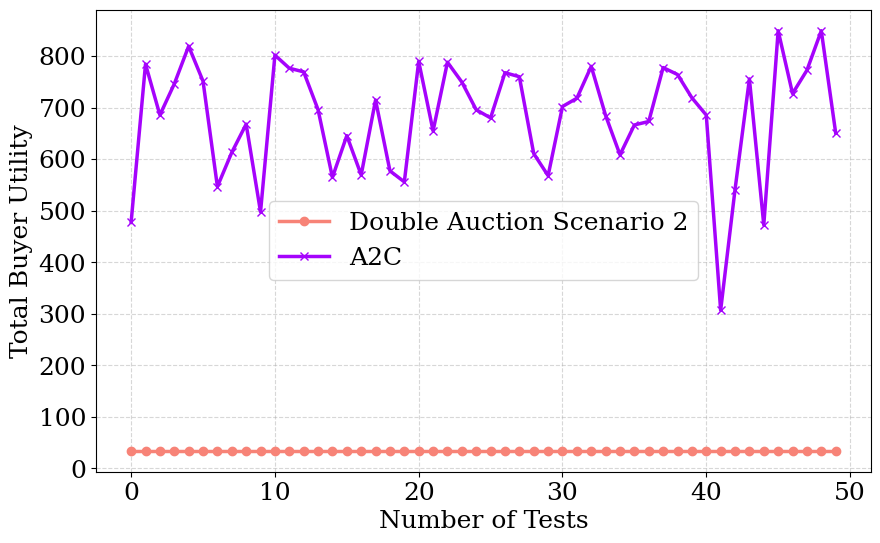

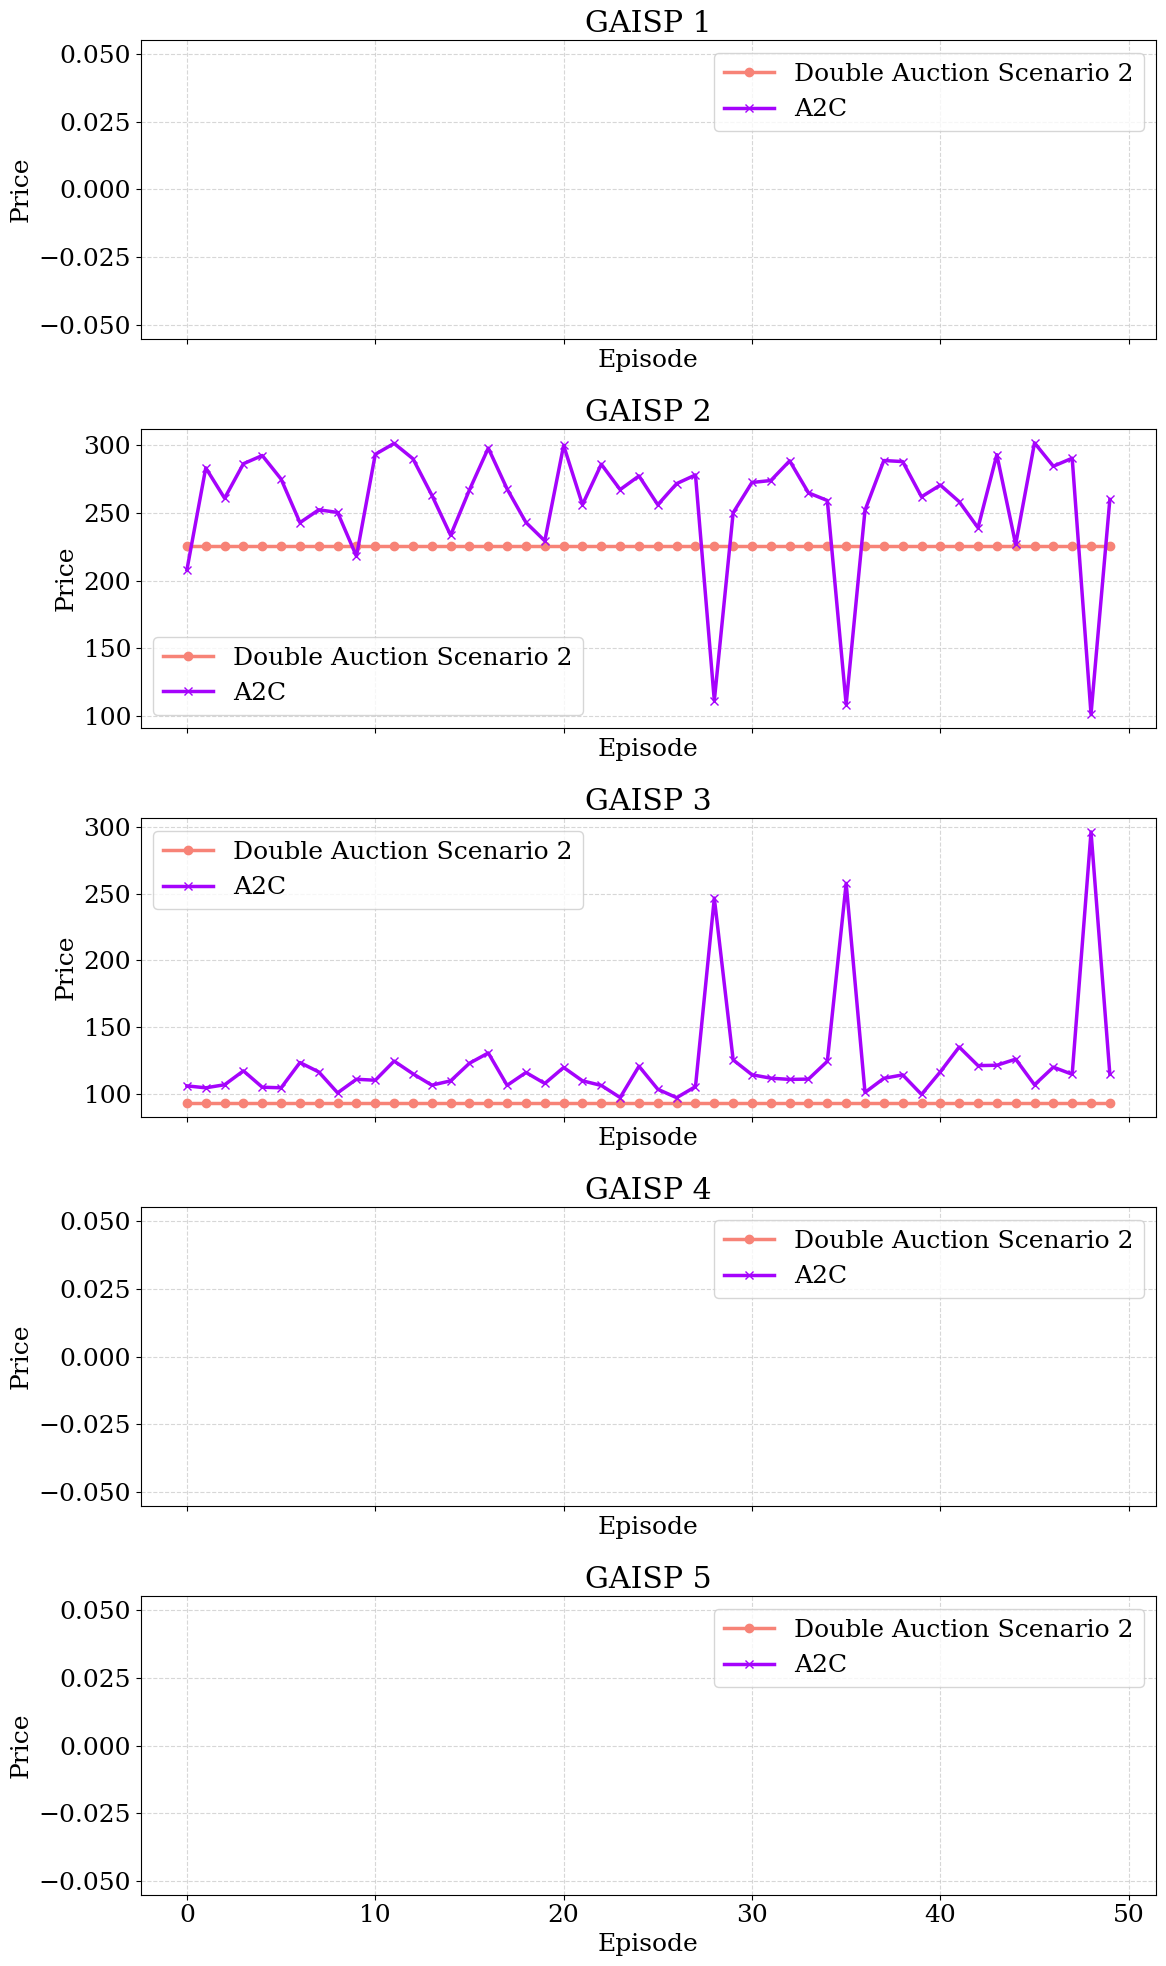

In [ ]:
# Cách sử dụng:
# Sau khi train xong DRL agent:
# Generate dataset once for all algorithms

comparison_results = run_price_comparison(users, gaisps, base_params, trained_agent, episodes=50)

### 🛠 Technical Specifications & Experiment Setup

This section documents the specific hardware and software environment used to run the Generative AI resource allocation simulations and DRL agent training.

#### 1. Hardware Configuration
*   **Processor:** Intel(R) Xeon(R) CPU @ 2.20GHz.
*   **GPU:** NVIDIA T4 Tensor Core GPU (16GB GDDR6 RAM) / NVIDIA L4 (optional based on runtime).
*   **Memory (RAM):** 12.7 GB System RAM.
*   **Disk Space:** ~78 GB available persistent storage.

#### 2. Software Environment
*   **Operating System:** Ubuntu 22.04.3 LTS (Linux Kernel 6.1).
*   **Language:** Python 3.10.12.
*   **Deep Learning Framework:** PyTorch 2.1.0+cu121.
*   **Runtime:** Google Colab Cloud Environment.

#### 3. Core Libraries & Tools
*   **Numerical Computing:** `numpy` (v1.25.2) for matrix operations and simulation logic.
*   **Data Analysis:** `pandas` (v2.0.3) for metric aggregation and table formatting.
*   **Visualization:** `matplotlib` (v3.7.1) and `seaborn` (v0.13.1) for auction curves, heatmaps, and utility analysis.
*   **Reinforcement Learning:** `gym` (v0.25.2) for the custom GAISP environment and `torch.nn`/`torch.optim` for the Actor-Critic networks.
*   **Utilities:** `tqdm` (Progress tracking), `tabulate` (Console reporting), and `scipy` (Spline interpolation for smoothed trend lines).